In [1]:
# import sys
# import platform
# import importlib
# import subprocess

# print("=" * 70)
# print("ENVIRONMENT INFORMATION")
# print("=" * 70)

# print(f"Python:        {sys.version.split()[0]}")
# print(f"OS:            {platform.platform()}")
# print(f"Processor:     {platform.processor()}")

# print("\n" + "=" * 70)
# print("PACKAGE VERSIONS")
# print("=" * 70)

# packages = {
#     "torch": "PyTorch",
#     "numpy": "NumPy",
#     "pandas": "Pandas",
#     "sklearn": "Scikit-learn",
#     "scipy": "SciPy",
#     "matplotlib": "Matplotlib",
#     "seaborn": "Seaborn",
#     "tqdm": "tqdm",
# }

# for module_name, display_name in packages.items():
#     try:
#         module = importlib.import_module(module_name)
#         version = getattr(module, "__version__", "Unknown")
#         print(f"{display_name:18}: {version}")
#     except ImportError:
#         print(f"{display_name:18}: Not installed")

# print("\n" + "=" * 70)
# print("PYTORCH / CUDA")
# print("=" * 70)

# try:
#     import torch

#     print(f"PyTorch:       {torch.__version__}")
#     print(f"CUDA available:{torch.cuda.is_available()}")
#     print(f"CUDA version:  {torch.version.cuda}")
#     print(f"cuDNN version: {torch.backends.cudnn.version()}")

#     if torch.cuda.is_available():
#         print(f"GPU count:     {torch.cuda.device_count()}")

#         for i in range(torch.cuda.device_count()):
#             print(f"GPU {i}:         {torch.cuda.get_device_name(i)}")

# except ImportError:
#     print("PyTorch not installed.")

# print("\n" + "=" * 70)
# print("NVIDIA INFORMATION")
# print("=" * 70)

# try:
#     result = subprocess.run(
#         ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
#          "--format=csv,noheader"],
#         capture_output=True,
#         text=True
#     )

#     if result.returncode == 0:
#         print(result.stdout.strip())
#     else:
#         print("nvidia-smi not available.")

# except Exception:
#     print("nvidia-smi not available.")

# print("\n" + "=" * 70)

ENVIRONMENT INFORMATION
Python:        3.11.11
OS:            Linux-6.12.90+-x86_64-with-glibc2.35
Processor:     x86_64

PACKAGE VERSIONS
PyTorch           : 2.6.0+cu124
NumPy             : 1.26.4
Pandas            : 2.2.3
Scikit-learn      : 1.2.2
SciPy             : 1.15.2
Matplotlib        : 3.7.2
Seaborn           : 0.12.2
tqdm              : 4.67.1

PYTORCH / CUDA
PyTorch:       2.6.0+cu124
CUDA available:True
CUDA version:  12.4
cuDNN version: 90300
GPU count:     2
GPU 0:         Tesla T4
GPU 1:         Tesla T4

NVIDIA INFORMATION
Tesla T4, 580.159.04, 15360 MiB
Tesla T4, 580.159.04, 15360 MiB



In [ ]:
SEEDS = [42, 123, 2024, 3407, 7777]

In [2]:
import matplotlib.pyplot as plt

import numpy as np

import os

import os

# os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152

# os.environ["CUDA_VISIBLE_DEVICES"]="0"

import pandas as pd

import seaborn as sns

import time



import torch

from torch.utils.data import DataLoader

import torch.utils.data as data_utils

import matplotlib.pyplot as plt

import numpy as np

import os



import pandas as pd

from sklearn import preprocessing

from sklearn.metrics import f1_score

import torch

from torch.utils.data import Dataset

In [ ]:
import os

import pandas as pd



# Set the path to the directory containing the datasets

dataset_path = '/kaggle/input/fault-detection'



# Get the list of files in the directory

files = os.listdir(dataset_path)



# Initialize an empty list to store DataFrames

dfs = []



# Loop through the files and read them into DataFrames

for file in files[:3]:  # Assuming you want to read the first 15 datasets

    file_path = os.path.join(dataset_path, file)

    df= pd.read_csv(file_path)


    dfs.append(df)



# Concatenate all DataFrames into one

final_df = pd.concat(dfs, ignore_index=True)



final_df


,norm_t,mean_t,std_t,skew_t,kurt_t,max_t,norm_f,mean_f,std_f,skew_f,...,max_a5_db4,max_cd1_db4,max_cd2_db4,max_cd3_db4,max_cd4_db4,max_cd5_db4,locLabel,measloc,resistance,faultLabel
0,0.000438,-0.022042,0.019590,-0.979555,1.005862,0.010152,0.000454,0.016955,0.021353,1.036937,...,0.000105,2.274616e-08,8.531768e-07,4.657510e-07,0.000001,0.000007,1,1,0.0010,ABCG
1,0.129230,-0.326141,0.392308,-1.081040,1.010600,0.243330,0.121197,0.323990,0.348179,0.941886,...,0.059927,5.211159e-07,1.146017e-04,1.097209e-04,0.000280,0.000216,1,1,0.0273,ABCG
2,0.292590,-0.440137,0.632733,-1.060412,0.969647,0.409214,0.258202,0.512369,0.507552,0.901947,...,0.169775,1.610872e-06,3.983491e-04,3.796074e-04,0.001021,0.000791,1,1,0.0535,ABCG
3,0.001950,-3.374825,0.040920,-0.028003,0.005230,0.015670,0.002217,0.016758,0.110095,5.090591,...,0.043128,5.107586e-04,9.973887e-05,6.676336e-05,0.000894,0.001020,1,2,0.0010,ABCG
4,0.001950,-3.374825,0.040920,-0.028003,0.005230,0.015670,0.002217,0.016758,0.110095,5.090591,...,0.043128,5.107586e-04,9.973887e-05,6.676336e-05,0.000894,0.001020,1,2,0.0273,ABCG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11611,0.852278,-1.320850,0.702879,-0.598063,0.870597,1.133930,1.048940,0.485097,1.033184,1.215652,...,1.314887,7.049712e-01,7.305406e-02,1.133269e+01,1.057026,9.706355,4,3,2.0000,CG
11612,0.388596,-1.050649,0.426651,-0.231337,0.277760,0.225217,0.518506,0.177879,0.751787,1.456125,...,0.590762,1.713605e-07,2.735332e-05,1.153053e-04,0.001300,0.005047,4,4,0.4737,CG
11613,0.400514,-1.065550,0.433902,-0.230251,0.277691,0.228783,0.533988,0.178701,0.762976,1.455101,...,0.609823,1.774937e-07,3.015753e-05,1.266783e-04,0.001439,0.005262,4,4,0.5000,CG
11614,0.533584,-1.201280,0.520200,-0.247300,0.284531,0.264447,0.698794,0.234556,0.872186,1.429447,...,0.815078,2.339514e-03,3.537845e-03,2.185118e-02,0.062731,0.174924,4,4,1.0000,CG


In [4]:
final_df.to_csv('new_data.csv', index=False)

In [5]:
# Path of the dataset

datasetPath = '/content/drive/MyDrive/Dataset.csv'



# Path of the model (saved/to save)

modelPath = '/content/new-RNN (3).pth'



# When True, retrain the whole model

retrain = False



# Size of the split

trainSize = 0.8

# valSize = 0.05

testSize = 0.2



# Specify number of seconds for the window. Default: 16

window_size = 12



# Model hyper-parameters

batch_size = 4

learning_rate = 1e-3

num_epochs = 50

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Seed for reproducibility

seed = 42

torch.manual_seed(seed)



# When True create graphs (takes more time)

makeGraphs = False

In [6]:
os.environ['PYTHONHASHSEED'] = str(seed)


In [7]:
import torch

import numpy as np

from torch import nn

import random

# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [8]:
import numpy as np
import pandas as pd
import torch
import random

from torch.utils.data import Dataset, DataLoader
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from collections import Counter


# ============================================================
# SETTINGS
# ============================================================

FILE_PATH = "/kaggle/working/new_data.csv"

WINDOW_SIZE = window_size
TRAIN_SIZE = trainSize

SPLIT_SEED = 42

TARGET_COL = "faultLabel"

# EXACT original setup
classes_to_drop = ["faultLabel"]


# ============================================================
# SEEDS
# ============================================================

np.random.seed(SPLIT_SEED)
random.seed(SPLIT_SEED)

torch.manual_seed(SPLIT_SEED)
torch.cuda.manual_seed(SPLIT_SEED)
torch.cuda.manual_seed_all(SPLIT_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# LOAD RAW EVENTS
# ============================================================

raw_df = pd.read_csv(FILE_PATH)

# Give every original event a unique identifier.
# This is only for verifying leakage.
raw_df["_event_id"] = np.arange(len(raw_df))


print("=" * 80)
print("FAULT-TYPE PREPROCESSING")
print("=" * 80)

print("Total raw events:", len(raw_df))

print(
    "Fault classes:",
    sorted(raw_df["faultLabel"].unique())
)


# ============================================================
# RANDOM STRATIFIED EVENT-LEVEL SPLIT
#
# CRITICAL:
# Split the RAW EVENTS before overlapping windows are created.
# ============================================================

train_df, test_df = train_test_split(
    raw_df,
    train_size=TRAIN_SIZE,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=raw_df[TARGET_COL]
)

train_df = train_df.copy()
test_df = test_df.copy()


print("\nRaw event split:")
print("Train events:", len(train_df))
print("Test events :", len(test_df))


# ============================================================
# VERIFY RAW EVENT DISJOINTNESS
# ============================================================

train_event_ids = set(
    train_df["_event_id"].tolist()
)

test_event_ids = set(
    test_df["_event_id"].tolist()
)

shared_events = (
    train_event_ids
    .intersection(test_event_ids)
)


print(
    "Raw events present in BOTH sets:",
    len(shared_events)
)

assert len(shared_events) == 0

print(
    "PASS: raw train/test events are disjoint."
)


# ============================================================
# FEATURE COLUMNS
#
# Original configuration:
# classes_to_drop = ['faultLabel']
#
# Therefore:
#   faultLabel = target
#   locLabel    = input
# ============================================================

exclude_columns = set(
    classes_to_drop
    + ["_event_id"]
)

feature_cols = [
    col
    for col in raw_df.columns
    if col not in exclude_columns
]


assert "faultLabel" not in feature_cols
assert "_event_id" not in feature_cols


print(
    "\nInput features:",
    feature_cols
)

print(
    "locLabel retained:",
    "locLabel" in feature_cols
)


# ============================================================
# NORMALIZATION
#
# IMPORTANT:
#
# Your ORIGINAL code explicitly skipped locLabel:
#
#     if col != 'locLabel':
#
# Preserve that behavior.
# ============================================================

normalization_cols = [
    col
    for col in feature_cols
    if col != "locLabel"
]


NORMALIZE = True
NORMALIZE_METHOD = "mean_std"


if NORMALIZE:

    if NORMALIZE_METHOD == "mean_std":

        # Fit ONLY on training events
        train_mean = (
            train_df[normalization_cols]
            .mean()
        )

        train_std = (
            train_df[normalization_cols]
            .std()
        )

        train_std = train_std.replace(
            0,
            1.0
        )


        # Train
        train_df.loc[
            :,
            normalization_cols
        ] = (
            train_df[normalization_cols]
            - train_mean
        ) / train_std


        # Test uses TRAIN statistics
        test_df.loc[
            :,
            normalization_cols
        ] = (
            test_df[normalization_cols]
            - train_mean
        ) / train_std


    elif NORMALIZE_METHOD == "min_max":

        train_min = (
            train_df[normalization_cols]
            .min()
        )

        train_max = (
            train_df[normalization_cols]
            .max()
        )

        train_range = (
            train_max
            - train_min
        )

        train_range = train_range.replace(
            0,
            1.0
        )


        train_df.loc[
            :,
            normalization_cols
        ] = (
            train_df[normalization_cols]
            - train_min
        ) / train_range


        test_df.loc[
            :,
            normalization_cols
        ] = (
            test_df[normalization_cols]
            - train_min
        ) / train_range


# ============================================================
# LABEL ENCODER
# ============================================================

label_encoder = (
    preprocessing.LabelEncoder()
)

label_encoder.fit(
    train_df[TARGET_COL]
)


print(
    "\nClasses:",
    list(label_encoder.classes_)
)


# ============================================================
# DATASET
# ============================================================

class FaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)

        self._feature_cols = feature_cols

        df = dataframe.copy()


        X = []
        y = []

        self.window_event_ids = []


        # ====================================================
        # PROCESS EACH FAULT CLASS SEPARATELY
        # ====================================================

        for class_value in sorted(
            df["faultLabel"].unique()
        ):

            class_df = (
                df[
                    df["faultLabel"]
                    == class_value
                ]
                .copy()
            )


            # ------------------------------------------------
            # Random split already selected independent events.
            #
            # We now make their ordering deterministic.
            #
            # This does NOT create leakage because train/test
            # have already been separated.
            # ------------------------------------------------

            class_df = (
                class_df
                .sort_values(
                    "_event_id"
                )
                .reset_index(drop=True)
            )


            n_samples = len(class_df)


            # ------------------------------------------------
            # Match original idea:
            # remove remainder so class size is divisible
            # by window size.
            # ------------------------------------------------

            to_drop = (
                n_samples
                % self._window_size
            )


            if to_drop > 0:

                class_df = (
                    class_df
                    .iloc[to_drop:]
                    .reset_index(drop=True)
                )


            n_samples = len(class_df)


            # =================================================
            # 50% OVERLAPPING WINDOWS
            #
            # Same as original:
            #
            # window = 12
            # stride = 6
            # =================================================

            for start in range(
                0,
                n_samples,
                self._stride
            ):

                end = (
                    start
                    + self._window_size
                )


                if end > n_samples:
                    continue


                window_df = (
                    class_df.iloc[
                        start:end
                    ]
                )


                # =============================================
                # INPUT
                # =============================================

                x_window = (
                    window_df[
                        feature_cols
                    ]
                    .to_numpy(
                        dtype=np.float32
                    )
                )


                # =============================================
                # TARGET
                # =============================================

                encoded_label = (
                    label_encoder
                    .transform(
                        [class_value]
                    )[0]
                )


                X.append(
                    x_window
                )

                y.append(
                    encoded_label
                )


                # =============================================
                # EVENT IDs FOR LEAKAGE CHECK
                # =============================================

                self.window_event_ids.append(
                    window_df[
                        "_event_id"
                    ]
                    .to_numpy(
                        dtype=np.int64
                    )
                )


        self._X = np.asarray(
            X,
            dtype=np.float32
        )


        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )


        assert len(self._X) == len(self._y)


    def __len__(self):

        return len(self._X)


    def __getitem__(self, index):

        return (
            torch.FloatTensor(
                self._X[index]
            ),

            self._y[index]
        )


# ============================================================
# BUILD WINDOWS SEPARATELY
# ============================================================

train_dataset = FaultTypeDataset(
    dataframe=train_df,
    feature_cols=feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)


test_dataset = FaultTypeDataset(
    dataframe=test_df,
    feature_cols=feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)


# ============================================================
# VERIFY THAT WINDOWS SHARE ZERO RAW EVENTS ACROSS SETS
# ============================================================

train_window_events = set()

for ids in train_dataset.window_event_ids:

    train_window_events.update(
        ids.tolist()
    )


test_window_events = set()

for ids in test_dataset.window_event_ids:

    test_window_events.update(
        ids.tolist()
    )


shared_window_events = (
    train_window_events
    .intersection(
        test_window_events
    )
)


print(
    "\nEvents shared between "
    "train/test WINDOWS:",
    len(shared_window_events)
)


assert len(shared_window_events) == 0


print(
    "PASS: no raw event occurs in "
    "both training and test windows."
)


# ============================================================
# CLASS COUNTS
# ============================================================

train_counts = Counter(
    int(train_dataset[i][1])
    for i in range(len(train_dataset))
)


test_counts = Counter(
    int(test_dataset[i][1])
    for i in range(len(test_dataset))
)


print(
    "\nTrain windows per class:"
)

print(
    dict(train_counts)
)


print(
    "\nTest windows per class:"
)

print(
    dict(test_counts)
)


# ============================================================
# DATA LOADERS
# ============================================================

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)


test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# ============================================================
# ORIGINAL VARIABLE
# ============================================================

target_classes = raw_df[
    ["faultLabel"]
]


# ============================================================
# FINAL CHECK
# ============================================================

x_batch, y_batch = next(
    iter(train_loader)
)


print(
    "\n"
    + "=" * 80
)

print(
    "FINAL CHECK"
)

print(
    "=" * 80
)


print(
    "Train windows:",
    len(train_dataset)
)

print(
    "Test windows:",
    len(test_dataset)
)

print(
    "Input shape:",
    x_batch.shape
)

print(
    "Number of features:",
    x_batch.shape[-1]
)

print(
    "Number of classes:",
    len(label_encoder.classes_)
)

print(
    "Cross-set shared events:",
    len(shared_window_events)
)

FAULT-TYPE PREPROCESSING
Total raw events: 11616
Fault classes: ['AB', 'ABC', 'ABCG', 'ABG', 'AC', 'ACG', 'AG', 'BC', 'BCG', 'BG', 'CG']

Raw event split:
Train events: 9292
Test events : 2324
Raw events present in BOTH sets: 0
PASS: raw train/test events are disjoint.

Input features: ['norm_t', 'mean_t', 'std_t', 'skew_t', 'kurt_t', 'max_t', 'norm_f', 'mean_f', 'std_f', 'skew_f', 'kurt_f', 'max_f', 'norm_a5_db4', 'norm_cd1_db4', 'norm_cd2_db4', 'norm_cd3_db4', 'norm_cd4_db4', 'norm_cd5_db4', 'mean_a5_db4', 'mean_cd1_db4', 'mean_cd2_db4', 'mean_cd3_db4', 'mean_cd4_db4', 'mean_cd5_db4', 'std_a5_db4', 'std_cd1_db4', 'std_cd2_db4', 'std_cd3_db4', 'std_cd4_db4', 'std_cd5_db4', 'skew_a5_db4', 'skew_cd1_db4', 'skew_cd2_db4', 'skew_cd3_db4', 'skew_cd4_db4', 'skew_cd5_db4', 'kurt_a5_db4', 'kurt_cd1_db4', 'kurt_cd2_db4', 'kurt_cd3_db4', 'kurt_cd4_db4', 'kurt_cd5_db4', 'max_a5_db4', 'max_cd1_db4', 'max_cd2_db4', 'max_cd3_db4', 'max_cd4_db4', 'max_cd5_db4', 'locLabel', 'measloc', 'resistance']
l

/tmp/ipykernel_39/3724473376.py:204: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.34538976 -0.44962008  1.34191928 ... -1.34538976  0.4461496
 -1.34538976]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[
/tmp/ipykernel_39/3724473376.py:214: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.34191928 -1.34538976  1.34191928 ...  0.4461496   1.34191928
 -0.44962008]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[



Events shared between train/test WINDOWS: 0
PASS: no raw event occurs in both training and test windows.

Train windows per class:
{0: 139, 1: 139, 2: 139, 3: 139, 4: 139, 5: 139, 6: 139, 7: 139, 8: 139, 9: 139, 10: 139}

Test windows per class:
{0: 33, 1: 33, 2: 33, 3: 33, 4: 33, 5: 33, 6: 33, 7: 33, 8: 33, 9: 33, 10: 33}

FINAL CHECK
Train windows: 1529
Test windows: 363
Input shape: torch.Size([4, 12, 51])
Number of features: 51
Number of classes: 11
Cross-set shared events: 0


In [10]:
# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [11]:
class RNN(torch.nn.Module):
    def __init__(self, batch_size, window_size, num_features):
        super(RNN, self).__init__()
        self.rnn1 = torch.nn.GRU(num_features, 150, batch_first=True, bidirectional=True)
        self.dropout = torch.nn.Dropout(p=0.30)
        self.fc = torch.nn.Linear(300, 11)  # Output 11 classes

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)
        fc_out = self.fc(rnn1_out1[:, -1, :])  # Take last time step
        return fc_out  # No Softmax! CrossEntropyLoss applies it internally.

# Model instance
inputs, classes = next(iter(train_loader))
model5 = RNN(inputs.shape[0], inputs.shape[1], inputs.shape[2])


In [12]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model5 = model5.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model5.parameters(), lr=0.001)


n_epochs = 50
start_time = time.time()
for epoch in range(n_epochs):
    train_loss = 0.0
    train_acc = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model5(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Update metrics
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_acc += torch.sum(preds == labels.data)

    # Calculate metrics for the epoch
    train_loss /= len(train_loader.dataset)
    train_acc = train_acc.double() / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{n_epochs} -- Train Loss: {train_loss:.4f} -- Train Accuracy: {train_acc:.4f}")
end_time = time.time()
training_time = end_time - start_time
print(training_time)
total_params = sum(p.numel() for p in model5.parameters())
print(f"Total Model Parameters: {total_params}")

Epoch 1/50 -- Train Loss: 2.2965 -- Train Accuracy: 0.1648
Epoch 2/50 -- Train Loss: 1.9007 -- Train Accuracy: 0.3022
Epoch 3/50 -- Train Loss: 1.6104 -- Train Accuracy: 0.4303
Epoch 4/50 -- Train Loss: 1.4237 -- Train Accuracy: 0.5147
Epoch 5/50 -- Train Loss: 1.2807 -- Train Accuracy: 0.5389
Epoch 6/50 -- Train Loss: 1.1627 -- Train Accuracy: 0.5860
Epoch 7/50 -- Train Loss: 1.0747 -- Train Accuracy: 0.6043
Epoch 8/50 -- Train Loss: 1.0004 -- Train Accuracy: 0.6337
Epoch 9/50 -- Train Loss: 0.9260 -- Train Accuracy: 0.6619
Epoch 10/50 -- Train Loss: 0.8577 -- Train Accuracy: 0.6841
Epoch 11/50 -- Train Loss: 0.8506 -- Train Accuracy: 0.6802
Epoch 12/50 -- Train Loss: 0.7995 -- Train Accuracy: 0.7005
Epoch 13/50 -- Train Loss: 0.7715 -- Train Accuracy: 0.7083
Epoch 14/50 -- Train Loss: 0.7247 -- Train Accuracy: 0.7201
Epoch 15/50 -- Train Loss: 0.6953 -- Train Accuracy: 0.7377
Epoch 16/50 -- Train Loss: 0.6631 -- Train Accuracy: 0.7554
Epoch 17/50 -- Train Loss: 0.6373 -- Train Accura

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score

model5.eval()

correct_original = 0
total = 0

all_preds = []
all_labels = []

# Iterate over the test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass on the original input
        outputs_original = model5(inputs)
        _, predicted_original = torch.max(outputs_original, 1)

        # Update accuracy metrics
        total += labels.size(0)
        correct_original += (predicted_original == labels).sum().item()

        # Store predictions and labels for F1, precision, recall
        all_preds.extend(predicted_original.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
accuracy_original = correct_original / total

# Weighted metrics
weighted_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

weighted_precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

# Macro F1
macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

print(f"Accuracy on Original Data: {accuracy_original * 100:.2f}%")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy on Original Data: 53.99%
Weighted F1: 0.5413
Weighted Precision: 0.5560
Weighted Recall: 0.5399
Macro F1: 0.5413


In [ ]:
Accuracy on Original Data: 53.99%
Weighted F1: 0.5413
Weighted Precision: 0.5560
Weighted Recall: 0.5399
Macro F1: 0.5413

In [ ]:
Accuracy on Original Data: 50.96%
Weighted F1: 0.5154
Weighted Precision: 0.5393
Weighted Recall: 0.5096
Macro F1: 0.5154

In [ ]:
Accuracy on Original Data: 52.07%
Weighted F1: 0.5278
Weighted Precision: 0.5533
Weighted Recall: 0.5207
Macro F1: 0.5278

In [ ]:
Accuracy on Original Data: 50.96%
Weighted F1: 0.5125
Weighted Precision: 0.5264
Weighted Recall: 0.5096
Macro F1: 0.5125

In [ ]:
Accuracy on Original Data: 51.79%
Weighted F1: 0.5215
Weighted Precision: 0.5358
Weighted Recall: 0.5179
Macro F1: 0.5215

# Cumulative 

In [ ]:
import numpy as np
import random
import time
import torch

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


# ============================================================
# SCENARIO 3
# CUMULATIVE DOMAIN-INCREMENTAL FAULT-TYPE CLASSIFICATION
# ============================================================


# ============================================================
# Reproducibility
# ============================================================

seed = 42

np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Scenario Definition
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"


# ============================================================
# IMPORTANT FAIRNESS CHECK
#
# Keep EXACTLY the same model inputs as Joint Training.
#
# ============================================================

domain_feature_cols = feature_cols.copy()


print(
    "SC3 input features:",
    domain_feature_cols
)


print(
    "locLabel included as model input:",
    DOMAIN_COL in domain_feature_cols
)


assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols


# Because Joint Training includes locLabel,
# SC3 must include it too for a fair comparison.
assert DOMAIN_COL in domain_feature_cols


# ============================================================
# Check Test Fault Types
# ============================================================

train_fault_values = set(
    train_df[
        TARGET_COL
    ].unique()
)


test_fault_values = set(
    test_df[
        TARGET_COL
    ].unique()
)


unknown_test_faults = (
    test_fault_values
    -
    train_fault_values
)


assert (
    len(unknown_test_faults)
    == 0
), (
    f"Unknown fault types in test set: "
    f"{unknown_test_faults}"
)


# ============================================================
# DOMAIN-AWARE DATASET
#
# FIX:
#
# The ordinary FaultTypeDataset groups only by faultLabel.
# That does not give every window an unambiguous fault zone.
#
# For SC3 we generate windows inside:
#
#       (locLabel, faultLabel)
#
# Therefore every window has:
#
#       one domain = locLabel
#       one target = faultLabel
#
# The existing train/test split and normalization are NOT
# changed.
# ============================================================

class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(
            window_size / 2
        )

        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        # Domain identity for each window
        self.window_zones = []

        # Raw-event IDs for leakage verification
        self.window_event_ids = []


        # ====================================================
        # Preserve domain ordering as it appears in data
        # ====================================================

        zone_values = list(
            df[
                DOMAIN_COL
            ].drop_duplicates()
        )


        # ====================================================
        # DOMAIN LOOP
        # ====================================================

        for zone in zone_values:

            zone_df = (
                df[
                    df[
                        DOMAIN_COL
                    ]
                    == zone
                ]
                .copy()
            )


            # ================================================
            # FAULT-TYPE LOOP INSIDE CURRENT DOMAIN
            # ================================================

            fault_values = sorted(
                zone_df[
                    TARGET_COL
                ].unique()
            )


            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[
                            TARGET_COL
                        ]
                        == fault_value
                    ]
                    .copy()
                )


                # ============================================
                # Deterministic ordering
                # ============================================

                if "_event_id" in group_df.columns:

                    group_df = (
                        group_df
                        .sort_values(
                            "_event_id"
                        )
                        .reset_index(
                            drop=True
                        )
                    )

                else:

                    group_df = (
                        group_df
                        .reset_index(
                            drop=True
                        )
                    )


                n_samples = len(
                    group_df
                )


                # ============================================
                # SAME WINDOW SETTINGS
                #
                # window = 12
                # stride = 6
                #
                # 50% overlap
                # ============================================

                for start in range(
                    0,
                    n_samples
                    - self._window_size
                    + 1,
                    self._stride
                ):

                    end = (
                        start
                        + self._window_size
                    )


                    window_df = (
                        group_df.iloc[
                            start:end
                        ]
                    )


                    # ========================================
                    # INPUT
                    #
                    # Uses SAME feature_cols as Joint.
                    #
                    # locLabel therefore remains present.
                    # ========================================

                    x_window = (
                        window_df[
                            feature_cols
                        ]
                        .to_numpy(
                            dtype=np.float32
                        )
                    )


                    # ========================================
                    # TARGET = faultLabel
                    # ========================================

                    encoded_fault = (
                        label_encoder
                        .transform(
                            [
                                fault_value
                            ]
                        )[0]
                    )


                    X.append(
                        x_window
                    )


                    y.append(
                        encoded_fault
                    )


                    # ========================================
                    # DOMAIN = locLabel
                    # ========================================

                    self.window_zones.append(
                        zone
                    )


                    # ========================================
                    # Raw event IDs
                    # ========================================

                    if "_event_id" in window_df.columns:

                        self.window_event_ids.append(
                            window_df[
                                "_event_id"
                            ]
                            .to_numpy(
                                dtype=np.int64
                            )
                        )


        self._X = np.asarray(
            X,
            dtype=np.float32
        )


        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )


        assert (
            len(self._X)
            ==
            len(self._y)
        )


        assert (
            len(self.window_zones)
            ==
            len(self._y)
        )


    def __len__(self):

        return len(
            self._X
        )


    def __getitem__(
        self,
        index
    ):

        return (
            torch.FloatTensor(
                self._X[index]
            ),

            self._y[index]
        )


# ============================================================
# Build SC3 Window Datasets
#
# NO new preprocessing.
#
# train_df/test_df are already leakage-free and normalized.
# ============================================================

train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)


test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)


print(
    "\nSC3 train windows:",
    len(train_dataset)
)


print(
    "SC3 test windows:",
    len(test_dataset)
)


assert len(train_dataset) > 0
assert len(test_dataset) > 0


# ============================================================
# Leakage Verification
# ============================================================

if (
    len(train_dataset.window_event_ids) > 0
    and
    len(test_dataset.window_event_ids) > 0
):

    train_event_ids = set()

    for ids in (
        train_dataset.window_event_ids
    ):

        train_event_ids.update(
            ids.tolist()
        )


    test_event_ids = set()

    for ids in (
        test_dataset.window_event_ids
    ):

        test_event_ids.update(
            ids.tolist()
        )


    shared_event_ids = (
        train_event_ids
        .intersection(
            test_event_ids
        )
    )


    print(
        "\nRaw events shared between "
        "SC3 train/test windows:",
        len(shared_event_ids)
    )


    assert (
        len(shared_event_ids)
        == 0
    )


    print(
        "PASS: no raw-event leakage."
    )


# ============================================================
# Create Domain Tasks
#
# One task = one arriving fault zone
# ============================================================

fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)


tasks = {

    zone: [

        i

        for i, zone_value
        in enumerate(
            train_dataset.window_zones
        )

        if (
            zone_value
            == zone
        )

    ]

    for zone
    in fault_zones
}


print(
    "\n"
    + "=" * 70
)


print(
    "SCENARIO 3 DOMAIN STRUCTURE"
)


print(
    "=" * 70
)


for (
    zone,
    indices
) in tasks.items():

    zone_labels = sorted(
        set(
            int(
                train_dataset[i][1]
            )

            for i
            in indices
        )
    )


    print(
        f"Zone {zone}: "
        f"{len(indices)} windows | "
        f"fault types = {zone_labels}"
    )


# ============================================================
# FIXED GLOBAL FAULT-TYPE OUTPUT SPACE
#
# This is Domain-IL, not Class-IL.
#
# New zones arrive.
# New classes do NOT arrive.
#
# Therefore the classifier is created with the complete
# fault-type output space from the beginning.
# ============================================================

global_fault_labels = list(
    range(
        len(
            label_encoder.classes_
        )
    )
)


num_classes = len(
    global_fault_labels
)


print(
    "\nGlobal fault-type labels:",
    global_fault_labels
)


print(
    "Number of fault-type outputs:",
    num_classes
)


# ============================================================
# Diagnostic:
# fault types actually represented by windows in each zone
# ============================================================

for (
    zone,
    indices
) in tasks.items():

    zone_labels = sorted(
        set(
            int(
                train_dataset[i][1]
            )

            for i
            in indices
        )
    )


    missing_labels = sorted(
        set(global_fault_labels)
        -
        set(zone_labels)
    )


    if len(missing_labels) > 0:

        print(
            f"WARNING: Zone {zone} "
            f"has no valid 12-event windows for "
            f"fault types {missing_labels}"
        )


# ============================================================
# RNN
#
# Same architecture as existing experiments.
#
# NO expandable output layer is needed in SC3.
# ============================================================

class RNN(torch.nn.Module):

    def __init__(
        self,
        num_features,
        num_classes
    ):

        super(
            RNN,
            self
        ).__init__()


        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )


        self.dropout = (
            torch.nn.Dropout(
                p=0.3
            )
        )


        self.fc = torch.nn.Linear(
            300,
            num_classes
        )


    def forward(
        self,
        x
    ):

        rnn1_out, _ = (
            self.rnn1(
                x
            )
        )


        rnn1_out = (
            self.dropout(
                rnn1_out
            )
        )


        out = self.fc(
            rnn1_out[
                :,
                -1,
                :
            ]
        )


        return out


# ============================================================
# Evaluation
#
# IMPORTANT:
#
# There is NO allowed-label masking here.
#
# All fault-type outputs exist from the beginning.
# ============================================================

def evaluate(
    model,
    test_loader,
    device
):

    model.eval()


    test_loss = 0.0
    test_correct = 0
    total_samples = 0


    all_preds = []
    all_labels = []


    with torch.no_grad():

        for (
            inputs,
            labels
        ) in test_loader:


            inputs = (
                inputs
                .to(device)
                .float()
            )


            labels = (
                labels
                .to(device)
                .long()
            )


            outputs = model(
                inputs
            )


            loss = (
                torch.nn.functional
                .cross_entropy(
                    outputs,
                    labels
                )
            )


            preds = torch.argmax(
                outputs,
                dim=1
            )


            test_loss += (
                loss.item()
                * inputs.size(0)
            )


            test_correct += (
                torch.sum(
                    preds
                    == labels
                ).item()
            )


            total_samples += (
                inputs.size(0)
            )


            all_preds.extend(
                preds
                .cpu()
                .numpy()
            )


            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )


    test_loss /= (
        total_samples
    )


    test_acc = (
        test_correct
        / total_samples
    )


    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )


    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# Hyperparameters
#
# SAME AS EXISTING CUMULATIVE BASELINE
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001


criterion = (
    torch.nn.CrossEntropyLoss()
)


# ============================================================
# Initialize Model
#
# Avoid next(iter(train_loader)) because it consumes the RNG
# state of a shuffled loader.
#
# Directly inspect the first dataset sample.
# ============================================================

sample_input, _ = (
    train_dataset[0]
)


model = RNN(
    num_features=sample_input.shape[1],
    num_classes=num_classes
).to(
    device
)


print(
    "\nModel input dimension:",
    sample_input.shape[1]
)


print(
    "Model output dimension:",
    model.fc.out_features
)


assert (
    model.fc.out_features
    ==
    num_classes
)


# ============================================================
# ONE OPTIMIZER FOR THE ENTIRE DOMAIN SEQUENCE
# Adam is NOT recreated between zones.
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)


# ============================================================
# Cumulative Domain-Incremental Training
#
# Warm-start cumulative:
#
# Task 1:
#       Zone 1
#
# Task 2:
#       Zone 1 + Zone 2
#
# Task 3:
#       Zone 1 + Zone 2 + Zone 3
#
# ...
#
# SAME model.
# SAME optimizer.
# SAME fixed fault-type classifier.
# ============================================================

all_train_data = []

seen_zones = []

task_times = []


for (
    task_id,
    (zone, zone_indices)
) in enumerate(
    tasks.items()
):


    print(
        "\n"
        + "=" * 70
    )


    print(
        f"SC3 Task {task_id + 1}: "
        f"New Fault Zone = {zone}"
    )


    print(
        "=" * 70
    )


    start_time = (
        time.time()
    )


    # ========================================================
    # New Domain Arrives
    # ========================================================

    seen_zones.append(
        zone
    )


    all_train_data.extend(
        zone_indices
    )


    # ========================================================
    # Cumulative Training Dataset
    #
    # Contains ALL windows from ALL zones observed so far.
    # ========================================================

    cumulative_dataset = Subset(
        train_dataset,
        all_train_data
    )


    cumulative_loader = DataLoader(
        cumulative_dataset,
        batch_size=batch_size,
        shuffle=True
    )


    cumulative_labels = sorted(
        set(
            int(label)

            for _, label
            in cumulative_dataset
        )
    )


    print(
        "Seen zones:",
        seen_zones
    )


    print(
        "Cumulative training windows:",
        len(cumulative_dataset)
    )


    print(
        "Fault types in cumulative data:",
        cumulative_labels
    )


    print(
        "Classifier output dimension:",
        model.fc.out_features
    )


    # ========================================================
    # Train
    # ========================================================

    for epoch in range(
        n_epochs
    ):


        model.train()


        train_loss = 0.0
        train_correct = 0
        total_samples = 0


        for (
            inputs_batch,
            labels_batch
        ) in cumulative_loader:


            inputs_batch = (
                inputs_batch
                .to(device)
                .float()
            )


            labels_batch = (
                labels_batch
                .to(device)
                .long()
            )


            optimizer.zero_grad()


            outputs = model(
                inputs_batch
            )


            loss = criterion(
                outputs,
                labels_batch
            )


            loss.backward()

            optimizer.step()


            train_loss += (
                loss.item()
                * inputs_batch.size(0)
            )


            preds = torch.argmax(
                outputs,
                dim=1
            )


            train_correct += (
                torch.sum(
                    preds
                    == labels_batch
                ).item()
            )


            total_samples += (
                inputs_batch.size(0)
            )


        train_loss /= (
            total_samples
        )


        train_acc = (
            train_correct
            / total_samples
        )


        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )


    elapsed_time = (
        time.time()
        - start_time
    )


    task_times.append(
        elapsed_time
    )


    print(
        f"Training Time for Zone {zone}: "
        f"{elapsed_time:.2f} seconds"
    )


    # ========================================================
    # Evaluation on ALL SEEN ZONES
    #
    # The full fault-type classifier is always used.
    #
    # No label masking.
    # ========================================================

    seen_test_indices = [

        i

        for i, zone_value
        in enumerate(
            test_dataset.window_zones
        )

        if (
            zone_value
            in seen_zones
        )

    ]


    assert (
        len(seen_test_indices)
        > 0
    )


    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )


    test_loader_seen = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )


    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_seen,
        device=device
    )


    print(
        f"\nSeen-Zone Evaluation -> "
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: "
        f"{weighted_precision:.4f} -- "
        f"Weighted Recall: "
        f"{weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# FINAL TRAINING-SET SANITY CHECK
#
# Cumulative final task must contain the COMPLETE
# SC3 training dataset.
# ============================================================

print(
    "\nFinal cumulative samples:",
    len(cumulative_dataset)
)


print(
    "Full SC3 training samples:",
    len(train_dataset)
)


print(
    "Unique cumulative indices:",
    len(
        set(
            all_train_data
        )
    )
)


print(
    "Duplicate cumulative indices:",
    len(all_train_data)
    -
    len(
        set(
            all_train_data
        )
    )
)


missing_train_indices = (
    set(
        range(
            len(train_dataset)
        )
    )
    -
    set(
        all_train_data
    )
)


print(
    "Missing training windows:",
    len(
        missing_train_indices
    )
)


assert (
    len(cumulative_dataset)
    ==
    len(train_dataset)
)


assert (
    len(
        set(
            all_train_data
        )
    )
    ==
    len(train_dataset)
)


assert (
    len(missing_train_indices)
    == 0
)


# ============================================================
# FINAL EVALUATION
#
# All domains have now arrived.
# Evaluate on COMPLETE SC3 test dataset.
# ============================================================

final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device
)


print(
    "\n"
    + "=" * 70
)


print(
    "FINAL SCENARIO 3 RESULT"
)


print(
    "=" * 70
)


print(
    f"Test Loss: "
    f"{final_test_loss:.4f}"
)


print(
    f"Test Accuracy: "
    f"{final_test_acc:.4f}"
)


print(
    f"Weighted F1: "
    f"{final_weighted_f1:.4f}"
)


print(
    f"Weighted Precision: "
    f"{final_weighted_precision:.4f}"
)


print(
    f"Weighted Recall: "
    f"{final_weighted_recall:.4f}"
)


print(
    f"Macro F1: "
    f"{final_macro_f1:.4f}"
)


# ============================================================
# FINAL SC3 SANITY CHECK
# ============================================================

print(
    "\n"
    + "=" * 70
)


print(
    "SCENARIO 3 SANITY CHECK"
)


print(
    "=" * 70
)


print(
    "Prediction target:",
    TARGET_COL
)


print(
    "Domain/task variable:",
    DOMAIN_COL
)


print(
    "locLabel included in model inputs:",
    DOMAIN_COL
    in domain_feature_cols
)


print(
    "Fault zones:",
    fault_zones
)


print(
    "Seen fault zones:",
    seen_zones
)


print(
    "Global fault-type output space:",
    global_fault_labels
)


print(
    "Model output dimension:",
    model.fc.out_features
)


print(
    "Full training windows:",
    len(train_dataset)
)


print(
    "Final cumulative windows:",
    len(cumulative_dataset)
)


print(
    "All training windows included:",
    len(cumulative_dataset)
    ==
    len(train_dataset)
)


assert (
    DOMAIN_COL
    in domain_feature_cols
)


assert (
    model.fc.out_features
    ==
    num_classes
)


assert (
    len(cumulative_dataset)
    ==
    len(train_dataset)
)


assert (
    set(seen_zones)
    ==
    set(fault_zones)
)


print(
    "\nPASS: locLabel defines the arriving domain "
    "and remains an input exactly as in Joint Training."
)


print(
    "PASS: faultLabel remains the prediction target."
)


print(
    "PASS: classifier output space is fixed."
)


print(
    "PASS: Adam is never rebuilt between zones."
)


print(
    "PASS: cumulative final dataset contains "
    "all SC3 training windows."
)


# ============================================================
# Training Time Per Zone
# ============================================================

print(
    "\nTraining Time Per Fault Zone:"
)


for (
    i,
    task_time
) in enumerate(
    task_times
):

    print(
        f"Zone Task {i + 1}: "
        f"{task_time:.2f} seconds"
    )

SC3 input features: ['norm_t', 'mean_t', 'std_t', 'skew_t', 'kurt_t', 'max_t', 'norm_f', 'mean_f', 'std_f', 'skew_f', 'kurt_f', 'max_f', 'norm_a5_db4', 'norm_cd1_db4', 'norm_cd2_db4', 'norm_cd3_db4', 'norm_cd4_db4', 'norm_cd5_db4', 'mean_a5_db4', 'mean_cd1_db4', 'mean_cd2_db4', 'mean_cd3_db4', 'mean_cd4_db4', 'mean_cd5_db4', 'std_a5_db4', 'std_cd1_db4', 'std_cd2_db4', 'std_cd3_db4', 'std_cd4_db4', 'std_cd5_db4', 'skew_a5_db4', 'skew_cd1_db4', 'skew_cd2_db4', 'skew_cd3_db4', 'skew_cd4_db4', 'skew_cd5_db4', 'kurt_a5_db4', 'kurt_cd1_db4', 'kurt_cd2_db4', 'kurt_cd3_db4', 'kurt_cd4_db4', 'kurt_cd5_db4', 'max_a5_db4', 'max_cd1_db4', 'max_cd2_db4', 'max_cd3_db4', 'max_cd4_db4', 'max_cd5_db4', 'locLabel', 'measloc', 'resistance']
locLabel included as model input: True

SC3 train windows: 1487
SC3 test windows: 322

Raw events shared between SC3 train/test windows: 0
PASS: no raw-event leakage.

SCENARIO 3 DOMAIN STRUCTURE
Zone 2: 374 windows | fault types = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Z

Test Loss: 3.8854
Test Accuracy: 0.3975
Weighted F1: 0.3956
Weighted Precision: 0.4074
Weighted Recall: 0.3975
Macro F1: 0.3955


Test Loss: 4.0514
Test Accuracy: 0.3727
Weighted F1: 0.3745
Weighted Precision: 0.3854
Weighted Recall: 0.3727
Macro F1: 0.3741

Seen-Zone Evaluation -> Test Loss: 3.6431 -- Test Accuracy: 0.3975 -- Weighted F1: 0.3890 -- Weighted Precision: 0.3887 -- Weighted Recall: 0.3975 -- Macro F1: 0.3893


Seen-Zone Evaluation -> Test Loss: 4.0334 -- Test Accuracy: 0.3944 -- Weighted F1: 0.3949 -- Weighted Precision: 0.4068 -- Weighted Recall: 0.3944 -- Macro F1: 0.3949


Test Loss: 3.6908
Test Accuracy: 0.4130
Weighted F1: 0.4147
Weighted Precision: 0.4348
Weighted Recall: 0.4130
Macro F1: 0.4144


# DPDMR

In [ ]:
# ============================================================
# DPDMR — DOMAIN-INCREMENTAL / FAULT-ZONE SCENARIO
# ============================================================


import math
import random
import time
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    Subset,
    DataLoader,
    TensorDataset
)

from sklearn.cluster import KMeans

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

seed = 7777

np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. PARAMETERS
# ============================================================

MEMORY_SIZE = 236

# Same as current ProDER / DER++ implementation
REPLAY_RATIO = 0.5

batch_size = 4
n_epochs = 50
learning_rate = 0.001


# DPDMR loss settings
PROTO_WEIGHT = 1.0
TRIPLET_WEIGHT = 1.0
TRIPLET_MARGIN = 1.0


# DPDMR nearest-neighbour parameter
NK = 15

# DPDMR Algorithms 1-2 use an explicit K-Means cluster count.
N_CLUSTERS = 6


# ------------------------------------------------------------
# FALSE:
# Same replay retrieval behaviour as your current ProDER/DER++.
# Leave False for direct comparison with existing ProDER results.
# ------------------------------------------------------------

STRICT_REPLAY_COUNT = False


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 3. SAME BIGRU BACKBONE
# ============================================================

class DPDMR_RNN(nn.Module):

    def __init__(
        self,
        num_features,
        num_classes
    ):

        super().__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(
            p=0.3
        )

        self.fc = nn.Linear(
            300,
            num_classes
        )


    def forward(
        self,
        x,
        return_features=False
    ):

        rnn_out, _ = self.rnn1(x)

        rnn_out = self.dropout(
            rnn_out
        )

        features = rnn_out[:, -1, :]

        outputs = self.fc(
            features
        )

        if return_features:
            return outputs, features

        return outputs


    def expand_output_layer(
        self,
        new_num_classes
    ):

        old_fc = self.fc

        old_num_classes = (
            old_fc.out_features
        )

        if new_num_classes <= old_num_classes:
            return


        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(
            old_fc.weight.device
        )


        with torch.no_grad():

            # Preserve old classifier
            new_fc.weight[
                :old_num_classes
            ] = old_fc.weight

            new_fc.bias[
                :old_num_classes
            ] = old_fc.bias


            # Initialize new classes
            nn.init.xavier_uniform_(
                new_fc.weight[
                    old_num_classes:
                ]
            )

            new_fc.bias[
                old_num_classes:
            ].zero_()


        self.fc = new_fc


# ============================================================
# 4. DPDMR TRIPLET LOSS
# ============================================================

def dpdmr_triplet_loss(
    features,
    labels,
    margin=1.0
):

    n = features.size(0)

    if n < 3:
        return features.new_tensor(
            0.0
        )


    # Squared Euclidean distance
    dists = torch.cdist(
        features,
        features,
        p=2
    ).pow(2)


    losses = []


    for i in range(n):

        same_class = (
            labels == labels[i]
        ).clone()

        different_class = (
            labels != labels[i]
        )


        # Don't use anchor itself
        same_class[i] = False


        if not torch.any(same_class):
            continue

        if not torch.any(different_class):
            continue


        # Hardest positive:
        # farthest same-class embedding
        hardest_positive = (
            dists[i][same_class].max()
        )


        # Hardest negative:
        # closest different-class embedding
        hardest_negative = (
            dists[i][different_class].min()
        )


        loss_i = F.relu(
            hardest_positive
            - hardest_negative
            + margin
        )


        losses.append(
            loss_i
        )


    if len(losses) == 0:

        return features.new_tensor(
            0.0
        )


    return torch.stack(
        losses
    ).mean()


# ============================================================
# 5. DPDMR PROTOTYPE LOSS
# ============================================================

def dpdmr_prototype_loss(
    features,
    labels,
    stored_prototypes
):

    losses = []


    unique_labels = torch.unique(
        labels
    )


    for c_tensor in unique_labels:

        c = int(
            c_tensor.item()
        )

        mask = (
            labels == c_tensor
        )

        class_features = (
            features[mask]
        )


        if class_features.size(0) == 0:
            continue


        # ====================================================
        # Existing class:
        # nearest stored DPDMR sub-prototype
        # ====================================================

        if (
            stored_prototypes is not None
            and c in stored_prototypes
            and stored_prototypes[c] is not None
            and len(stored_prototypes[c]) > 0
        ):

            prototypes = (
                stored_prototypes[c]
                .to(features.device)
            )


            dists = torch.cdist(
                class_features,
                prototypes,
                p=2
            ).pow(2)


            nearest = (
                dists
                .min(dim=1)
                .values
            )


            losses.append(
                nearest.mean()
            )


        # ====================================================
        # New class:
        # current mini-batch centroid
        # ====================================================

        elif class_features.size(0) >= 2:

            proto = (
                class_features
                .mean(
                    dim=0,
                    keepdim=True
                )
                .detach()
            )


            loss_c = (
                (
                    class_features
                    - proto
                )
                .pow(2)
                .sum(dim=1)
                .mean()
            )


            losses.append(
                loss_c
            )


    if len(losses) == 0:

        return features.new_tensor(
            0.0
        )


    return torch.stack(
        losses
    ).mean()


# ============================================================
# 6. FEATURE EXTRACTION
# ============================================================

def extract_features_from_samples(
    model,
    samples,
    device,
    feature_batch_size=64
):

    if len(samples) == 0:

        return (
            np.empty(
                (0, 300),
                dtype=np.float32
            ),
            np.empty(
                (0,),
                dtype=np.int64
            )
        )


    xs = torch.stack(
        [
            item[0]
            .detach()
            .cpu()
            .float()

            for item in samples
        ]
    )


    ys = torch.tensor(
        [
            int(item[1])
            for item in samples
        ],
        dtype=torch.long
    )


    dataset = TensorDataset(
        xs,
        ys
    )


    loader = DataLoader(
        dataset,
        batch_size=feature_batch_size,
        shuffle=False
    )


    feature_list = []
    label_list = []


    model.eval()


    with torch.no_grad():

        for x_batch, y_batch in loader:

            x_batch = (
                x_batch
                .to(device)
                .float()
            )


            _, features = model(
                x_batch,
                return_features=True
            )


            feature_list.append(
                features.cpu()
            )

            label_list.append(
                y_batch.cpu()
            )


    features = torch.cat(
        feature_list,
        dim=0
    ).numpy()


    labels = torch.cat(
        label_list,
        dim=0
    ).numpy()


    return features, labels


# ============================================================
# 7. DPDMR DYNAMIC PROTOTYPE-GUIDED REPLAY MEMORY
# ============================================================
# IMPORTANT:
# Memory CONSTRUCTION follows DPDMR.
# Replay RETRIEVAL remains unchanged from the controlled
# ProDER/DER++ comparison:
# class-balanced retrieval with the same effective max(1, ...)
# behaviour when STRICT_REPLAY_COUNT=False.
#
# No equal per-class memory capacities are imposed here.
# ============================================================

class DPDMRReplayBuffer:

    def __init__(
        self,
        memory_size=242,
        nk=10,
        n_clusters=5,
        seed=42,
        strict_replay_count=False
    ):

        self.memory_size = memory_size
        self.nk = nk
        self.n_clusters = n_clusters
        self.seed = seed

        self.strict_replay_count = (
            strict_replay_count
        )

        # class_id -> [(sample, label), ...]
        #
        # This class-indexed view is retained ONLY because the
        # controlled ProDER-style replay retrieval below expects it.
        self.memory = {}

        # Chronological DPDMR episodic memory.
        #
        # Algorithm 1:
        # append new prototype-guided representatives and remove
        # the oldest entries only when the global budget is exceeded.
        self._memory_sequence = []

        # class_id -> Tensor[n_prototypes, feature_dim]
        #
        # Multiple class-wise K-Means prototypes used by the
        # DPDMR prototype objective.
        self.prototypes = {}


    def __len__(self):

        return sum(
            len(v)
            for v
            in self.memory.values()
        )


    # ========================================================
    # Replay retrieval
    #
    # UNCHANGED controlled ProDER / DER++ behaviour.
    # ========================================================

    def get_replay_samples(
        self,
        num_samples
    ):

        replay_samples = []

        if len(self.memory) == 0:
            return replay_samples

        classes = sorted(
            self.memory.keys()
        )


        # ====================================================
        # Mode 1:
        # reproduce current ProDER replay-sampling behaviour
        # ====================================================

        if not self.strict_replay_count:

            num_classes = len(
                classes
            )

            samples_per_class = max(
                1,
                num_samples
                // num_classes
            )

            for c in classes:

                entries = (
                    self.memory[c]
                )

                k = min(
                    samples_per_class,
                    len(entries)
                )

                if k > 0:

                    replay_samples.extend(
                        random.sample(
                            entries,
                            k
                        )
                    )

            return replay_samples


        # ====================================================
        # Mode 2:
        # strict total replay count
        # ====================================================

        if num_samples <= 0:
            return []

        available = {
            c: list(
                self.memory[c]
            )
            for c in classes
        }

        for c in classes:
            random.shuffle(
                available[c]
            )

        class_order = (
            classes.copy()
        )

        random.shuffle(
            class_order
        )

        ptr = {
            c: 0
            for c in classes
        }

        while (
            len(replay_samples)
            < num_samples
        ):

            added = False

            for c in class_order:

                if (
                    len(replay_samples)
                    >= num_samples
                ):
                    break

                if (
                    ptr[c]
                    < len(
                        available[c]
                    )
                ):

                    replay_samples.append(
                        available[c][
                            ptr[c]
                        ]
                    )

                    ptr[c] += 1
                    added = True

            if not added:
                break

        return replay_samples


    # ========================================================
    # Rebuild the class-indexed replay VIEW from chronological
    # DPDMR memory.
    # ========================================================

    def _rebuild_memory_by_class(
        self
    ):

        rebuilt = {}

        for (
            sample,
            label
        ) in self._memory_sequence:

            label = int(
                label
            )

            rebuilt.setdefault(
                label,
                []
            ).append(
                (
                    sample,
                    label
                )
            )

        self.memory = rebuilt


    # ========================================================
    # DPDMR Algorithm 1:
    # current-task embeddings -> K-Means ->
    # n_k nearest neighbours around every cluster center.
    # ========================================================

    def _select_current_task_memory(
        self,
        entries,
        features
    ):

        if len(entries) == 0:
            return []

        n_clusters = min(
            max(
                1,
                int(
                    self.n_clusters
                )
            ),
            len(entries)
        )

        if n_clusters == 1:

            centers = features.mean(
                axis=0,
                keepdims=True
            )

        else:

            kmeans = KMeans(
                n_clusters=n_clusters,
                random_state=self.seed,
                n_init=10
            )

            kmeans.fit(
                features
            )

            centers = (
                kmeans.cluster_centers_
            )


        selected_entries = []


        # Paper Algorithm 1:
        # for each center c_j, retain n_k nearest samples in Z.
        for center in centers:

            dists = np.sum(
                (
                    features
                    - center[
                        None,
                        :
                    ]
                ) ** 2,
                axis=1
            )

            nearest_indices = np.argsort(
                dists
            )[
                :min(
                    self.nk,
                    len(entries)
                )
            ]

            # No per-class quota and no capacity-filling adaptation.
            for idx in nearest_indices:

                idx = int(
                    idx
                )

                selected_entries.append(
                    entries[idx]
                )

        return selected_entries


    # ========================================================
    # DPDMR Algorithm 2:
    # multiple K-Means prototypes WITHIN each fault class.
    # ========================================================

    def _extract_class_prototypes(
        self,
        entries,
        features
    ):

        class_prototypes = {}

        labels = np.asarray(
            [
                int(
                    entry[1]
                )
                for entry
                in entries
            ],
            dtype=np.int64
        )

        for c in sorted(
            np.unique(
                labels
            ).tolist()
        ):

            class_indices = np.where(
                labels == c
            )[0]

            class_features = features[
                class_indices
            ]

            if len(
                class_features
            ) == 0:
                continue

            n_clusters_c = min(
                max(
                    1,
                    int(
                        self.n_clusters
                    )
                ),
                len(
                    class_features
                )
            )

            if n_clusters_c == 1:

                centers = (
                    class_features.mean(
                        axis=0,
                        keepdims=True
                    )
                )

            else:

                kmeans = KMeans(
                    n_clusters=n_clusters_c,
                    random_state=(
                        self.seed
                        + int(c)
                    ),
                    n_init=10
                )

                kmeans.fit(
                    class_features
                )

                centers = (
                    kmeans.cluster_centers_
                )

            class_prototypes[c] = torch.tensor(
                centers,
                dtype=torch.float32
            )

        return class_prototypes


    # ========================================================
    # DPDMR dynamic memory update after each fault-zone task.
    # ========================================================

    def update(
        self,
        model,
        current_task_loader,
        seen_classes,
        device
    ):
        """
        DPDMR memory construction:

        1. Use CURRENT fault-zone/task samples.
        2. Compute current embeddings Z.
        3. K-Means cluster Z.
        4. Select n_k nearest samples around each center.
        5. Append those representatives to chronological memory.
        6. If memory exceeds MEMORY_SIZE, remove oldest entries.

        No equal per-class memory allocation is used.

        Replay retrieval remains the controlled ProDER-style
        sampler implemented in get_replay_samples().
        """

        # ----------------------------------------------------
        # Current support / fault-zone set only
        # ----------------------------------------------------

        current_entries = []

        for (
            x_batch,
            y_batch
        ) in current_task_loader:

            for i in range(
                x_batch.size(0)
            ):

                current_entries.append(
                    (
                        x_batch[i]
                        .detach()
                        .cpu()
                        .float(),

                        int(
                            y_batch[i]
                            .item()
                        )
                    )
                )


        if len(current_entries) == 0:

            print(
                f"DPDMR Memory Size: "
                f"{len(self)}/"
                f"{self.memory_size}"
            )

            return


        # ----------------------------------------------------
        # Algorithm 1, Step 1:
        # Z = proto_net(X)
        # ----------------------------------------------------

        (
            current_features,
            _
        ) = extract_features_from_samples(
            model=model,
            samples=current_entries,
            device=device
        )


        # ----------------------------------------------------
        # Algorithm 1:
        # K-Means -> centers -> n_k nearest representatives.
        # ----------------------------------------------------

        new_entries = (
            self._select_current_task_memory(
                entries=current_entries,
                features=current_features
            )
        )


        # ----------------------------------------------------
        # Algorithm 2:
        # construct multiple prototypes within each fault class.
        # ----------------------------------------------------

        current_prototypes = (
            self._extract_class_prototypes(
                entries=current_entries,
                features=current_features
            )
        )

        self.prototypes.update(
            current_prototypes
        )


        # ----------------------------------------------------
        # Algorithm 1:
        # append new representatives, then remove oldest
        # entries only if the GLOBAL memory budget is exceeded.
        # ----------------------------------------------------

        self._memory_sequence.extend(
            new_entries
        )

        if (
            len(
                self._memory_sequence
            )
            > self.memory_size
        ):

            self._memory_sequence = (
                self._memory_sequence[
                    -self.memory_size:
                ]
            )


        # Rebuild only the class-indexed VIEW needed by the
        # unchanged ProDER-style replay sampler.
        self._rebuild_memory_by_class()


        print(
            f"DPDMR Memory Size: "
            f"{len(self)}/"
            f"{self.memory_size}"
        )


        print(
            "Memory per fault class:",
            {
                c: len(v)
                for c, v
                in sorted(
                    self.memory.items()
                )
            }
        )


        print(
            "DPDMR sub-prototypes:",
            {
                c: len(v)
                for c, v
                in sorted(
                    self.prototypes.items()
                )
            }
        )


# ============================================================
# 8. EVALUATION
#
# Same seen-label masking strategy as your ProDER domain code.
# ============================================================

def evaluate(
    model,
    test_loader,
    device,
    allowed_labels=None
):

    model.eval()


    test_loss = 0.0

    test_correct = 0

    total = 0


    all_preds = []

    all_labels = []


    if allowed_labels is not None:

        allowed_labels = sorted(
            set(
                int(c)
                for c in allowed_labels
            )
        )


        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )


        label_to_local = {

            label: i

            for i, label
            in enumerate(
                allowed_labels
            )
        }


    else:

        allowed_tensor = None

        label_to_local = None


    with torch.no_grad():

        for inputs, labels in (
            test_loader
        ):

            inputs = (
                inputs
                .to(device)
                .float()
            )


            labels = (
                labels
                .to(device)
                .long()
            )


            outputs = model(
                inputs
            )


            if allowed_tensor is not None:

                selected_outputs = (
                    outputs[
                        :,
                        allowed_tensor
                    ]
                )


                local_labels = torch.tensor(

                    [
                        label_to_local[
                            int(y.item())
                        ]
                        for y in labels
                    ],

                    dtype=torch.long,
                    device=device
                )


                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )


                local_preds = (
                    selected_outputs
                    .argmax(dim=1)
                )


                preds = (
                    allowed_tensor[
                        local_preds
                    ]
                )


            else:

                loss = F.cross_entropy(
                    outputs,
                    labels
                )


                preds = (
                    outputs.argmax(
                        dim=1
                    )
                )


            test_loss += (
                loss.item()
                * inputs.size(0)
            )


            test_correct += (
                preds == labels
            ).sum().item()


            total += (
                inputs.size(0)
            )


            all_preds.extend(
                preds
                .cpu()
                .numpy()
            )


            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )


    test_loss /= max(
        total,
        1
    )


    test_acc = (
        test_correct
        / max(
            total,
            1
        )
    )


    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )


    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
#
#   train_df
#   test_df
#   feature_cols
#   label_encoder
#   WINDOW_SIZE
#
# It does NOT redo the train/test split, normalization, or label encoding.
#
# For a fair comparison with the corrected Cumulative/ProDER SC3:
#
#   domain/task = locLabel
#   target      = faultLabel
#
# locLabel remains in feature_cols exactly as in Joint/Cumulative.
# Windows are built separately inside each (locLabel, faultLabel) group
# so every window belongs to exactly one fault-zone domain.
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 DPDMR datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")




# ============================================================
# 10. INITIAL MODEL
# ============================================================

first_zone = next(
    iter(tasks)
)


first_indices = tasks[
    first_zone
]


first_subset = Subset(
    train_dataset,
    first_indices
)


first_labels = sorted(
    set(
        int(label)

        for _, label
        in first_subset
    )
)


# Same output sizing strategy as ProDER
initial_num_classes = (
    max(first_labels)
    + 1
)


inputs_example, _ = next(
    iter(
        DataLoader(
            train_dataset,
            batch_size=1,
            shuffle=False
        )
    )
)


model = DPDMR_RNN(
    num_features=(
        inputs_example.shape[2]
    ),
    num_classes=(
        initial_num_classes
    )
).to(
    device
)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)


criterion = nn.CrossEntropyLoss()


replay_buffer = (
    DPDMRReplayBuffer(
        memory_size=MEMORY_SIZE,
        nk=NK,
        n_clusters=N_CLUSTERS,
        seed=seed,
        strict_replay_count=(
            STRICT_REPLAY_COUNT
        )
    )
)


print(
    "\nInitial zone:",
    first_zone
)

print(
    "Initial labels:",
    first_labels
)

print(
    "Initial output size:",
    initial_num_classes
)


# ============================================================
# 11. CONTINUAL DOMAIN-INCREMENTAL TRAINING
# ============================================================

seen_zones = []

seen_labels = set()

task_times = []

dpdmr_results = []


for task_id, (
    zone,
    indices
) in enumerate(
    tasks.items()
):


    print(
        "\n"
        + "=" * 78
    )

    print(
        f"DPDMR TASK "
        f"{task_id + 1}/"
        f"{len(tasks)} "
        f"— FAULT ZONE '{zone}'"
    )

    print(
        "=" * 78
    )


    start_time = time.time()


    seen_zones.append(
        zone
    )


    # ========================================================
    # Current domain
    # ========================================================

    task_subset = Subset(
        train_dataset,
        indices
    )


    current_zone_labels = sorted(
        set(
            int(label)

            for _, label
            in task_subset
        )
    )


    seen_labels.update(
        current_zone_labels
    )


    required_num_classes = (
        max(seen_labels)
        + 1
    )


    print(
        "Current zone labels:",
        current_zone_labels
    )


    print(
        "Seen labels:",
        sorted(seen_labels)
    )


    print(
        "Required output size:",
        required_num_classes
    )


    # ========================================================
    # Expand classifier only when this zone introduces
    # previously unseen fault labels
    # ========================================================

    if (
        required_num_classes
        > model.fc.out_features
    ):

        print(
            f"Expanding classifier: "
            f"{model.fc.out_features}"
            f" -> "
            f"{required_num_classes}"
        )


        model.expand_output_layer(
            required_num_classes
        )


        model.to(
            device
        )


        # IMPORTANT:
        # Same behaviour as your ProDER domain-incremental code:
        # optimizer is reset when the classifier expands.
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )


    # ========================================================
    # Current domain loader
    # ========================================================

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )


    # ========================================================
    # TRAIN ON CURRENT DOMAIN
    # ========================================================

    for epoch in range(
        n_epochs
    ):

        model.train()


        train_loss = 0.0

        train_ce = 0.0

        train_proto = 0.0

        train_triplet = 0.0

        train_correct = 0

        total_samples = 0


        for (
            inputs_batch,
            labels_batch
        ) in task_loader:


            inputs_batch = (
                inputs_batch
                .to(device)
                .float()
            )


            labels_batch = (
                labels_batch
                .to(device)
                .long()
            )


            # =================================================
            # DPDMR REPLAY
            # =================================================

            requested_replay = int(
                REPLAY_RATIO
                * len(inputs_batch)
            )


            replay_samples = (
                replay_buffer
                .get_replay_samples(
                    requested_replay
                )
            )


            if (
                task_id > 0
                and replay_samples
            ):

                replay_inputs = (
                    torch.stack(
                        [
                            sample
                            for (
                                sample,
                                label
                            )
                            in replay_samples
                        ]
                    )
                    .to(device)
                    .float()
                )


                replay_labels = (
                    torch.tensor(
                        [
                            int(label)

                            for (
                                sample,
                                label
                            )
                            in replay_samples
                        ],
                        dtype=torch.long,
                        device=device
                    )
                )


                all_inputs = torch.cat(
                    (
                        inputs_batch,
                        replay_inputs
                    ),
                    dim=0
                )


                all_labels = torch.cat(
                    (
                        labels_batch,
                        replay_labels
                    ),
                    dim=0
                )


            else:

                all_inputs = (
                    inputs_batch
                )

                all_labels = (
                    labels_batch
                )


            optimizer.zero_grad()


            outputs, features = model(
                all_inputs,
                return_features=True
            )


            # =================================================
            # 1. Classification objective
            # =================================================

            loss_ce = criterion(
                outputs,
                all_labels
            )


            # =================================================
            # 2. DPDMR prototype objective
            # =================================================

            loss_proto = (
                dpdmr_prototype_loss(
                    features=features,
                    labels=all_labels,
                    stored_prototypes=(
                        replay_buffer
                        .prototypes
                    )
                )
            )


            # =================================================
            # 3. DPDMR triplet objective
            # =================================================

            loss_triplet = (
                dpdmr_triplet_loss(
                    features=features,
                    labels=all_labels,
                    margin=(
                        TRIPLET_MARGIN
                    )
                )
            )


            # =================================================
            # Total DPDMR loss
            # =================================================

            loss = (
                loss_ce
                +
                PROTO_WEIGHT
                * loss_proto
                +
                TRIPLET_WEIGHT
                * loss_triplet
            )


            loss.backward()


            # torch.nn.utils.clip_grad_norm_(
            #     model.parameters(),
            #     max_norm=10.0
            # )


            optimizer.step()


            batch_total = (
                all_inputs.size(0)
            )


            train_loss += (
                loss.item()
                * batch_total
            )


            train_ce += (
                loss_ce.item()
                * batch_total
            )


            train_proto += (
                loss_proto.item()
                * batch_total
            )


            train_triplet += (
                loss_triplet.item()
                * batch_total
            )


            preds = (
                outputs.argmax(
                    dim=1
                )
            )


            train_correct += (
                preds == all_labels
            ).sum().item()


            total_samples += (
                batch_total
            )


        train_loss /= max(
            total_samples,
            1
        )

        train_ce /= max(
            total_samples,
            1
        )

        train_proto /= max(
            total_samples,
            1
        )

        train_triplet /= max(
            total_samples,
            1
        )

        train_acc = (
            train_correct
            / max(
                total_samples,
                1
            )
        )


        # Print 1, 10, 20, 30, 40, 50
        if (
            epoch == 0
            or (
                epoch + 1
            ) % 10 == 0
            or epoch
            == n_epochs - 1
        ):

            print(
                f"Epoch "
                f"{epoch + 1:02d}/"
                f"{n_epochs} | "

                f"Loss="
                f"{train_loss:.4f} | "

                f"CE="
                f"{train_ce:.4f} | "

                f"Proto="
                f"{train_proto:.4f} | "

                f"Triplet="
                f"{train_triplet:.4f} | "

                f"Acc="
                f"{train_acc:.4f}"
            )


    # ========================================================
    # 12. UPDATE DPDMR MEMORY AFTER CURRENT ZONE
    # ========================================================

    task_memory_loader = DataLoader(
        task_subset,
        batch_size=64,
        shuffle=False
    )


    replay_buffer.update(
        model=model,
        current_task_loader=(
            task_memory_loader
        ),
        seen_classes=(
            sorted(seen_labels)
        ),
        device=device
    )


    # ========================================================
    # Runtime
    # ========================================================

    elapsed_time = (
        time.time()
        - start_time
    )


    task_times.append(
        elapsed_time
    )


    print(
        f"Training Time for Zone "
        f"{zone}: "
        f"{elapsed_time:.2f} seconds"
    )


    # ========================================================
    # 13. TEST ON ALL SEEN DOMAINS
    # ========================================================
    #
    # Same filtering logic as ProDER:
    #
    #   locLabel must belong to a seen zone
    #   class label must belong to seen labels
    # ========================================================

    seen_test_indices = [
        i
        for i, zone_value
        in enumerate(
            test_dataset.window_zones
        )
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]


    seen_test_subset = Subset(
        test_dataset,
        seen_test_indices
    )


    seen_test_loader = DataLoader(
        seen_test_subset,
        batch_size=batch_size,
        shuffle=False
    )


    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=seen_test_loader,
        device=device,
        allowed_labels=seen_labels
    )


    print(
        "\nEvaluation on seen domains:"
    )


    print(
        f"Test Loss:          "
        f"{test_loss:.4f}"
    )

    print(
        f"Accuracy:           "
        f"{test_acc:.4f}"
    )

    print(
        f"Weighted F1:        "
        f"{weighted_f1:.4f}"
    )

    print(
        f"Weighted Precision: "
        f"{weighted_precision:.4f}"
    )

    print(
        f"Weighted Recall:    "
        f"{weighted_recall:.4f}"
    )

    print(
        f"Macro F1:           "
        f"{macro_f1:.4f}"
    )


    dpdmr_results.append(
        {
            "task":
                task_id + 1,

            "zone":
                zone,

            "seen_zones":
                list(seen_zones),

            "seen_labels":
                sorted(seen_labels),

            "accuracy":
                test_acc,

            "weighted_f1":
                weighted_f1,

            "weighted_precision":
                weighted_precision,

            "weighted_recall":
                weighted_recall,

            "macro_f1":
                macro_f1,

            "memory_size":
                len(replay_buffer),

            "training_time":
                elapsed_time
        }
    )


# ============================================================
# 14. FINAL EVALUATION
# ============================================================

final_test_indices = [

    i

    for i in range(
        len(test_dataset)
    )

    if int(
        test_dataset[i][1]
    )
    in seen_labels
]


final_test_subset = Subset(
    test_dataset,
    final_test_indices
)


final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)


(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)


print(
    "\n"
    + "=" * 78
)

print(
    "FINAL DPDMR — DOMAIN-INCREMENTAL RESULT"
)

print(
    "=" * 78
)


print(
    f"Test Loss:          "
    f"{final_test_loss:.4f}"
)

print(
    f"Test Accuracy:      "
    f"{final_test_acc:.4f}"
)

print(
    f"Weighted F1:        "
    f"{final_weighted_f1:.4f}"
)

print(
    f"Weighted Precision: "
    f"{final_weighted_precision:.4f}"
)

print(
    f"Weighted Recall:    "
    f"{final_weighted_recall:.4f}"
)

print(
    f"Macro F1:           "
    f"{final_macro_f1:.4f}"
)


# ============================================================
# 15. PER-DOMAIN SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 78
)

print(
    "DPDMR DOMAIN-INCREMENTAL SUMMARY"
)

print(
    "=" * 78
)


for r in dpdmr_results:

    print(
        f"Task "
        f"{r['task']:02d} | "

        f"Zone="
        f"{r['zone']} | "

        f"Acc="
        f"{r['accuracy']:.4f} | "

        f"W-F1="
        f"{r['weighted_f1']:.4f} | "

        f"Macro-F1="
        f"{r['macro_f1']:.4f} | "

        f"Memory="
        f"{r['memory_size']}/"
        f"{MEMORY_SIZE} | "

        f"Time="
        f"{r['training_time']:.2f}s"
    )


# ============================================================
# 16. TRAINING TIMES
# ============================================================

print(
    "\nTraining Time Per Fault Zone:"
)


for i, (
    zone,
    _
) in enumerate(
    tasks.items()
):

    print(
        f"Task {i + 1} "
        f"(Zone {zone}): "
        f"{task_times[i]:.2f} seconds"
    )


print(
    f"\nTotal training time: "
    f"{sum(task_times):.2f} seconds"
)


print(
    f"\nFinal DPDMR Memory: "
    f"{len(replay_buffer)}/"
    f"{MEMORY_SIZE}"
)

Device: cuda

SC3 DPDMR datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples

Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

DPDMR TASK 1/4 — FAULT ZONE '2'
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 01/50 | Loss=7.5869 | CE=2.4173 | Proto=2.1757 | Triplet=2.9939 | Acc=0.0722
Epoch 10/50 | Loss=3.0470 | CE=2.3278 | Proto=0.1930 | Triplet=0.5262 | Acc=0.1925
Epoch 20/50 | Loss=3.0608 | CE=2.2302 | Proto=0.2217 | Triplet=0.6089 | Acc=0.2193
Epoch 30/50 | Loss=2.8875 | CE=2.0566 | Proto=0.2453 | Triplet=0.5856 | Acc=0.2540
Epoch 40/50 | Loss=2.6809 | CE=2.0001 | Proto=0.1582 | Triplet=0.5226 | Acc=0.3021
Epoch 50/50 | Loss=2.6051 | CE=1.

Test Loss:          3.5081
Test Accuracy:      0.4720
Weighted F1:        0.4723
Weighted Precision: 0.5214
Weighted Recall:    0.4720
Macro F1:           0.4727

Test Loss:          3.3627
Test Accuracy:      0.4720
Weighted F1:        0.4803
Weighted Precision: 0.5053
Weighted Recall:    0.4720
Macro F1:           0.4798

Test Loss:          3.6054
Test Accuracy:      0.4938
Weighted F1:        0.4949
Weighted Precision: 0.5123
Weighted Recall:    0.4938
Macro F1:           0.4947

Test Loss:          3.2925
Test Accuracy:      0.4472
Weighted F1:        0.4472
Weighted Precision: 0.4647
Weighted Recall:    0.4472
Macro F1:           0.4473

Test Loss:          3.6368
Test Accuracy:      0.4658
Weighted F1:        0.4694
Weighted Precision: 0.5046
Weighted Recall:    0.4658
Macro F1:           0.4692

In [ ]:
# ============================================================
# DPDMR — DOMAIN-INCREMENTAL / FAULT-ZONE SCENARIO
# ============================================================


import math
import random
import time
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    Subset,
    DataLoader,
    TensorDataset
)

from sklearn.cluster import KMeans

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

seed = 42

np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. PARAMETERS
# ============================================================

MEMORY_SIZE = 353

# Same as current ProDER / DER++ implementation
REPLAY_RATIO = 0.5

batch_size = 4
n_epochs = 50
learning_rate = 0.001


# DPDMR loss settings
PROTO_WEIGHT = 1.0
TRIPLET_WEIGHT = 1.0
TRIPLET_MARGIN = 1.0


# DPDMR nearest-neighbour parameter
NK = 15

# DPDMR Algorithms 1-2 use an explicit K-Means cluster count.
N_CLUSTERS = 6


# ------------------------------------------------------------
# FALSE:
# Same replay retrieval behaviour as current ProDER/DER++.
# ------------------------------------------------------------

STRICT_REPLAY_COUNT = False


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 3. SAME BIGRU BACKBONE
# ============================================================

class DPDMR_RNN(nn.Module):

    def __init__(
        self,
        num_features,
        num_classes
    ):

        super().__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(
            p=0.3
        )

        self.fc = nn.Linear(
            300,
            num_classes
        )


    def forward(
        self,
        x,
        return_features=False
    ):

        rnn_out, _ = self.rnn1(x)

        rnn_out = self.dropout(
            rnn_out
        )

        features = rnn_out[:, -1, :]

        outputs = self.fc(
            features
        )

        if return_features:
            return outputs, features

        return outputs


    def expand_output_layer(
        self,
        new_num_classes
    ):

        old_fc = self.fc

        old_num_classes = (
            old_fc.out_features
        )

        if new_num_classes <= old_num_classes:
            return


        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(
            old_fc.weight.device
        )


        with torch.no_grad():

            # Preserve old classifier
            new_fc.weight[
                :old_num_classes
            ] = old_fc.weight

            new_fc.bias[
                :old_num_classes
            ] = old_fc.bias


            # Initialize new classes
            nn.init.xavier_uniform_(
                new_fc.weight[
                    old_num_classes:
                ]
            )

            new_fc.bias[
                old_num_classes:
            ].zero_()


        self.fc = new_fc


# ============================================================
# 4. DPDMR TRIPLET LOSS
# ============================================================

def dpdmr_triplet_loss(
    features,
    labels,
    margin=1.0
):

    n = features.size(0)

    if n < 3:
        return features.new_tensor(
            0.0
        )


    # Squared Euclidean distance
    dists = torch.cdist(
        features,
        features,
        p=2
    ).pow(2)


    losses = []


    for i in range(n):

        same_class = (
            labels == labels[i]
        ).clone()

        different_class = (
            labels != labels[i]
        )


        # Don't use anchor itself
        same_class[i] = False


        if not torch.any(same_class):
            continue

        if not torch.any(different_class):
            continue


        # Hardest positive:
        # farthest same-class embedding
        hardest_positive = (
            dists[i][same_class].max()
        )


        # Hardest negative:
        # closest different-class embedding
        hardest_negative = (
            dists[i][different_class].min()
        )


        loss_i = F.relu(
            hardest_positive
            - hardest_negative
            + margin
        )


        losses.append(
            loss_i
        )


    if len(losses) == 0:

        return features.new_tensor(
            0.0
        )


    return torch.stack(
        losses
    ).mean()


# ============================================================
# 5. DPDMR PROTOTYPE LOSS
# ============================================================

def dpdmr_prototype_loss(
    features,
    labels,
    stored_prototypes
):

    losses = []


    unique_labels = torch.unique(
        labels
    )


    for c_tensor in unique_labels:

        c = int(
            c_tensor.item()
        )

        mask = (
            labels == c_tensor
        )

        class_features = (
            features[mask]
        )


        if class_features.size(0) == 0:
            continue


        # ====================================================
        # Existing class:
        # nearest stored DPDMR sub-prototype
        # ====================================================

        if (
            stored_prototypes is not None
            and c in stored_prototypes
            and stored_prototypes[c] is not None
            and len(stored_prototypes[c]) > 0
        ):

            prototypes = (
                stored_prototypes[c]
                .to(features.device)
            )


            dists = torch.cdist(
                class_features,
                prototypes,
                p=2
            ).pow(2)


            nearest = (
                dists
                .min(dim=1)
                .values
            )


            losses.append(
                nearest.mean()
            )


        # ====================================================
        # New class:
        # current mini-batch centroid
        # ====================================================

        elif class_features.size(0) >= 2:

            proto = (
                class_features
                .mean(
                    dim=0,
                    keepdim=True
                )
                .detach()
            )


            loss_c = (
                (
                    class_features
                    - proto
                )
                .pow(2)
                .sum(dim=1)
                .mean()
            )


            losses.append(
                loss_c
            )


    if len(losses) == 0:

        return features.new_tensor(
            0.0
        )


    return torch.stack(
        losses
    ).mean()


# ============================================================
# 6. FEATURE EXTRACTION
# ============================================================

def extract_features_from_samples(
    model,
    samples,
    device,
    feature_batch_size=64
):

    if len(samples) == 0:

        return (
            np.empty(
                (0, 300),
                dtype=np.float32
            ),
            np.empty(
                (0,),
                dtype=np.int64
            )
        )


    xs = torch.stack(
        [
            item[0]
            .detach()
            .cpu()
            .float()

            for item in samples
        ]
    )


    ys = torch.tensor(
        [
            int(item[1])
            for item in samples
        ],
        dtype=torch.long
    )


    dataset = TensorDataset(
        xs,
        ys
    )


    loader = DataLoader(
        dataset,
        batch_size=feature_batch_size,
        shuffle=False
    )


    feature_list = []
    label_list = []


    model.eval()


    with torch.no_grad():

        for x_batch, y_batch in loader:

            x_batch = (
                x_batch
                .to(device)
                .float()
            )


            _, features = model(
                x_batch,
                return_features=True
            )


            feature_list.append(
                features.cpu()
            )

            label_list.append(
                y_batch.cpu()
            )


    features = torch.cat(
        feature_list,
        dim=0
    ).numpy()


    labels = torch.cat(
        label_list,
        dim=0
    ).numpy()


    return features, labels


# ============================================================
# 7. DPDMR DYNAMIC PROTOTYPE-GUIDED REPLAY MEMORY
# ============================================================
# IMPORTANT:
# Memory CONSTRUCTION follows DPDMR.
# Replay RETRIEVAL remains unchanged from the controlled
# ProDER/DER++ comparison:
# class-balanced retrieval with the same effective max(1, ...)
# behaviour when STRICT_REPLAY_COUNT=False.
#
# No equal per-class memory capacities are imposed here.
# ============================================================

class DPDMRReplayBuffer:

    def __init__(
        self,
        memory_size=242,
        nk=10,
        n_clusters=5,
        seed=42,
        strict_replay_count=False
    ):

        self.memory_size = memory_size
        self.nk = nk
        self.n_clusters = n_clusters
        self.seed = seed

        self.strict_replay_count = (
            strict_replay_count
        )

        # class_id -> [(sample, label), ...]
        #
        # This class-indexed view is retained ONLY because the
        # controlled ProDER-style replay retrieval below expects it.
        self.memory = {}

        # Chronological DPDMR episodic memory.
        #
        # Algorithm 1:
        # append new prototype-guided representatives and remove
        # the oldest entries only when the global budget is exceeded.
        self._memory_sequence = []

        # class_id -> Tensor[n_prototypes, feature_dim]
        #
        # Multiple class-wise K-Means prototypes used by the
        # DPDMR prototype objective.
        self.prototypes = {}


    def __len__(self):

        return sum(
            len(v)
            for v
            in self.memory.values()
        )


    # ========================================================
    # Replay retrieval
    #
    # UNCHANGED controlled ProDER / DER++ behaviour.
    # ========================================================

    def get_replay_samples(
        self,
        num_samples
    ):

        replay_samples = []

        if len(self.memory) == 0:
            return replay_samples

        classes = sorted(
            self.memory.keys()
        )


        # ====================================================
        # Mode 1:
        # reproduce current ProDER replay-sampling behaviour
        # ====================================================

        if not self.strict_replay_count:

            num_classes = len(
                classes
            )

            samples_per_class = max(
                1,
                num_samples
                // num_classes
            )

            for c in classes:

                entries = (
                    self.memory[c]
                )

                k = min(
                    samples_per_class,
                    len(entries)
                )

                if k > 0:

                    replay_samples.extend(
                        random.sample(
                            entries,
                            k
                        )
                    )

            return replay_samples


        # ====================================================
        # Mode 2:
        # ====================================================

        if num_samples <= 0:
            return []

        available = {
            c: list(
                self.memory[c]
            )
            for c in classes
        }

        for c in classes:
            random.shuffle(
                available[c]
            )

        class_order = (
            classes.copy()
        )

        random.shuffle(
            class_order
        )

        ptr = {
            c: 0
            for c in classes
        }

        while (
            len(replay_samples)
            < num_samples
        ):

            added = False

            for c in class_order:

                if (
                    len(replay_samples)
                    >= num_samples
                ):
                    break

                if (
                    ptr[c]
                    < len(
                        available[c]
                    )
                ):

                    replay_samples.append(
                        available[c][
                            ptr[c]
                        ]
                    )

                    ptr[c] += 1
                    added = True

            if not added:
                break

        return replay_samples


    # ========================================================
    # Rebuild the class-indexed replay VIEW from chronological
    # DPDMR memory.
    # ========================================================

    def _rebuild_memory_by_class(
        self
    ):

        rebuilt = {}

        for (
            sample,
            label
        ) in self._memory_sequence:

            label = int(
                label
            )

            rebuilt.setdefault(
                label,
                []
            ).append(
                (
                    sample,
                    label
                )
            )

        self.memory = rebuilt


    # ========================================================
    # DPDMR Algorithm 1:
    # current-task embeddings -> K-Means ->
    # n_k nearest neighbours around every cluster center.
    # ========================================================

    def _select_current_task_memory(
        self,
        entries,
        features
    ):

        if len(entries) == 0:
            return []

        n_clusters = min(
            max(
                1,
                int(
                    self.n_clusters
                )
            ),
            len(entries)
        )

        if n_clusters == 1:

            centers = features.mean(
                axis=0,
                keepdims=True
            )

        else:

            kmeans = KMeans(
                n_clusters=n_clusters,
                random_state=self.seed,
                n_init=10
            )

            kmeans.fit(
                features
            )

            centers = (
                kmeans.cluster_centers_
            )


        selected_entries = []


        # Paper Algorithm 1:
        # for each center c_j, retain n_k nearest samples in Z.
        for center in centers:

            dists = np.sum(
                (
                    features
                    - center[
                        None,
                        :
                    ]
                ) ** 2,
                axis=1
            )

            nearest_indices = np.argsort(
                dists
            )[
                :min(
                    self.nk,
                    len(entries)
                )
            ]

            # No per-class quota and no capacity-filling adaptation.
            for idx in nearest_indices:

                idx = int(
                    idx
                )

                selected_entries.append(
                    entries[idx]
                )

        return selected_entries


    # ========================================================
    # DPDMR Algorithm 2:
    # multiple K-Means prototypes WITHIN each fault class.
    # ========================================================

    def _extract_class_prototypes(
        self,
        entries,
        features
    ):

        class_prototypes = {}

        labels = np.asarray(
            [
                int(
                    entry[1]
                )
                for entry
                in entries
            ],
            dtype=np.int64
        )

        for c in sorted(
            np.unique(
                labels
            ).tolist()
        ):

            class_indices = np.where(
                labels == c
            )[0]

            class_features = features[
                class_indices
            ]

            if len(
                class_features
            ) == 0:
                continue

            n_clusters_c = min(
                max(
                    1,
                    int(
                        self.n_clusters
                    )
                ),
                len(
                    class_features
                )
            )

            if n_clusters_c == 1:

                centers = (
                    class_features.mean(
                        axis=0,
                        keepdims=True
                    )
                )

            else:

                kmeans = KMeans(
                    n_clusters=n_clusters_c,
                    random_state=(
                        self.seed
                        + int(c)
                    ),
                    n_init=10
                )

                kmeans.fit(
                    class_features
                )

                centers = (
                    kmeans.cluster_centers_
                )

            class_prototypes[c] = torch.tensor(
                centers,
                dtype=torch.float32
            )

        return class_prototypes


    # ========================================================
    # DPDMR dynamic memory update after each fault-zone task.
    # ========================================================

    def update(
        self,
        model,
        current_task_loader,
        seen_classes,
        device
    ):
        """
        DPDMR memory construction:

        1. Use CURRENT fault-zone/task samples.
        2. Compute current embeddings Z.
        3. K-Means cluster Z.
        4. Select n_k nearest samples around each center.
        5. Append those representatives to chronological memory.
        6. If memory exceeds MEMORY_SIZE, remove oldest entries.

        No equal per-class memory allocation is used.

        Replay retrieval remains the controlled ProDER-style
        sampler implemented in get_replay_samples().
        """

        # ----------------------------------------------------
        # Current support / fault-zone set only
        # ----------------------------------------------------

        current_entries = []

        for (
            x_batch,
            y_batch
        ) in current_task_loader:

            for i in range(
                x_batch.size(0)
            ):

                current_entries.append(
                    (
                        x_batch[i]
                        .detach()
                        .cpu()
                        .float(),

                        int(
                            y_batch[i]
                            .item()
                        )
                    )
                )


        if len(current_entries) == 0:

            print(
                f"DPDMR Memory Size: "
                f"{len(self)}/"
                f"{self.memory_size}"
            )

            return


        # ----------------------------------------------------
        # Algorithm 1, Step 1:
        # Z = proto_net(X)
        # ----------------------------------------------------

        (
            current_features,
            _
        ) = extract_features_from_samples(
            model=model,
            samples=current_entries,
            device=device
        )


        # ----------------------------------------------------
        # Algorithm 1:
        # K-Means -> centers -> n_k nearest representatives.
        # ----------------------------------------------------

        new_entries = (
            self._select_current_task_memory(
                entries=current_entries,
                features=current_features
            )
        )


        # ----------------------------------------------------
        # Algorithm 2:
        # construct multiple prototypes within each fault class.
        # ----------------------------------------------------

        current_prototypes = (
            self._extract_class_prototypes(
                entries=current_entries,
                features=current_features
            )
        )

        self.prototypes.update(
            current_prototypes
        )


        # ----------------------------------------------------
        # Algorithm 1:
        # append new representatives, then remove oldest
        # entries only if the GLOBAL memory budget is exceeded.
        # ----------------------------------------------------

        self._memory_sequence.extend(
            new_entries
        )

        if (
            len(
                self._memory_sequence
            )
            > self.memory_size
        ):

            self._memory_sequence = (
                self._memory_sequence[
                    -self.memory_size:
                ]
            )


        # Rebuild only the class-indexed VIEW needed by the
        # unchanged ProDER-style replay sampler.
        self._rebuild_memory_by_class()


        print(
            f"DPDMR Memory Size: "
            f"{len(self)}/"
            f"{self.memory_size}"
        )


        print(
            "Memory per fault class:",
            {
                c: len(v)
                for c, v
                in sorted(
                    self.memory.items()
                )
            }
        )


        print(
            "DPDMR sub-prototypes:",
            {
                c: len(v)
                for c, v
                in sorted(
                    self.prototypes.items()
                )
            }
        )


# ============================================================
# 8. EVALUATION
#
# Same seen-label masking strategy as your ProDER domain code.
# ============================================================

def evaluate(
    model,
    test_loader,
    device,
    allowed_labels=None
):

    model.eval()


    test_loss = 0.0

    test_correct = 0

    total = 0


    all_preds = []

    all_labels = []


    if allowed_labels is not None:

        allowed_labels = sorted(
            set(
                int(c)
                for c in allowed_labels
            )
        )


        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )


        label_to_local = {

            label: i

            for i, label
            in enumerate(
                allowed_labels
            )
        }


    else:

        allowed_tensor = None

        label_to_local = None


    with torch.no_grad():

        for inputs, labels in (
            test_loader
        ):

            inputs = (
                inputs
                .to(device)
                .float()
            )


            labels = (
                labels
                .to(device)
                .long()
            )


            outputs = model(
                inputs
            )


            if allowed_tensor is not None:

                selected_outputs = (
                    outputs[
                        :,
                        allowed_tensor
                    ]
                )


                local_labels = torch.tensor(

                    [
                        label_to_local[
                            int(y.item())
                        ]
                        for y in labels
                    ],

                    dtype=torch.long,
                    device=device
                )


                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )


                local_preds = (
                    selected_outputs
                    .argmax(dim=1)
                )


                preds = (
                    allowed_tensor[
                        local_preds
                    ]
                )


            else:

                loss = F.cross_entropy(
                    outputs,
                    labels
                )


                preds = (
                    outputs.argmax(
                        dim=1
                    )
                )


            test_loss += (
                loss.item()
                * inputs.size(0)
            )


            test_correct += (
                preds == labels
            ).sum().item()


            total += (
                inputs.size(0)
            )


            all_preds.extend(
                preds
                .cpu()
                .numpy()
            )


            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )


    test_loss /= max(
        total,
        1
    )


    test_acc = (
        test_correct
        / max(
            total,
            1
        )
    )


    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )


    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )


    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 DPDMR datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")




# ============================================================
# 10. INITIAL MODEL
# ============================================================

first_zone = next(
    iter(tasks)
)


first_indices = tasks[
    first_zone
]


first_subset = Subset(
    train_dataset,
    first_indices
)


first_labels = sorted(
    set(
        int(label)

        for _, label
        in first_subset
    )
)


# Same output sizing strategy as ProDER
initial_num_classes = (
    max(first_labels)
    + 1
)


inputs_example, _ = next(
    iter(
        DataLoader(
            train_dataset,
            batch_size=1,
            shuffle=False
        )
    )
)


model = DPDMR_RNN(
    num_features=(
        inputs_example.shape[2]
    ),
    num_classes=(
        initial_num_classes
    )
).to(
    device
)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)


criterion = nn.CrossEntropyLoss()


replay_buffer = (
    DPDMRReplayBuffer(
        memory_size=MEMORY_SIZE,
        nk=NK,
        n_clusters=N_CLUSTERS,
        seed=seed,
        strict_replay_count=(
            STRICT_REPLAY_COUNT
        )
    )
)


print(
    "\nInitial zone:",
    first_zone
)

print(
    "Initial labels:",
    first_labels
)

print(
    "Initial output size:",
    initial_num_classes
)


# ============================================================
# 11. CONTINUAL DOMAIN-INCREMENTAL TRAINING
# ============================================================

seen_zones = []

seen_labels = set()

task_times = []

dpdmr_results = []


for task_id, (
    zone,
    indices
) in enumerate(
    tasks.items()
):


    print(
        "\n"
        + "=" * 78
    )

    print(
        f"DPDMR TASK "
        f"{task_id + 1}/"
        f"{len(tasks)} "
        f"— FAULT ZONE '{zone}'"
    )

    print(
        "=" * 78
    )


    start_time = time.time()


    seen_zones.append(
        zone
    )


    # ========================================================
    # Current domain
    # ========================================================

    task_subset = Subset(
        train_dataset,
        indices
    )


    current_zone_labels = sorted(
        set(
            int(label)

            for _, label
            in task_subset
        )
    )


    seen_labels.update(
        current_zone_labels
    )


    required_num_classes = (
        max(seen_labels)
        + 1
    )


    print(
        "Current zone labels:",
        current_zone_labels
    )


    print(
        "Seen labels:",
        sorted(seen_labels)
    )


    print(
        "Required output size:",
        required_num_classes
    )


    # ========================================================
    # Expand classifier only when this zone introduces
    # previously unseen fault labels
    # ========================================================

    if (
        required_num_classes
        > model.fc.out_features
    ):

        print(
            f"Expanding classifier: "
            f"{model.fc.out_features}"
            f" -> "
            f"{required_num_classes}"
        )


        model.expand_output_layer(
            required_num_classes
        )


        model.to(
            device
        )


        # IMPORTANT:
        # Same behaviour as your ProDER domain-incremental code:
        # optimizer is reset when the classifier expands.
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )


    # ========================================================
    # Current domain loader
    # ========================================================

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )


    # ========================================================
    # TRAIN ON CURRENT DOMAIN
    # ========================================================

    for epoch in range(
        n_epochs
    ):

        model.train()


        train_loss = 0.0

        train_ce = 0.0

        train_proto = 0.0

        train_triplet = 0.0

        train_correct = 0

        total_samples = 0


        for (
            inputs_batch,
            labels_batch
        ) in task_loader:


            inputs_batch = (
                inputs_batch
                .to(device)
                .float()
            )


            labels_batch = (
                labels_batch
                .to(device)
                .long()
            )


            # =================================================
            # DPDMR REPLAY
            # =================================================

            requested_replay = int(
                REPLAY_RATIO
                * len(inputs_batch)
            )


            replay_samples = (
                replay_buffer
                .get_replay_samples(
                    requested_replay
                )
            )


            if (
                task_id > 0
                and replay_samples
            ):

                replay_inputs = (
                    torch.stack(
                        [
                            sample
                            for (
                                sample,
                                label
                            )
                            in replay_samples
                        ]
                    )
                    .to(device)
                    .float()
                )


                replay_labels = (
                    torch.tensor(
                        [
                            int(label)

                            for (
                                sample,
                                label
                            )
                            in replay_samples
                        ],
                        dtype=torch.long,
                        device=device
                    )
                )


                all_inputs = torch.cat(
                    (
                        inputs_batch,
                        replay_inputs
                    ),
                    dim=0
                )


                all_labels = torch.cat(
                    (
                        labels_batch,
                        replay_labels
                    ),
                    dim=0
                )


            else:

                all_inputs = (
                    inputs_batch
                )

                all_labels = (
                    labels_batch
                )


            optimizer.zero_grad()


            outputs, features = model(
                all_inputs,
                return_features=True
            )


            # =================================================
            # 1. Classification objective
            # =================================================

            loss_ce = criterion(
                outputs,
                all_labels
            )


            # =================================================
            # 2. DPDMR prototype objective
            # =================================================

            loss_proto = (
                dpdmr_prototype_loss(
                    features=features,
                    labels=all_labels,
                    stored_prototypes=(
                        replay_buffer
                        .prototypes
                    )
                )
            )


            # =================================================
            # 3. DPDMR triplet objective
            # =================================================

            loss_triplet = (
                dpdmr_triplet_loss(
                    features=features,
                    labels=all_labels,
                    margin=(
                        TRIPLET_MARGIN
                    )
                )
            )


            # =================================================
            # Total DPDMR loss
            # =================================================

            loss = (
                loss_ce
                +
                PROTO_WEIGHT
                * loss_proto
                +
                TRIPLET_WEIGHT
                * loss_triplet
            )


            loss.backward()


            # torch.nn.utils.clip_grad_norm_(
            #     model.parameters(),
            #     max_norm=10.0
            # )


            optimizer.step()


            batch_total = (
                all_inputs.size(0)
            )


            train_loss += (
                loss.item()
                * batch_total
            )


            train_ce += (
                loss_ce.item()
                * batch_total
            )


            train_proto += (
                loss_proto.item()
                * batch_total
            )


            train_triplet += (
                loss_triplet.item()
                * batch_total
            )


            preds = (
                outputs.argmax(
                    dim=1
                )
            )


            train_correct += (
                preds == all_labels
            ).sum().item()


            total_samples += (
                batch_total
            )


        train_loss /= max(
            total_samples,
            1
        )

        train_ce /= max(
            total_samples,
            1
        )

        train_proto /= max(
            total_samples,
            1
        )

        train_triplet /= max(
            total_samples,
            1
        )

        train_acc = (
            train_correct
            / max(
                total_samples,
                1
            )
        )


        # Print 1, 10, 20, 30, 40, 50
        if (
            epoch == 0
            or (
                epoch + 1
            ) % 10 == 0
            or epoch
            == n_epochs - 1
        ):

            print(
                f"Epoch "
                f"{epoch + 1:02d}/"
                f"{n_epochs} | "

                f"Loss="
                f"{train_loss:.4f} | "

                f"CE="
                f"{train_ce:.4f} | "

                f"Proto="
                f"{train_proto:.4f} | "

                f"Triplet="
                f"{train_triplet:.4f} | "

                f"Acc="
                f"{train_acc:.4f}"
            )


    # ========================================================
    # 12. UPDATE DPDMR MEMORY AFTER CURRENT ZONE
    # ========================================================

    task_memory_loader = DataLoader(
        task_subset,
        batch_size=64,
        shuffle=False
    )


    replay_buffer.update(
        model=model,
        current_task_loader=(
            task_memory_loader
        ),
        seen_classes=(
            sorted(seen_labels)
        ),
        device=device
    )


    # ========================================================
    # Runtime
    # ========================================================

    elapsed_time = (
        time.time()
        - start_time
    )


    task_times.append(
        elapsed_time
    )


    print(
        f"Training Time for Zone "
        f"{zone}: "
        f"{elapsed_time:.2f} seconds"
    )


    # ========================================================
    # 13. TEST ON ALL SEEN DOMAINS
    # ========================================================
    #
    # Same filtering logic as ProDER:
    #
    #   locLabel must belong to a seen zone
    #   class label must belong to seen labels
    # ========================================================

    seen_test_indices = [
        i
        for i, zone_value
        in enumerate(
            test_dataset.window_zones
        )
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]


    seen_test_subset = Subset(
        test_dataset,
        seen_test_indices
    )


    seen_test_loader = DataLoader(
        seen_test_subset,
        batch_size=batch_size,
        shuffle=False
    )


    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=seen_test_loader,
        device=device,
        allowed_labels=seen_labels
    )


    print(
        "\nEvaluation on seen domains:"
    )


    print(
        f"Test Loss:          "
        f"{test_loss:.4f}"
    )

    print(
        f"Accuracy:           "
        f"{test_acc:.4f}"
    )

    print(
        f"Weighted F1:        "
        f"{weighted_f1:.4f}"
    )

    print(
        f"Weighted Precision: "
        f"{weighted_precision:.4f}"
    )

    print(
        f"Weighted Recall:    "
        f"{weighted_recall:.4f}"
    )

    print(
        f"Macro F1:           "
        f"{macro_f1:.4f}"
    )


    dpdmr_results.append(
        {
            "task":
                task_id + 1,

            "zone":
                zone,

            "seen_zones":
                list(seen_zones),

            "seen_labels":
                sorted(seen_labels),

            "accuracy":
                test_acc,

            "weighted_f1":
                weighted_f1,

            "weighted_precision":
                weighted_precision,

            "weighted_recall":
                weighted_recall,

            "macro_f1":
                macro_f1,

            "memory_size":
                len(replay_buffer),

            "training_time":
                elapsed_time
        }
    )


# ============================================================
# 14. FINAL EVALUATION
# ============================================================

final_test_indices = [

    i

    for i in range(
        len(test_dataset)
    )

    if int(
        test_dataset[i][1]
    )
    in seen_labels
]


final_test_subset = Subset(
    test_dataset,
    final_test_indices
)


final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)


(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)


print(
    "\n"
    + "=" * 78
)

print(
    "FINAL DPDMR — DOMAIN-INCREMENTAL RESULT"
)

print(
    "=" * 78
)


print(
    f"Test Loss:          "
    f"{final_test_loss:.4f}"
)

print(
    f"Test Accuracy:      "
    f"{final_test_acc:.4f}"
)

print(
    f"Weighted F1:        "
    f"{final_weighted_f1:.4f}"
)

print(
    f"Weighted Precision: "
    f"{final_weighted_precision:.4f}"
)

print(
    f"Weighted Recall:    "
    f"{final_weighted_recall:.4f}"
)

print(
    f"Macro F1:           "
    f"{final_macro_f1:.4f}"
)


# ============================================================
# 15. PER-DOMAIN SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 78
)

print(
    "DPDMR DOMAIN-INCREMENTAL SUMMARY"
)

print(
    "=" * 78
)


for r in dpdmr_results:

    print(
        f"Task "
        f"{r['task']:02d} | "

        f"Zone="
        f"{r['zone']} | "

        f"Acc="
        f"{r['accuracy']:.4f} | "

        f"W-F1="
        f"{r['weighted_f1']:.4f} | "

        f"Macro-F1="
        f"{r['macro_f1']:.4f} | "

        f"Memory="
        f"{r['memory_size']}/"
        f"{MEMORY_SIZE} | "

        f"Time="
        f"{r['training_time']:.2f}s"
    )


# ============================================================
# 16. TRAINING TIMES
# ============================================================

print(
    "\nTraining Time Per Fault Zone:"
)


for i, (
    zone,
    _
) in enumerate(
    tasks.items()
):

    print(
        f"Task {i + 1} "
        f"(Zone {zone}): "
        f"{task_times[i]:.2f} seconds"
    )


print(
    f"\nTotal training time: "
    f"{sum(task_times):.2f} seconds"
)


print(
    f"\nFinal DPDMR Memory: "
    f"{len(replay_buffer)}/"
    f"{MEMORY_SIZE}"
)

Device: cuda

SC3 DPDMR datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples

Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

DPDMR TASK 1/4 — FAULT ZONE '2'
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 01/50 | Loss=7.4957 | CE=2.4127 | Proto=2.1663 | Triplet=2.9167 | Acc=0.0989
Epoch 10/50 | Loss=3.1683 | CE=2.3296 | Proto=0.2272 | Triplet=0.6115 | Acc=0.1791
Epoch 20/50 | Loss=3.0922 | CE=2.2444 | Proto=0.1955 | Triplet=0.6523 | Acc=0.2353
Epoch 30/50 | Loss=2.8963 | CE=2.1557 | Proto=0.1724 | Triplet=0.5682 | Acc=0.2460
Epoch 40/50 | Loss=2.7051 | CE=2.0310 | Proto=0.1945 | Triplet=0.4797 | Acc=0.2807
Epoch 50/50 | Loss=2.5936 | CE=1.

Test Loss:          3.2846
Test Accuracy:      0.4720
Weighted F1:        0.4732
Weighted Precision: 0.5274
Weighted Recall:    0.4720
Macro F1:           0.4734

Test Loss:          3.3226
Test Accuracy:      0.4752
Weighted F1:        0.4797
Weighted Precision: 0.5084
Weighted Recall:    0.4752
Macro F1:           0.4795

Test Loss:          3.2753
Test Accuracy:      0.4752
Weighted F1:        0.4752
Weighted Precision: 0.4847
Weighted Recall:    0.4752
Macro F1:           0.4750

Test Loss:          3.1327
Test Accuracy:      0.4441
Weighted F1:        0.4434
Weighted Precision: 0.4563
Weighted Recall:    0.4441
Macro F1:           0.4434

Test Loss:          3.4563
Accuracy:           0.4720
Weighted F1:        0.4711
Weighted Precision: 0.4849
Weighted Recall:    0.4720
Macro F1:           0.4708


# Fine-tuning

In [ ]:
import time
import numpy as np
import random
import torch

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


# ============================================================
# SCENARIO 3
# FINE-TUNING DOMAIN-INCREMENTAL FAULT-TYPE CLASSIFICATION
# ============================================================


# ============================================================
# 1. Reproducibility
# ============================================================

seed = 42

np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. Scenario definition
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"



domain_feature_cols = feature_cols.copy()

print(
    "SC3 Fine-Tuning input features:",
    domain_feature_cols
)

print(
    "locLabel included as model input:",
    DOMAIN_COL in domain_feature_cols
)

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


# ============================================================
# 4. Test-set fault-type sanity check
# ============================================================

train_fault_values = set(
    train_df[TARGET_COL].unique()
)

test_fault_values = set(
    test_df[TARGET_COL].unique()
)

unknown_test_faults = (
    test_fault_values
    - train_fault_values
)

assert len(unknown_test_faults) == 0, (
    f"Unknown fault types in test set: "
    f"{unknown_test_faults}"
)


# ============================================================
# 5. DOMAIN-AWARE WINDOW DATASET
#
# EXACT SAME preprocessing used by corrected SC3:
#
# Windows are generated inside:
#
#       (locLabel, faultLabel)
#
# so every window belongs unambiguously to one domain and one
# target class.
#
# Existing train/test split and normalization are NOT changed.
# ============================================================

class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        # Domain identity for each generated window.
        self.window_zones = []

        # Raw-event IDs used only for leakage verification.
        self.window_event_ids = []

        # Preserve zone/domain order as it appears in the data.
        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        # --------------------------------------------------------
        # Domain loop
        # --------------------------------------------------------
        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            # ----------------------------------------------------
            # Fault-type loop inside the current domain
            # ----------------------------------------------------
            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                # Deterministic temporal/event ordering.
                if "_event_id" in group_df.columns:

                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )

                else:

                    group_df = (
                        group_df
                        .reset_index(drop=True)
                    )

                n_samples = len(group_df)

                # ------------------------------------------------
                # SAME window settings as corrected SC3:
                #
                # window = WINDOW_SIZE (normally 12)
                # stride = WINDOW_SIZE / 2 (normally 6)
                # 50% overlap
                # ------------------------------------------------
                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size

                    window_df = (
                        group_df.iloc[start:end]
                    )

                    # Input uses exactly the same feature set.
                    # locLabel therefore remains present.
                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    # Target = faultLabel.
                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    # Domain = locLabel.
                    self.window_zones.append(zone)

                    # Store raw event IDs for leakage verification.
                    if "_event_id" in window_df.columns:

                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)

        assert (
            len(self.window_zones)
            == len(self._y)
        )

    def __len__(self):

        return len(self._X)

    def __getitem__(
        self,
        index
    ):

        return (
            torch.FloatTensor(
                self._X[index]
            ),
            self._y[index]
        )


# ============================================================
# 6. Build SC3 window datasets
#
# NO new split.
# NO new normalization.
# ============================================================

train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print(
    "\nSC3 Fine-Tuning train windows:",
    len(train_dataset)
)

print(
    "SC3 Fine-Tuning test windows:",
    len(test_dataset)
)

assert len(train_dataset) > 0
assert len(test_dataset) > 0


# ============================================================
# 7. Raw-event leakage verification
# ============================================================

if (
    len(train_dataset.window_event_ids) > 0
    and
    len(test_dataset.window_event_ids) > 0
):

    train_event_ids = set()

    for ids in train_dataset.window_event_ids:

        train_event_ids.update(
            ids.tolist()
        )

    test_event_ids = set()

    for ids in test_dataset.window_event_ids:

        test_event_ids.update(
            ids.tolist()
        )

    shared_event_ids = (
        train_event_ids
        .intersection(test_event_ids)
    )

    print(
        "\nRaw events shared between "
        "SC3 Fine-Tuning train/test windows:",
        len(shared_event_ids)
    )

    assert len(shared_event_ids) == 0

    print(
        "PASS: no raw-event leakage."
    )


# ============================================================
# 8. Create domain tasks
#
# One task = one arriving fault zone.
#
# EXACT SAME task construction as Cumulative / DPDMR SC3.
# ============================================================

fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {

    zone: [

        i

        for i, zone_value
        in enumerate(
            train_dataset.window_zones
        )

        if zone_value == zone
    ]

    for zone
    in fault_zones
}


print(
    "\n"
    + "=" * 70
)

print(
    "SCENARIO 3 FINE-TUNING DOMAIN STRUCTURE"
)

print(
    "=" * 70
)

for zone, indices in tasks.items():

    zone_labels = sorted(
        set(
            int(train_dataset[i][1])
            for i in indices
        )
    )

    print(
        f"Zone {zone}: "
        f"{len(indices)} windows | "
        f"fault types = {zone_labels}"
    )


# ============================================================
# 9. FIXED GLOBAL FAULT-TYPE OUTPUT SPACE
#
# Scenario 3 is Domain-IL, NOT Class-IL.
#
# New zones arrive.
# New output classes do NOT arrive.
#
# Therefore ALL fault-type outputs exist from Task 1.
#
# NO expandable classifier.
# ============================================================

global_fault_labels = list(
    range(
        len(label_encoder.classes_)
    )
)

num_classes = len(
    global_fault_labels
)

print(
    "\nGlobal fault-type labels:",
    global_fault_labels
)

print(
    "Number of fault-type outputs:",
    num_classes
)


# ============================================================
# 10. Diagnostic:
# Check which fault types actually have valid windows per zone
# ============================================================

for zone, indices in tasks.items():

    zone_labels = sorted(
        set(
            int(train_dataset[i][1])
            for i in indices
        )
    )

    missing_labels = sorted(
        set(global_fault_labels)
        - set(zone_labels)
    )

    if len(missing_labels) > 0:

        print(
            f"WARNING: Zone {zone} "
            f"has no valid {WINDOW_SIZE}-event windows "
            f"for fault types {missing_labels}"
        )


# ============================================================
# 11. RNN
#
# EXACT SAME architecture used by corrected SC3 experiments.
#
# Fixed classifier from the beginning.
# ============================================================

class RNN(torch.nn.Module):

    def __init__(
        self,
        num_features,
        num_classes
    ):

        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(
            p=0.3
        )

        self.fc = torch.nn.Linear(
            300,
            num_classes
        )

    def forward(
        self,
        x
    ):

        rnn1_out, _ = self.rnn1(
            x
        )

        rnn1_out = self.dropout(
            rnn1_out
        )

        out = self.fc(
            rnn1_out[
                :,
                -1,
                :
            ]
        )

        return out


# ============================================================
# 12. Evaluation
#
# IMPORTANT:
#
# NO allowed-label masking.
#
# The complete fault-type classifier is always active because
# all fault classes exist from the beginning in Domain-IL.
# ============================================================

def evaluate(
    model,
    test_loader,
    device
):

    model.eval()

    test_loss = 0.0
    test_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for inputs, labels in test_loader:

            inputs = (
                inputs
                .to(device)
                .float()
            )

            labels = (
                labels
                .to(device)
                .long()
            )

            outputs = model(
                inputs
            )

            loss = (
                torch.nn.functional
                .cross_entropy(
                    outputs,
                    labels
                )
            )

            preds = torch.argmax(
                outputs,
                dim=1
            )

            test_loss += (
                loss.item()
                * inputs.size(0)
            )

            test_correct += (
                torch.sum(
                    preds == labels
                ).item()
            )

            total_samples += (
                inputs.size(0)
            )

            all_preds.extend(
                preds
                .cpu()
                .numpy()
            )

            all_labels.extend(
                labels
                .cpu()
                .numpy()
            )

    test_loss /= max(
        total_samples,
        1
    )

    test_acc = (
        test_correct
        / max(total_samples, 1)
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# 13. Device + hyperparameters
#
# SAME values as Cumulative / DPDMR comparison.
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = torch.nn.CrossEntropyLoss()


# ============================================================
# 14. Initialize model
#
# Directly inspect dataset sample so we do not consume RNG
# state from a shuffled DataLoader.
# ============================================================

sample_input, _ = (
    train_dataset[0]
)

model = RNN(
    num_features=sample_input.shape[1],
    num_classes=num_classes
).to(
    device
)

print(
    "\nModel input dimension:",
    sample_input.shape[1]
)

print(
    "Model output dimension:",
    model.fc.out_features
)

assert (
    model.fc.out_features
    == num_classes
)


# ============================================================
# 15. ONE optimizer for the entire domain sequence
#
# Fine-tuning means:
#
#   SAME model
#   SAME optimizer
#   CURRENT DOMAIN DATA ONLY
#
# No replay.
# No cumulative training data.
# No classifier expansion.
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)


# ============================================================
# 16. Fine-Tuning Domain-Incremental Training
#
# Task 1 -> train only Zone 1
# Task 2 -> continue same model using only Zone 2
# Task 3 -> continue same model using only Zone 3
# ...
#
# This is the pure fine-tuning / no-replay baseline.
# ============================================================

seen_zones = []
task_times = []
finetune_task_results = []


for (
    task_id,
    (zone, zone_indices)
) in enumerate(
    tasks.items()
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"SC3 Fine-Tuning Task {task_id + 1}: "
        f"New Fault Zone = {zone}"
    )

    print(
        "=" * 70
    )

    start_time = time.time()

    seen_zones.append(
        zone
    )

    # --------------------------------------------------------
    # CURRENT DOMAIN ONLY
    #
    # No old-zone data.
    # No replay memory.
    # No cumulative dataset.
    # --------------------------------------------------------

    current_zone_dataset = Subset(
        train_dataset,
        zone_indices
    )

    current_zone_loader = DataLoader(
        current_zone_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    current_zone_labels = sorted(
        set(
            int(label)
            for _, label
            in current_zone_dataset
        )
    )

    print(
        "Seen zones:",
        seen_zones
    )

    print(
        "Current-zone training windows:",
        len(current_zone_dataset)
    )

    print(
        "Fault types in current zone:",
        current_zone_labels
    )

    print(
        "Classifier output dimension:",
        model.fc.out_features
    )


    # ========================================================
    # Train ONLY on current zone
    # ========================================================

    for epoch in range(
        n_epochs
    ):

        model.train()

        train_loss = 0.0
        train_correct = 0
        total_samples = 0

        for (
            inputs_batch,
            labels_batch
        ) in current_zone_loader:

            inputs_batch = (
                inputs_batch
                .to(device)
                .float()
            )

            labels_batch = (
                labels_batch
                .to(device)
                .long()
            )

            optimizer.zero_grad()

            outputs = model(
                inputs_batch
            )

            loss = criterion(
                outputs,
                labels_batch
            )

            loss.backward()

            optimizer.step()

            train_loss += (
                loss.item()
                * inputs_batch.size(0)
            )

            preds = torch.argmax(
                outputs,
                dim=1
            )

            train_correct += (
                torch.sum(
                    preds
                    == labels_batch
                ).item()
            )

            total_samples += (
                inputs_batch.size(0)
            )

        train_loss /= max(
            total_samples,
            1
        )

        train_acc = (
            train_correct
            / max(total_samples, 1)
        )

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )


    # ========================================================
    # Runtime
    # ========================================================

    elapsed_time = (
        time.time()
        - start_time
    )

    task_times.append(
        elapsed_time
    )

    print(
        f"Training Time for Zone {zone}: "
        f"{elapsed_time:.2f} seconds"
    )


    # ========================================================
    # Evaluate on ALL SEEN ZONES
    #
    # Full global classifier is used.
    # NO allowed-label masking.
    # ========================================================

    seen_test_indices = [

        i

        for i, zone_value
        in enumerate(
            test_dataset.window_zones
        )

        if zone_value in seen_zones
    ]

    assert (
        len(seen_test_indices)
        > 0
    )

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_seen = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_seen,
        device=device
    )

    result = {
        "task": task_id + 1,
        "zone": zone,
        "seen_zones": list(seen_zones),
        "accuracy": test_acc,
        "weighted_f1": weighted_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "macro_f1": macro_f1,
        "training_time": elapsed_time
    }

    finetune_task_results.append(
        result
    )

    print(
        f"\nSeen-Zone Evaluation -> "
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: "
        f"{weighted_precision:.4f} -- "
        f"Weighted Recall: "
        f"{weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# 17. Final evaluation on COMPLETE SC3 test set
#
# By now all domains have arrived.
# ============================================================

final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device
)


print(
    "\n"
    + "=" * 70
)

print(
    "FINAL SCENARIO 3 FINE-TUNING RESULT"
)

print(
    "=" * 70
)

print(
    f"Test Loss: "
    f"{final_test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{final_test_acc:.4f}"
)

print(
    f"Weighted F1: "
    f"{final_weighted_f1:.4f}"
)

print(
    f"Weighted Precision: "
    f"{final_weighted_precision:.4f}"
)

print(
    f"Weighted Recall: "
    f"{final_weighted_recall:.4f}"
)

print(
    f"Macro F1: "
    f"{final_macro_f1:.4f}"
)


# ============================================================
# 18. Final Scenario-3 sanity checks
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "SCENARIO 3 FINE-TUNING SANITY CHECK"
)

print(
    "=" * 70
)

print(
    "Prediction target:",
    TARGET_COL
)

print(
    "Domain/task variable:",
    DOMAIN_COL
)

print(
    "locLabel included in model inputs:",
    DOMAIN_COL
    in domain_feature_cols
)

print(
    "Fault zones:",
    fault_zones
)

print(
    "Seen fault zones:",
    seen_zones
)

print(
    "Global fault-type output space:",
    global_fault_labels
)

print(
    "Model output dimension:",
    model.fc.out_features
)

assert (
    DOMAIN_COL
    in domain_feature_cols
)

assert (
    model.fc.out_features
    == num_classes
)

assert (
    set(seen_zones)
    == set(fault_zones)
)

print(
    "\nPASS: same (locLabel, faultLabel) window "
    "construction as Cumulative / DPDMR."
)

print(
    "PASS: locLabel defines the arriving domain "
    "and remains an input feature."
)

print(
    "PASS: faultLabel remains the prediction target."
)

print(
    "PASS: classifier output space is fixed from Task 1."
)

print(
    "PASS: no seen-label masking is used."
)

print(
    "PASS: Adam is never rebuilt between zones."
)

print(
    "PASS: each task trains ONLY on the current zone "
    "(pure fine-tuning, no replay)."
)


# ============================================================
# 19. Training time per zone
# ============================================================

print(
    "\nTraining Time Per Fault Zone:"
)

for (
    i,
    task_time
) in enumerate(
    task_times
):

    print(
        f"Zone Task {i + 1}: "
        f"{task_time:.2f} seconds"
    )


# ============================================================
# 20. Per-task summary
# ============================================================

print(
    "\nFine-Tuning per-task summary:"
)

for result in finetune_task_results:

    print(
        f"Task {result['task']} | "
        f"Zone={result['zone']} | "
        f"Acc={result['accuracy']:.4f} | "
        f"W-F1={result['weighted_f1']:.4f} | "
        f"Macro-F1={result['macro_f1']:.4f} | "
        f"Time={result['training_time']:.2f}s"
    )


SC3 Fine-Tuning input features: ['norm_t', 'mean_t', 'std_t', 'skew_t', 'kurt_t', 'max_t', 'norm_f', 'mean_f', 'std_f', 'skew_f', 'kurt_f', 'max_f', 'norm_a5_db4', 'norm_cd1_db4', 'norm_cd2_db4', 'norm_cd3_db4', 'norm_cd4_db4', 'norm_cd5_db4', 'mean_a5_db4', 'mean_cd1_db4', 'mean_cd2_db4', 'mean_cd3_db4', 'mean_cd4_db4', 'mean_cd5_db4', 'std_a5_db4', 'std_cd1_db4', 'std_cd2_db4', 'std_cd3_db4', 'std_cd4_db4', 'std_cd5_db4', 'skew_a5_db4', 'skew_cd1_db4', 'skew_cd2_db4', 'skew_cd3_db4', 'skew_cd4_db4', 'skew_cd5_db4', 'kurt_a5_db4', 'kurt_cd1_db4', 'kurt_cd2_db4', 'kurt_cd3_db4', 'kurt_cd4_db4', 'kurt_cd5_db4', 'max_a5_db4', 'max_cd1_db4', 'max_cd2_db4', 'max_cd3_db4', 'max_cd4_db4', 'max_cd5_db4', 'locLabel', 'measloc', 'resistance']
locLabel included as model input: True

SC3 Fine-Tuning train windows: 1487
SC3 Fine-Tuning test windows: 322

Raw events shared between SC3 Fine-Tuning train/test windows: 0
PASS: no raw-event leakage.

SCENARIO 3 FINE-TUNING DOMAIN STRUCTURE
Zone 2: 374 

Test Loss: 3.5490
Test Accuracy: 0.3447
Weighted F1: 0.3512
Weighted Precision: 0.4160
Weighted Recall: 0.3447
Macro F1: 0.3513

Test Loss: 3.8016
Test Accuracy: 0.3323
Weighted F1: 0.3349
Weighted Precision: 0.3795
Weighted Recall: 0.3323
Macro F1: 0.3348

Test Loss: 4.2580
Test Accuracy: 0.3261
Weighted F1: 0.3254
Weighted Precision: 0.3610
Weighted Recall: 0.3261
Macro F1: 0.3256


Test Loss: 4.1842
Test Accuracy: 0.3665
Weighted F1: 0.3677
Weighted Precision: 0.4314
Weighted Recall: 0.3665
Macro F1: 0.3676


Test Loss: 3.7817
Test Accuracy: 0.3758
Weighted F1: 0.3772
Weighted Precision: 0.4504
Weighted Recall: 0.3758
Macro F1: 0.3773


# Experience Replay ER

In [ ]:
import time
import numpy as np
import random
import torch

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Experience Replay Parameters
# ============================================================

MEMORY_SIZE = 236
REPLAY_RATIO = 0.5


# ============================================================
# Experience Replay Memory
# ============================================================

class ExperienceReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label in samples:
            sample = sample.detach().cpu().float()
            label = int(label)

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                if label not in self.memory:
                    self.memory[label] = []

                self.memory[label].append((sample, label))

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index

                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    if label not in self.memory:
                        self.memory[label] = []

                    self.memory[label].append((sample, label))

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Expandable Output Layer
# ============================================================

class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        outputs = self.fc(rnn_out[:, -1, :])

        return outputs

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = torch.nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = torch.nn.functional.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = torch.nn.functional.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 ProDER datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = torch.nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_memory = ExperienceReplay(
    memory_size=MEMORY_SIZE
)


# ============================================================
# Experience Replay Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Fault Zone {zone} ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if new labels appear
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with replay memory
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            # --------------------------------------------
            # Replay samples
            # --------------------------------------------

            replay_samples = replay_memory.get_replay_samples(
                int(REPLAY_RATIO * batch_size)
            )

            if replay_samples:
                replay_inputs, replay_labels = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device).float()
                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )
            else:
                all_inputs = inputs_batch
                all_labels = labels_batch

            optimizer.zero_grad()

            outputs = model(all_inputs)
            loss = criterion(outputs, all_labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == all_labels.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Store current task samples in replay memory
    # --------------------------------------------------------

    task_loader_for_memory = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    for inputs_mem, labels_mem in task_loader_for_memory:
        for i in range(len(inputs_mem)):
            replay_memory.add_samples([
                (
                    inputs_mem[i].detach().cpu().float(),
                    int(labels_mem[i])
                )
            ])

    print(f"Replay memory size: {sum(len(v) for v in replay_memory.memory.values())}")

    # --------------------------------------------------------
    # Evaluate on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 ProDER datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Fault Zone 2 ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Train Loss: 2.4375 -- Train Accuracy: 0.0775
Epoch 2/50 -- Train Loss: 2.3178 -- Train Accuracy: 0.1765
Epoch 3/50 -- Train Loss: 2.1933 -- Train Accuracy: 0.2112
Epoch 4/50 -- Train Loss: 2.0859 -- Train Accuracy: 0.2406
Epoch 5/50 -- Train Loss: 1.9956 -- Train Accuracy: 0.2326
Epoch 6/50 -- Train Loss: 1.8804 -- Train Accuracy: 0.2861
Epoch 7/50 -- Train Loss: 1.8408 -- Train Accuracy: 0.3155
Epoch 8/50 -- Train Loss: 1.7482 -- Trai

Test Loss: 3.7715 -- Test Accuracy: 0.3665 -- Weighted F1: 0.3686 -- Weighted Precision: 0.3984 -- Weighted Recall: 0.3665 -- Macro F1: 0.3684


Test Loss: 3.9553 -- Test Accuracy: 0.3851 -- Weighted F1: 0.3893 -- Weighted Precision: 0.4154 -- Weighted Recall: 0.3851 -- Macro F1: 0.3896


Test Loss: 3.9174 -- Test Accuracy: 0.3882 -- Weighted F1: 0.3927 -- Weighted Precision: 0.4089 -- Weighted Recall: 0.3882 -- Macro F1: 0.3924


Test Loss: 4.3155 -- Test Accuracy: 0.3727 -- Weighted F1: 0.3764 -- Weighted Precision: 0.3993 -- Weighted Recall: 0.3727 -- Macro F1: 0.3770


Test Loss: 4.0097 -- Test Accuracy: 0.3882 -- Weighted F1: 0.3899 -- Weighted Precision: 0.4045 -- Weighted Recall: 0.3882 -- Macro F1: 0.3899


In [ ]:
import time
import numpy as np
import random
import torch

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Experience Replay Parameters
# ============================================================

MEMORY_SIZE = 353
REPLAY_RATIO = 0.5


# ============================================================
# Experience Replay Memory
# ============================================================

class ExperienceReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label in samples:
            sample = sample.detach().cpu().float()
            label = int(label)

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                if label not in self.memory:
                    self.memory[label] = []

                self.memory[label].append((sample, label))

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index

                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    if label not in self.memory:
                        self.memory[label] = []

                    self.memory[label].append((sample, label))

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Expandable Output Layer
# ============================================================

class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        outputs = self.fc(rnn_out[:, -1, :])

        return outputs

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = torch.nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = torch.nn.functional.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = torch.nn.functional.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 ProDER datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = torch.nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_memory = ExperienceReplay(
    memory_size=MEMORY_SIZE
)


# ============================================================
# Experience Replay Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Fault Zone {zone} ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if new labels appear
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with replay memory
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            # --------------------------------------------
            # Replay samples
            # --------------------------------------------

            replay_samples = replay_memory.get_replay_samples(
                int(REPLAY_RATIO * batch_size)
            )

            if replay_samples:
                replay_inputs, replay_labels = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device).float()
                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )
            else:
                all_inputs = inputs_batch
                all_labels = labels_batch

            optimizer.zero_grad()

            outputs = model(all_inputs)
            loss = criterion(outputs, all_labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == all_labels.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Store current task samples in replay memory
    # --------------------------------------------------------

    task_loader_for_memory = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    for inputs_mem, labels_mem in task_loader_for_memory:
        for i in range(len(inputs_mem)):
            replay_memory.add_samples([
                (
                    inputs_mem[i].detach().cpu().float(),
                    int(labels_mem[i])
                )
            ])

    print(f"Replay memory size: {sum(len(v) for v in replay_memory.memory.values())}")

    # --------------------------------------------------------
    # Evaluate on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 ProDER datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Fault Zone 2 ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Train Loss: 2.4375 -- Train Accuracy: 0.0775
Epoch 2/50 -- Train Loss: 2.3178 -- Train Accuracy: 0.1765
Epoch 3/50 -- Train Loss: 2.1933 -- Train Accuracy: 0.2112
Epoch 4/50 -- Train Loss: 2.0859 -- Train Accuracy: 0.2406
Epoch 5/50 -- Train Loss: 1.9956 -- Train Accuracy: 0.2326
Epoch 6/50 -- Train Loss: 1.8804 -- Train Accuracy: 0.2861
Epoch 7/50 -- Train Loss: 1.8408 -- Train Accuracy: 0.3155
Epoch 8/50 -- Train Loss: 1.7482 -- Trai

Test Loss: 3.8422 -- Test Accuracy: 0.3602 -- Weighted F1: 0.3522 -- Weighted Precision: 0.3610 -- Weighted Recall: 0.3602 -- Macro F1: 0.3518


Test Loss: 3.8872 -- Test Accuracy: 0.3758 -- Weighted F1: 0.3724 -- Weighted Precision: 0.4064 -- Weighted Recall: 0.3758 -- Macro F1: 0.3728


Test Loss: 3.8133 -- Test Accuracy: 0.3944 -- Weighted F1: 0.3966 -- Weighted Precision: 0.4138 -- Weighted Recall: 0.3944 -- Macro F1: 0.3965


Test Loss: 3.9295 -- Test Accuracy: 0.4006 -- Weighted F1: 0.3986 -- Weighted Precision: 0.4130 -- Weighted Recall: 0.4006 -- Macro F1: 0.3987


Test Loss: 3.7910 -- Test Accuracy: 0.3882 -- Weighted F1: 0.3844 -- Weighted Precision: 0.3909 -- Weighted Recall: 0.3882 -- Macro F1: 0.3842


# ProDER

In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# ProDER Parameters
# ============================================================

MEMORY_SIZE = 236
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER-style logit distillation loss
BETA = 10.0    # Prototype compactness loss
GAMMA = 2.0  # Prototype repulsion loss

TEMPERATURE = 2.0

task_times = []


# ============================================================
# DER++ Soft-Target Loss — original padded-KL backbone
# ============================================================

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(
        logits_old[:, :min_classes] / T,
        dim=1
    )

    soft_new = F.log_softmax(
        logits_new[:, :min_classes] / T,
        dim=1
    )

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# ============================================================
# Hybrid Prototype-Aware Sample Selection
# ============================================================

def select_hybrid(samples, num_to_select, ratio_close=0.62, shuffle=True):
    """
    Selects both central and boundary/diverse exemplars.

    Each sample is:
        (sample, label, logits, feature)
    """

    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])  # [N, D]
    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[int(i.item())] for i in selected_idx]


# ============================================================
# ProDER Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Adds samples and trims memory per class.

        Each sample is:
            (sample, label, logits, feature)
        """

        for sample, label, logits, feat in samples:
            label = int(label)

            self.memory.setdefault(label, []).append(
                (
                    sample.detach().cpu().float(),
                    label,
                    logits.detach().cpu().float(),
                    feat.detach().cpu().float()
                )
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        """
        Same class-balanced replay retrieval style as your ER/DER++ code.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Prototype Losses
# ============================================================

def compute_prototypes_present(features, labels):
    """
    Computes prototypes only for labels present in the current mixed batch.
    """

    present = torch.unique(labels)
    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def prototype_loss_present(features, labels, proto_stack, present):
    """
    Pulls samples toward their class prototype.
    """

    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        dtype=torch.long,
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()

# ============================================================
# Padding Stored Logits — original DER++ backbone
# ============================================================

def pad_logits(logits_list, target_size, device):
    """
    Pad stored logits to match the current output size.
    """

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device).float()

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat(
                (logits, padding),
                dim=0
            )

        padded_logits.append(logits)

    return padded_logits


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits, features = model(
                x,
                return_features=True
            )

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float(),
                        features[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 ProDER datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# ============================================================
# ProDER Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with ProDER
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_proto = 0.0
        train_rep = 0.0
        train_der = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits,
                    replay_feats
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                all_labels_batch = labels_batch
                replay_inputs = None
                replay_logits = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss_ce = criterion(outputs, all_labels_batch)

            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss_proto = prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            loss_rep = repulsion_loss_present(prototypes)

            loss = (
                loss_ce
                + BETA * loss_proto
                + GAMMA * loss_rep
            )

            loss_der = torch.tensor(0.0, device=device)

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss_der = soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

                loss = loss + ALPHA * loss_der

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)
            train_ce += loss_ce.item() * all_inputs.size(0)
            train_proto += loss_proto.item() * all_inputs.size(0)
            train_rep += loss_rep.item() * all_inputs.size(0)
            train_der += loss_der.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_ce /= total_samples
        train_proto /= total_samples
        train_rep /= total_samples
        train_der /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"Proto: {train_proto:.4f} -- "
            f"Rep: {train_rep:.4f} -- "
            f"DER: {train_der:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"ProDER Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 ProDER datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.5088 -- CE: 2.4309 -- Proto: 0.0049 -- Rep: 0.0143 -- DER: 0.0000 -- Train Accuracy: 0.0909
Epoch 2/50 -- Loss: 2.3718 -- CE: 2.3071 -- Proto: 0.0044 -- Rep: 0.0104 -- DER: 0.0000 -- Train Accuracy: 0.1578
Epoch 3/50 -- Loss: 2.2424 -- CE: 2.1801 -- Proto: 0.0045 -- Rep: 0.0089 -- DER: 0.0000 -- Train Accuracy: 0.1898
Epoch 4/50 -- Loss: 2.1263 -- CE: 2.0514 -- Proto: 0.0061 -- Rep: 0.0070 -- DER: 0.0000 -- Train Accu

Test Loss: 1.8853 -- Test Accuracy: 0.4907 -- Weighted F1: 0.4951 -- Weighted Precision: 0.5519 -- Weighted Recall: 0.4907 -- Macro F1: 0.4947

Test Loss: 1.8314 -- Test Accuracy: 0.5000 -- Weighted F1: 0.5024 -- Weighted Precision: 0.5500 -- Weighted Recall: 0.5000 -- Macro F1: 0.5018

Test Loss: 1.8340 -- Test Accuracy: 0.4876 -- Weighted F1: 0.4870 -- Weighted Precision: 0.5011 -- Weighted Recall: 0.4876 -- Macro F1: 0.4870

Test Loss: 1.7661 -- Test Accuracy: 0.5311 -- Weighted F1: 0.5350 -- Weighted Precision: 0.5729 -- Weighted Recall: 0.5311 -- Macro F1: 0.5350

Test Loss: 1.7659 -- Test Accuracy: 0.5404 -- Weighted F1: 0.5431 -- Weighted Precision: 0.5811 -- Weighted Recall: 0.5404 -- Macro F1: 0.5430


In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# ProDER Parameters
# ============================================================

MEMORY_SIZE = 353
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER-style logit distillation loss
BETA = 10.0    # Prototype compactness loss
GAMMA = 2.0   # Prototype repulsion loss

TEMPERATURE = 2.0

task_times = []


# ============================================================
# DER++ Soft-Target Loss — original padded-KL backbone
# ============================================================

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(
        logits_old[:, :min_classes] / T,
        dim=1
    )

    soft_new = F.log_softmax(
        logits_new[:, :min_classes] / T,
        dim=1
    )

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# ============================================================
# Hybrid Prototype-Aware Sample Selection
# ============================================================

def select_hybrid(samples, num_to_select, ratio_close=0.62, shuffle=True):
    """
    Selects both central and boundary/diverse exemplars.

    Each sample is:
        (sample, label, logits, feature)
    """

    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])  # [N, D]
    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[int(i.item())] for i in selected_idx]


# ============================================================
# ProDER Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Adds samples and trims memory per class.

        Each sample is:
            (sample, label, logits, feature)
        """

        for sample, label, logits, feat in samples:
            label = int(label)

            self.memory.setdefault(label, []).append(
                (
                    sample.detach().cpu().float(),
                    label,
                    logits.detach().cpu().float(),
                    feat.detach().cpu().float()
                )
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        """
        Same class-balanced replay retrieval style as your ER/DER++ code.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Prototype Losses
# ============================================================

def compute_prototypes_present(features, labels):
    """
    Computes prototypes only for labels present in the current mixed batch.
    """

    present = torch.unique(labels)
    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def prototype_loss_present(features, labels, proto_stack, present):
    """
    Pulls samples toward their class prototype.
    """

    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        dtype=torch.long,
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()

# ============================================================
# Padding Stored Logits — original DER++ backbone
# ============================================================

def pad_logits(logits_list, target_size, device):
    """
    Pad stored logits to match the current output size.
    """

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device).float()

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat(
                (logits, padding),
                dim=0
            )

        padded_logits.append(logits)

    return padded_logits


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits, features = model(
                x,
                return_features=True
            )

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float(),
                        features[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 ProDER datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# ============================================================
# ProDER Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with ProDER
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_proto = 0.0
        train_rep = 0.0
        train_der = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits,
                    replay_feats
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                all_labels_batch = labels_batch
                replay_inputs = None
                replay_logits = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss_ce = criterion(outputs, all_labels_batch)

            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss_proto = prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            loss_rep = repulsion_loss_present(prototypes)

            loss = (
                loss_ce
                + BETA * loss_proto
                + GAMMA * loss_rep
            )

            loss_der = torch.tensor(0.0, device=device)

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss_der = soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

                loss = loss + ALPHA * loss_der

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)
            train_ce += loss_ce.item() * all_inputs.size(0)
            train_proto += loss_proto.item() * all_inputs.size(0)
            train_rep += loss_rep.item() * all_inputs.size(0)
            train_der += loss_der.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_ce /= total_samples
        train_proto /= total_samples
        train_rep /= total_samples
        train_der /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"Proto: {train_proto:.4f} -- "
            f"Rep: {train_rep:.4f} -- "
            f"DER: {train_der:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"ProDER Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 ProDER datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.4861 -- CE: 2.4295 -- Proto: 0.0032 -- Rep: 0.0125 -- DER: 0.0000 -- Train Accuracy: 0.0963
Epoch 2/50 -- Loss: 2.3599 -- CE: 2.3009 -- Proto: 0.0045 -- Rep: 0.0071 -- DER: 0.0000 -- Train Accuracy: 0.1845
Epoch 3/50 -- Loss: 2.2536 -- CE: 2.1844 -- Proto: 0.0054 -- Rep: 0.0077 -- DER: 0.0000 -- Train Accuracy: 0.1925
Epoch 4/50 -- Loss: 2.1378 -- CE: 2.0608 -- Proto: 0.0063 -- Rep: 0.0069 -- DER: 0.0000 -- Train Accu

Test Loss: 1.8483 -- Test Accuracy: 0.5155 -- Weighted F1: 0.5179 -- Weighted Precision: 0.5433 -- Weighted Recall: 0.5155 -- Macro F1: 0.5178

Test Loss: 1.8173 -- Test Accuracy: 0.4938 -- Weighted F1: 0.5029 -- Weighted Precision: 0.5336 -- Weighted Recall: 0.4938 -- Macro F1: 0.5022

Test Loss: 1.8377 -- Test Accuracy: 0.5155 -- Weighted F1: 0.5197 -- Weighted Precision: 0.5338 -- Weighted Recall: 0.5155 -- Macro F1: 0.5196

Test Loss: 1.8119 -- Test Accuracy: 0.5000 -- Weighted F1: 0.5032 -- Weighted Precision: 0.5257 -- Weighted Recall: 0.5000 -- Macro F1: 0.5031

Test Loss: 1.6852 -- Test Accuracy: 0.5248 -- Weighted F1: 0.5243 -- Weighted Precision: 0.5457 -- Weighted Recall: 0.5248 -- Macro F1: 0.5241


# SC3 Ablation

In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# ProDER Parameters
# ============================================================

MEMORY_SIZE = 353
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER-style logit distillation loss
BETA = 10.0    # Prototype compactness loss
GAMMA = 2.0   # Prototype repulsion loss

TEMPERATURE = 2.0

task_times = []


# ============================================================
# DER++ Soft-Target Loss — original padded-KL backbone
# ============================================================

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(
        logits_old[:, :min_classes] / T,
        dim=1
    )

    soft_new = F.log_softmax(
        logits_new[:, :min_classes] / T,
        dim=1
    )

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# ============================================================
# Hybrid Prototype-Aware Sample Selection
# ============================================================

def select_hybrid(samples, num_to_select, ratio_close=0.62, shuffle=True):
    """
    Selects both central and boundary/diverse exemplars.

    Each sample is:
        (sample, label, logits, feature)
    """

    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])  # [N, D]
    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[int(i.item())] for i in selected_idx]


# ============================================================
# ProDER Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363, strategy="random"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy
        self.num_seen_samples = 0

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Adds samples using global reservoir sampling.

        Each sample is:
            (sample, label, logits, feature)

        Replay retrieval remains class-balanced.
        """

        for sample, label, logits, feat in samples:
            label = int(label)

            entry = (
                sample.detach().cpu().float(),
                label,
                logits.detach().cpu().float(),
                feat.detach().cpu().float()
            )

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(entry)
                continue

            reservoir_index = random.randint(
                0,
                self.num_seen_samples - 1
            )

            if reservoir_index >= self.memory_size:
                continue

            offset = 0
            replaced = False

            for old_label in list(self.memory.keys()):
                entries = self.memory[old_label]
                next_offset = offset + len(entries)

                if reservoir_index < next_offset:
                    local_index = reservoir_index - offset
                    entries.pop(local_index)

                    if len(entries) == 0:
                        del self.memory[old_label]

                    replaced = True
                    break

                offset = next_offset

            if not replaced:
                raise RuntimeError(
                    "Reservoir replacement index could not be mapped "
                    "to the current memory."
                )

            self.memory.setdefault(label, []).append(entry)

    def get_replay_samples(self, num_samples):
        """
        Same class-balanced replay retrieval style as your ER/DER++ code.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Prototype Losses
# ============================================================

def compute_prototypes_present(features, labels):
    """
    Computes prototypes only for labels present in the current mixed batch.
    """

    present = torch.unique(labels)
    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def prototype_loss_present(features, labels, proto_stack, present):
    """
    Pulls samples toward their class prototype.
    """

    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        dtype=torch.long,
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()

# ============================================================
# Padding Stored Logits — original DER++ backbone
# ============================================================

def pad_logits(logits_list, target_size, device):
    """
    Pad stored logits to match the current output size.
    """

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device).float()

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat(
                (logits, padding),
                dim=0
            )

        padded_logits.append(logits)

    return padded_logits


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits, features = model(
                x,
                return_features=True
            )

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float(),
                        features[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 ProDER datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="random"
)


# ============================================================
# ProDER Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with ProDER
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_proto = 0.0
        train_rep = 0.0
        train_der = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits,
                    replay_feats
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                all_labels_batch = labels_batch
                replay_inputs = None
                replay_logits = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss_ce = criterion(outputs, all_labels_batch)

            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss_proto = prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            loss_rep = repulsion_loss_present(prototypes)

            loss = (
                loss_ce
                + BETA * loss_proto
                + GAMMA * loss_rep
            )

            loss_der = torch.tensor(0.0, device=device)

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss_der = soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

                loss = loss + ALPHA * loss_der

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)
            train_ce += loss_ce.item() * all_inputs.size(0)
            train_proto += loss_proto.item() * all_inputs.size(0)
            train_rep += loss_rep.item() * all_inputs.size(0)
            train_der += loss_der.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_ce /= total_samples
        train_proto /= total_samples
        train_rep /= total_samples
        train_der /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"Proto: {train_proto:.4f} -- "
            f"Rep: {train_rep:.4f} -- "
            f"DER: {train_der:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"ProDER Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 ProDER datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.5002 -- CE: 2.4214 -- Proto: 0.0043 -- Rep: 0.0181 -- DER: 0.0000 -- Train Accuracy: 0.0989
Epoch 2/50 -- Loss: 2.3705 -- CE: 2.3083 -- Proto: 0.0041 -- Rep: 0.0103 -- DER: 0.0000 -- Train Accuracy: 0.1471
Epoch 3/50 -- Loss: 2.2527 -- CE: 2.1853 -- Proto: 0.0052 -- Rep: 0.0076 -- DER: 0.0000 -- Train Accuracy: 0.1898
Epoch 4/50 -- Loss: 2.1309 -- CE: 2.0646 -- Proto: 0.0057 -- Rep: 0.0045 -- DER: 0.0000 -- Train Accu

Test Loss: 1.9756 -- Test Accuracy: 0.4379 -- Weighted F1: 0.4378 -- Weighted Precision: 0.4444 -- Weighted Recall: 0.4379 -- Macro F1: 0.4376

Test Loss: 1.9195 -- Test Accuracy: 0.5124 -- Weighted F1: 0.5160 -- Weighted Precision: 0.5354 -- Weighted Recall: 0.5124 -- Macro F1: 0.5154

Test Loss: 1.8450 -- Test Accuracy: 0.4783 -- Weighted F1: 0.4765 -- Weighted Precision: 0.4910 -- Weighted Recall: 0.4783 -- Macro F1: 0.4764

Test Loss: 1.7493 -- Test Accuracy: 0.4658 -- Weighted F1: 0.4670 -- Weighted Precision: 0.4777 -- Weighted Recall: 0.4658 -- Macro F1: 0.4671

Test Loss: 1.7493 -- Test Accuracy: 0.4658 -- Weighted F1: 0.4670 -- Weighted Precision: 0.4777 -- Weighted Recall: 0.4658 -- Macro F1: 0.4671


In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# ProDER Parameters
# ============================================================

MEMORY_SIZE = 353
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER-style logit distillation loss
BETA = 10.0    # Prototype compactness loss
GAMMA = 0.0   # Prototype repulsion loss

TEMPERATURE = 2.0

task_times = []


# ============================================================
# DER++ Soft-Target Loss — original padded-KL backbone
# ============================================================

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(
        logits_old[:, :min_classes] / T,
        dim=1
    )

    soft_new = F.log_softmax(
        logits_new[:, :min_classes] / T,
        dim=1
    )

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# ============================================================
# Hybrid Prototype-Aware Sample Selection
# ============================================================

def select_hybrid(samples, num_to_select, ratio_close=0.62, shuffle=True):
    """
    Selects both central and boundary/diverse exemplars.

    Each sample is:
        (sample, label, logits, feature)
    """

    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])  # [N, D]
    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[int(i.item())] for i in selected_idx]


# ============================================================
# ProDER Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Adds samples and trims memory per class.

        Each sample is:
            (sample, label, logits, feature)
        """

        for sample, label, logits, feat in samples:
            label = int(label)

            self.memory.setdefault(label, []).append(
                (
                    sample.detach().cpu().float(),
                    label,
                    logits.detach().cpu().float(),
                    feat.detach().cpu().float()
                )
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        """
        Same class-balanced replay retrieval style as your ER/DER++ code.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Prototype Losses
# ============================================================

def compute_prototypes_present(features, labels):
    """
    Computes prototypes only for labels present in the current mixed batch.
    """

    present = torch.unique(labels)
    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def prototype_loss_present(features, labels, proto_stack, present):
    """
    Pulls samples toward their class prototype.
    """

    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        dtype=torch.long,
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.4):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()

# ============================================================
# Padding Stored Logits — original DER++ backbone
# ============================================================

def pad_logits(logits_list, target_size, device):
    """
    Pad stored logits to match the current output size.
    """

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device).float()

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat(
                (logits, padding),
                dim=0
            )

        padded_logits.append(logits)

    return padded_logits


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits, features = model(
                x,
                return_features=True
            )

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float(),
                        features[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 ProDER datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# ============================================================
# ProDER Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with ProDER
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_proto = 0.0
        train_rep = 0.0
        train_der = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits,
                    replay_feats
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                all_labels_batch = labels_batch
                replay_inputs = None
                replay_logits = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss_ce = criterion(outputs, all_labels_batch)

            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss_proto = prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            loss_rep = repulsion_loss_present(prototypes)

            loss = (
                loss_ce
                + BETA * loss_proto
                + GAMMA * loss_rep
            )

            loss_der = torch.tensor(0.0, device=device)

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss_der = soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

                loss = loss + ALPHA * loss_der

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)
            train_ce += loss_ce.item() * all_inputs.size(0)
            train_proto += loss_proto.item() * all_inputs.size(0)
            train_rep += loss_rep.item() * all_inputs.size(0)
            train_der += loss_der.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_ce /= total_samples
        train_proto /= total_samples
        train_rep /= total_samples
        train_der /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"Proto: {train_proto:.4f} -- "
            f"Rep: {train_rep:.4f} -- "
            f"DER: {train_der:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"ProDER Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 ProDER datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.4840 -- CE: 2.4354 -- Proto: 0.0049 -- Rep: 0.0598 -- DER: 0.0000 -- Train Accuracy: 0.0829
Epoch 2/50 -- Loss: 2.3586 -- CE: 2.3172 -- Proto: 0.0041 -- Rep: 0.0492 -- DER: 0.0000 -- Train Accuracy: 0.1631
Epoch 3/50 -- Loss: 2.2423 -- CE: 2.1993 -- Proto: 0.0043 -- Rep: 0.0481 -- DER: 0.0000 -- Train Accuracy: 0.1845
Epoch 4/50 -- Loss: 2.1251 -- CE: 2.0661 -- Proto: 0.0059 -- Rep: 0.0351 -- DER: 0.0000 -- Train Accu

Test Loss: 1.8089 -- Test Accuracy: 0.5093 -- Weighted F1: 0.5125 -- Weighted Precision: 0.5476 -- Weighted Recall: 0.5093 -- Macro F1: 0.5124

Test Loss: 1.7890 -- Test Accuracy: 0.4969 -- Weighted F1: 0.4985 -- Weighted Precision: 0.5085 -- Weighted Recall: 0.4969 -- Macro F1: 0.4980

Test Loss: 1.7535 -- Test Accuracy: 0.5155 -- Weighted F1: 0.5125 -- Weighted Precision: 0.5176 -- Weighted Recall: 0.5155 -- Macro F1: 0.5123

Test Loss: 1.7467 -- Test Accuracy: 0.5031 -- Weighted F1: 0.5053 -- Weighted Precision: 0.5284 -- Weighted Recall: 0.5031 -- Macro F1: 0.5050

Test Loss: 1.6405 -- Test Accuracy: 0.5497 -- Weighted F1: 0.5515 -- Weighted Precision: 0.5754 -- Weighted Recall: 0.5497 -- Macro F1: 0.5514


In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# ProDER Parameters
# ============================================================

MEMORY_SIZE = 353
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER-style logit distillation loss
BETA = 0.0    # Prototype compactness loss
GAMMA = 2.0   # Prototype repulsion loss

TEMPERATURE = 2.0

task_times = []


# ============================================================
# DER++ Soft-Target Loss — original padded-KL backbone
# ============================================================

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(
        logits_old[:, :min_classes] / T,
        dim=1
    )

    soft_new = F.log_softmax(
        logits_new[:, :min_classes] / T,
        dim=1
    )

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# ============================================================
# Hybrid Prototype-Aware Sample Selection
# ============================================================

def select_hybrid(samples, num_to_select, ratio_close=0.62, shuffle=True):
    """
    Selects both central and boundary/diverse exemplars.

    Each sample is:
        (sample, label, logits, feature)
    """

    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])  # [N, D]
    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[int(i.item())] for i in selected_idx]


# ============================================================
# ProDER Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Adds samples and trims memory per class.

        Each sample is:
            (sample, label, logits, feature)
        """

        for sample, label, logits, feat in samples:
            label = int(label)

            self.memory.setdefault(label, []).append(
                (
                    sample.detach().cpu().float(),
                    label,
                    logits.detach().cpu().float(),
                    feat.detach().cpu().float()
                )
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        """
        Same class-balanced replay retrieval style as your ER/DER++ code.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Prototype Losses
# ============================================================

def compute_prototypes_present(features, labels):
    """
    Computes prototypes only for labels present in the current mixed batch.
    """

    present = torch.unique(labels)
    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def prototype_loss_present(features, labels, proto_stack, present):
    """
    Pulls samples toward their class prototype.
    """

    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        dtype=torch.long,
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()

# ============================================================
# Padding Stored Logits — original DER++ backbone
# ============================================================

def pad_logits(logits_list, target_size, device):
    """
    Pad stored logits to match the current output size.
    """

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device).float()

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat(
                (logits, padding),
                dim=0
            )

        padded_logits.append(logits)

    return padded_logits


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits, features = model(
                x,
                return_features=True
            )

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float(),
                        features[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 ProDER datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the remainder of the original ProDER code uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# ============================================================
# ProDER Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with ProDER
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_proto = 0.0
        train_rep = 0.0
        train_der = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits,
                    replay_feats
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                all_labels_batch = labels_batch
                replay_inputs = None
                replay_logits = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss_ce = criterion(outputs, all_labels_batch)

            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss_proto = prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            loss_rep = repulsion_loss_present(prototypes)

            loss = (
                loss_ce
                + BETA * loss_proto
                + GAMMA * loss_rep
            )

            loss_der = torch.tensor(0.0, device=device)

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss_der = soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

                loss = loss + ALPHA * loss_der

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)
            train_ce += loss_ce.item() * all_inputs.size(0)
            train_proto += loss_proto.item() * all_inputs.size(0)
            train_rep += loss_rep.item() * all_inputs.size(0)
            train_der += loss_der.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_ce /= total_samples
        train_proto /= total_samples
        train_rep /= total_samples
        train_der /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"Proto: {train_proto:.4f} -- "
            f"Rep: {train_rep:.4f} -- "
            f"DER: {train_der:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"ProDER Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 ProDER datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.4653 -- CE: 2.4362 -- Proto: 0.0056 -- Rep: 0.0146 -- DER: 0.0000 -- Train Accuracy: 0.0802
Epoch 2/50 -- Loss: 2.3259 -- CE: 2.3027 -- Proto: 0.0066 -- Rep: 0.0116 -- DER: 0.0000 -- Train Accuracy: 0.1658
Epoch 3/50 -- Loss: 2.2029 -- CE: 2.1822 -- Proto: 0.0075 -- Rep: 0.0104 -- DER: 0.0000 -- Train Accuracy: 0.1845
Epoch 4/50 -- Loss: 2.0574 -- CE: 2.0444 -- Proto: 0.0102 -- Rep: 0.0065 -- DER: 0.0000 -- Train Accu

Test Loss: 2.4836 -- Test Accuracy: 0.3913 -- Weighted F1: 0.3928 -- Weighted Precision: 0.4067 -- Weighted Recall: 0.3913 -- Macro F1: 0.3925

Test Loss: 2.6035 -- Test Accuracy: 0.3727 -- Weighted F1: 0.3788 -- Weighted Precision: 0.3993 -- Weighted Recall: 0.3727 -- Macro F1: 0.3788

Test Loss: 2.3939 -- Test Accuracy: 0.4068 -- Weighted F1: 0.4050 -- Weighted Precision: 0.4101 -- Weighted Recall: 0.4068 -- Macro F1: 0.4052

Test Loss: 2.5432 -- Test Accuracy: 0.3789 -- Weighted F1: 0.3755 -- Weighted Precision: 0.3826 -- Weighted Recall: 0.3789 -- Macro F1: 0.3755

Test Loss: 2.3341 -- Test Accuracy: 0.4348 -- Weighted F1: 0.4351 -- Weighted Precision: 0.4466 -- Weighted Recall: 0.4348 -- Macro F1: 0.4349


# EWC

In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# RNN Model with Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        outputs = self.fc(rnn_out[:, -1, :])

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        Expansion is based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Elastic Weight Consolidation
# ============================================================

# ============================================================
# Elastic Weight Consolidation - Fixed for GRU/cuDNN
# ============================================================

class EWC:
    def __init__(self, model, dataset, device, lambda_ewc=10.0, batch_size=4):
        self.device = device
        self.lambda_ewc = lambda_ewc

        self.fisher, self.optimal_params = self.compute_fisher_information(
            model=model,
            dataset=dataset,
            batch_size=batch_size
        )

    def compute_fisher_information(self, model, dataset, batch_size=4):
        model = model.to(self.device)

        # IMPORTANT:
        # cuDNN RNN/GRU backward requires training mode.
        was_training = model.training
        model.train()

        fisher_matrix = {}
        optimal_params = {}

        criterion = nn.CrossEntropyLoss()

        for name, param in model.named_parameters():
            fisher_matrix[name] = torch.zeros_like(param).to(self.device)
            optimal_params[name] = param.clone().detach()

        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=True
        )

        for inputs, labels in dataloader:
            inputs = inputs.to(self.device).float()
            labels = labels.to(self.device).long()

            model.zero_grad(set_to_none=True)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()

            for name, param in model.named_parameters():
                if param.grad is not None:
                    fisher_matrix[name] += (
                        param.grad.detach() ** 2
                    ) / len(dataloader)

        # Restore previous mode
        model.train(was_training)

        return fisher_matrix, optimal_params

    def _overlap_slices(self, old_tensor, new_tensor):
        """
        Handles expanded classifier layers.

        If old fc.weight is [old_C, D] and new fc.weight is [new_C, D],
        only the overlapping old part is regularized.
        """
        slices = []

        for old_dim, new_dim in zip(old_tensor.shape, new_tensor.shape):
            m = min(old_dim, new_dim)
            slices.append(slice(0, m))

        return tuple(slices)

    def compute_ewc_loss(self, model):
        ewc_loss = torch.tensor(0.0, device=self.device)

        for name, param in model.named_parameters():
            if name not in self.fisher:
                continue

            fisher = self.fisher[name]
            optimal_param = self.optimal_params[name]

            if fisher.shape == param.shape:
                ewc_loss = ewc_loss + (
                    fisher * (param - optimal_param) ** 2
                ).sum()
            else:
                overlap = self._overlap_slices(fisher, param)

                fisher_old = fisher[overlap]
                optimal_old = optimal_param[overlap]
                param_current = param[overlap]

                ewc_loss = ewc_loss + (
                    fisher_old * (param_current - optimal_old) ** 2
                ).sum()

        return self.lambda_ewc * ewc_loss

# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the corrected preprocessing already created before this code
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start_idx in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end_idx = start_idx + self._window_size
                    window_df = group_df.iloc[start_idx:end_idx]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build Scenario 3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 EWC datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after Scenario 3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

LAMBDA_EWC = 10.0

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model5 = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = optim.Adam(
    model5.parameters(),
    lr=learning_rate
)


# ============================================================
# EWC Training by Fault Zone
# ============================================================

ewc_list = []
seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Fault Zone {zone} ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    current_zone_dataset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in current_zone_dataset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if new labels appear
    # --------------------------------------------------------

    if required_num_classes > model5.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model5.fc.out_features} -> {required_num_classes}"
        )

        model5.expand_output_layer(required_num_classes)
        model5.to(device)

        optimizer = optim.Adam(
            model5.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        current_zone_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with EWC regularization
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model5.train()

        train_loss = 0.0
        train_ce = 0.0
        train_ewc = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            optimizer.zero_grad()

            outputs = model5(inputs_batch)

            loss_ce = criterion(outputs, labels_batch)
            loss = loss_ce

            loss_ewc_total = torch.tensor(0.0, device=device)

            if len(ewc_list) > 0:
                for ewc_obj in ewc_list:
                    loss_ewc_total = loss_ewc_total + ewc_obj.compute_ewc_loss(model5)

                loss = loss + loss_ewc_total

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs_batch.size(0)
            train_ce += loss_ce.item() * inputs_batch.size(0)
            train_ewc += loss_ewc_total.item() * inputs_batch.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels_batch.data)

            total_samples += inputs_batch.size(0)

        train_loss /= total_samples
        train_ce /= total_samples
        train_ewc /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"EWC: {train_ewc:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # After finishing this zone, compute Fisher for this task
    # --------------------------------------------------------

    ewc_obj = EWC(
        model=model5,
        dataset=current_zone_dataset,
        device=device,
        lambda_ewc=LAMBDA_EWC,
        batch_size=batch_size
    )

    ewc_list.append(ewc_obj)

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model5,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model5,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds") 


SC3 EWC datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Fault Zone 2 ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Train Loss: 2.4375 -- CE: 2.4375 -- EWC: 0.0000 -- Train Accuracy: 0.0775
Epoch 2/50 -- Train Loss: 2.3178 -- CE: 2.3178 -- EWC: 0.0000 -- Train Accuracy: 0.1765
Epoch 3/50 -- Train Loss: 2.1933 -- CE: 2.1933 -- EWC: 0.0000 -- Train Accuracy: 0.2112
Epoch 4/50 -- Train Loss: 2.0859 -- CE: 2.0859 -- EWC: 0.0000 -- Train Accuracy: 0.2406
Epoch 5/50 -- Train Loss: 1.9956 -- CE: 1.9956 -- EWC: 0.0000 -- Train Accuracy: 0.2326
Epoch 6/50 -- Tr

Test Loss: 3.7865 -- Test Accuracy: 0.2764 -- Weighted F1: 0.2754 -- Weighted Precision: 0.2933 -- Weighted Recall: 0.2764 -- Macro F1: 0.2756


Final Evaluation on Entire Test Set -> Test Loss: 3.5336 -- Test Accuracy: 0.3043 -- Weighted F1: 0.3024 -- Weighted Precision: 0.3254 -- Weighted Recall: 0.3043 -- Macro F1: 0.3025


Final Evaluation on Entire Test Set -> Test Loss: 3.3688 -- Test Accuracy: 0.3696 -- Weighted F1: 0.3735 -- Weighted Precision: 0.3973 -- Weighted Recall: 0.3696 -- Macro F1: 0.3732


Final Evaluation on Entire Test Set -> Test Loss: 3.8575 -- Test Accuracy: 0.3043 -- Weighted F1: 0.3047 -- Weighted Precision: 0.3340 -- Weighted Recall: 0.3043 -- Macro F1: 0.3050


Test Loss: 3.6832 -- Test Accuracy: 0.3354 -- Weighted F1: 0.3378 -- Weighted Precision: 0.3765 -- Weighted Recall: 0.3354 -- Macro F1: 0.3380


# LwF

In [ ]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np
import random

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# RNN Model with Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        outputs = self.fc(rnn_out[:, -1, :])

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        Expansion is based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Knowledge Distillation Loss for LwF
# ============================================================

class DistillationLoss(nn.Module):
    def __init__(self, temperature=2.0):
        super(DistillationLoss, self).__init__()

        self.temperature = temperature
        self.kl_div = nn.KLDivLoss(reduction="batchmean")

    def forward(self, student_logits, teacher_logits):
        """
        student_logits and teacher_logits must have the same class dimension.
        """

        T = self.temperature

        teacher_probs = F.softmax(
            teacher_logits / T,
            dim=1
        )

        student_log_probs = F.log_softmax(
            student_logits / T,
            dim=1
        )

        return self.kl_div(
            student_log_probs,
            teacher_probs
        ) * (T ** 2)


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the corrected preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start_idx in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end_idx = start_idx + self._window_size
                    window_df = group_df.iloc[start_idx:end_idx]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build Scenario 3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 EWF datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after Scenario 3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()

    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()

    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(
        test_window_ids
    )

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so EWF uses the corrected Scenario 3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")

for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

lambda_distillation = 1.0
temperature = 2.0

criterion = nn.CrossEntropyLoss()
distillation_criterion = DistillationLoss(
    temperature=temperature
)


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model5 = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = optim.Adam(
    model5.parameters(),
    lr=learning_rate
)


# ============================================================
# LwF / EWF Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []

previous_model = None


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Fault Zone {zone} ===")

    start_time = time.time()

    # --------------------------------------------------------
    # Save teacher before learning the new zone
    # --------------------------------------------------------

    if task_id > 0:
        previous_model = copy.deepcopy(model5).to(device)
        previous_model.eval()

        for p in previous_model.parameters():
            p.requires_grad = False
    else:
        previous_model = None

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    current_zone_dataset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in current_zone_dataset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if new labels appear
    # --------------------------------------------------------

    if required_num_classes > model5.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model5.fc.out_features} -> {required_num_classes}"
        )

        model5.expand_output_layer(required_num_classes)
        model5.to(device)

        optimizer = optim.Adam(
            model5.parameters(),
            lr=learning_rate
        )

    train_loader_zone = DataLoader(
        current_zone_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with LwF distillation
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model5.train()

        train_loss = 0.0
        train_ce = 0.0
        train_kd = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs_batch, labels_batch in train_loader_zone:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            optimizer.zero_grad()

            outputs = model5(inputs_batch)

            loss_ce = criterion(outputs, labels_batch)
            loss = loss_ce

            loss_kd = torch.tensor(0.0, device=device)

            # ------------------------------------------------
            # LwF distillation on old output dimensions only
            # ------------------------------------------------

            if previous_model is not None:
                with torch.no_grad():
                    teacher_outputs = previous_model(inputs_batch)

                old_dim = teacher_outputs.size(1)

                student_old_outputs = outputs[:, :old_dim]

                loss_kd = distillation_criterion(
                    student_logits=student_old_outputs,
                    teacher_logits=teacher_outputs
                )

                loss = loss + lambda_distillation * loss_kd

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs_batch.size(0)
            train_ce += loss_ce.item() * inputs_batch.size(0)
            train_kd += loss_kd.item() * inputs_batch.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels_batch.data)

            total_samples += inputs_batch.size(0)

        train_loss /= total_samples
        train_ce /= total_samples
        train_kd /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"KD: {train_kd:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model5,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model5,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 EWF datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Fault Zone 2 ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Train Loss: 2.4375 -- CE: 2.4375 -- KD: 0.0000 -- Train Accuracy: 0.0775
Epoch 2/50 -- Train Loss: 2.3178 -- CE: 2.3178 -- KD: 0.0000 -- Train Accuracy: 0.1765
Epoch 3/50 -- Train Loss: 2.1933 -- CE: 2.1933 -- KD: 0.0000 -- Train Accuracy: 0.2112
Epoch 4/50 -- Train Loss: 2.0859 -- CE: 2.0859 -- KD: 0.0000 -- Train Accuracy: 0.2406
Epoch 5/50 -- Train Loss: 1.9956 -- CE: 1.9956 -- KD: 0.0000 -- Train Accuracy: 0.2326
Epoch 6/50 -- Train L

Test Loss: 2.6573 -- Test Accuracy: 0.2453 -- Weighted F1: 0.2475 -- Weighted Precision: 0.3649 -- Weighted Recall: 0.2453 -- Macro F1: 0.2477


Final Evaluation on Entire Test Set -> Test Loss: 1.8197 -- Test Accuracy: 0.3403 -- Weighted F1: 0.3038 -- Weighted Precision: 0.3631 -- Weighted Recall: 0.3403 -- Macro F1: 0.3044


Final Evaluation on Entire Test Set -> Test Loss: 2.6573 -- Test Accuracy: 0.2453 -- Weighted F1: 0.2475 -- Weighted Precision: 0.3649 -- Weighted Recall: 0.2453 -- Macro F1: 0.2477


Final Evaluation on Entire Test Set -> Test Loss: 2.6787 -- Test Accuracy: 0.2578 -- Weighted F1: 0.2431 -- Weighted Precision: 0.3781 -- Weighted Recall: 0.2578 -- Macro F1: 0.2428


Final Evaluation on Entire Test Set -> Test Loss: 2.5317 -- Test Accuracy: 0.2702 -- Weighted F1: 0.2719 -- Weighted Precision: 0.3743 -- Weighted Recall: 0.2702 -- Macro F1: 0.2723


# DER++

In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# DER++ Parameters
# ============================================================

MEMORY_SIZE = 236
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER raw-logit matching coefficient
BETA = 0.5    # DER++ replay cross-entropy coefficient

task_times = []


# ============================================================
# DER++ Raw-Logit Matching Loss
#
# Original DER/DER++ matches stored PRE-SOFTMAX logits using
# squared Euclidean distance (MSE-style logit matching).
# ============================================================

def raw_logit_matching_loss(stored_logits_list, current_logits):
    losses = []

    for i, stored_logits in enumerate(stored_logits_list):
        stored_logits = stored_logits.to(
            current_logits.device
        ).float()

        stored_dim = stored_logits.shape[0]

        losses.append(
            F.mse_loss(
                current_logits[i, :stored_dim],
                stored_logits,
                reduction="mean"
            )
        )

    if len(losses) == 0:
        return current_logits.new_tensor(0.0)

    return torch.stack(losses).mean()


# ============================================================
# DER++ Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        """
        Adds samples using reservoir sampling.

        Each sample is:
            (sample, label, logits)
        """

        for sample, label, logits in samples:
            sample = sample.detach().cpu().float()
            label = int(label)
            logits = logits.detach().cpu().float()

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(
                    (
                        sample,
                        label,
                        logits
                    )
                )

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = (
                                replacement_index
                                - running_index
                            )

                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    self.memory.setdefault(label, []).append(
                        (
                            sample,
                            label,
                            logits
                        )
                    )

    def get_replay_samples(self, num_samples):
        """
        SAME class-balanced replay retrieval behavior as ProDER.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits = model(x)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 DER++ datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the DER++ backbone uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE
)


# ============================================================
# DER++ Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with DER++ backbone
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_der = 0.0
        train_replay_ce = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            # EXACT same replay request as ProDER.
            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                # Keep the same shared replay mechanism used by ProDER:
                # current samples and replay samples are forwarded together.
                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                replay_inputs = None
                replay_labels = None
                replay_logits = None

            optimizer.zero_grad()

            # Same RNN backbone and same mixed forward pass as ProDER.
            outputs = model(all_inputs)

            # ----------------------------------------------------
            # ORIGINAL DER++ OBJECTIVE
            #
            # 1) CE on CURRENT samples
            # 2) raw-logit MSE on REPLAY samples
            # 3) CE on REPLAY samples
            # ----------------------------------------------------

            current_outputs = outputs[
                :inputs_batch.size(0)
            ]

            loss_ce = criterion(
                current_outputs,
                labels_batch
            )

            loss_der = torch.tensor(
                0.0,
                device=device
            )

            loss_replay_ce = torch.tensor(
                0.0,
                device=device
            )

            loss = loss_ce

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[
                    inputs_batch.size(0):
                ]

                loss_der = raw_logit_matching_loss(
                    replay_logits,
                    replay_outputs
                )

                loss_replay_ce = criterion(
                    replay_outputs,
                    replay_labels
                )

                loss = (
                    loss
                    + ALPHA * loss_der
                    + BETA * loss_replay_ce
                )

            loss.backward()
            optimizer.step()

            train_loss += (
                loss.item()
                * all_inputs.size(0)
            )

            train_ce += (
                loss_ce.item()
                * inputs_batch.size(0)
            )

            train_der += (
                loss_der.item()
                * (
                    replay_inputs.size(0)
                    if replay_inputs is not None
                    else 0
                )
            )

            train_replay_ce += (
                loss_replay_ce.item()
                * (
                    replay_inputs.size(0)
                    if replay_inputs is not None
                    else 0
                )
            )

            _, preds = torch.max(
                outputs,
                1
            )

            if replay_inputs is not None:
                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )
            else:
                all_labels_batch = labels_batch

            train_acc += torch.sum(
                preds
                == all_labels_batch.data
            )

            total_samples += (
                all_inputs.size(0)
            )

        train_loss /= total_samples
        train_ce /= total_samples
        train_der /= total_samples
        train_replay_ce /= total_samples
        train_acc = (
            train_acc.double()
            / total_samples
        )

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"DER-MSE: {train_der:.4f} -- "
            f"Replay-CE: {train_replay_ce:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"DER++ Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 DER++ datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.4412 -- CE: 2.4412 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.0829
Epoch 2/50 -- Loss: 2.3131 -- CE: 2.3131 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.1765
Epoch 3/50 -- Loss: 2.2005 -- CE: 2.2005 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.1711
Epoch 4/50 -- Loss: 2.0629 -- CE: 2.0629 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.2380
Epoch 5/50 -- Lo

Test Loss: 2.4131 -- Test Accuracy: 0.4037 -- Weighted F1: 0.4109 -- Weighted Precision: 0.4282 -- Weighted Recall: 0.4037 -- Macro F1: 0.4109


Test Loss: 2.4851 -- Test Accuracy: 0.4068 -- Weighted F1: 0.4078 -- Weighted Precision: 0.4129 -- Weighted Recall: 0.4068 -- Macro F1: 0.4077



Test Loss: 2.6088 -- Test Accuracy: 0.4161 -- Weighted F1: 0.4141 -- Weighted Precision: 0.4271 -- Weighted Recall: 0.4161 -- Macro F1: 0.4139


Test Loss: 2.4009 -- Test Accuracy: 0.4161 -- Weighted F1: 0.4149 -- Weighted Precision: 0.4261 -- Weighted Recall: 0.4161 -- Macro F1: 0.4141


Test Loss: 2.6682 -- Test Accuracy: 0.3913 -- Weighted F1: 0.3899 -- Weighted Precision: 0.4116 -- Weighted Recall: 0.3913 -- Macro F1: 0.3898


In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# DER++ Parameters
# ============================================================

MEMORY_SIZE = 353
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER raw-logit matching coefficient
BETA = 0.5    # DER++ replay cross-entropy coefficient

task_times = []


# ============================================================
# DER++ Raw-Logit Matching Loss
#
# Original DER/DER++ matches stored PRE-SOFTMAX logits using
# squared Euclidean distance (MSE-style logit matching).
# ============================================================

def raw_logit_matching_loss(stored_logits_list, current_logits):
    losses = []

    for i, stored_logits in enumerate(stored_logits_list):
        stored_logits = stored_logits.to(
            current_logits.device
        ).float()

        stored_dim = stored_logits.shape[0]

        losses.append(
            F.mse_loss(
                current_logits[i, :stored_dim],
                stored_logits,
                reduction="mean"
            )
        )

    if len(losses) == 0:
        return current_logits.new_tensor(0.0)

    return torch.stack(losses).mean()


# ============================================================
# DER++ Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        """
        Adds samples using reservoir sampling.

        Each sample is:
            (sample, label, logits)
        """

        for sample, label, logits in samples:
            sample = sample.detach().cpu().float()
            label = int(label)
            logits = logits.detach().cpu().float()

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(
                    (
                        sample,
                        label,
                        logits
                    )
                )

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = (
                                replacement_index
                                - running_index
                            )

                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    self.memory.setdefault(label, []).append(
                        (
                            sample,
                            label,
                            logits
                        )
                    )

    def get_replay_samples(self, num_samples):
        """
        SAME class-balanced replay retrieval behavior as ProDER.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits = model(x)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 DER++ datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the DER++ backbone uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE
)


# ============================================================
# DER++ Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with DER++ backbone
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_der = 0.0
        train_replay_ce = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            # EXACT same replay request as ProDER.
            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                # Keep the same shared replay mechanism used by ProDER:
                # current samples and replay samples are forwarded together.
                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                replay_inputs = None
                replay_labels = None
                replay_logits = None

            optimizer.zero_grad()

            # Same RNN backbone and same mixed forward pass as ProDER.
            outputs = model(all_inputs)

            # ----------------------------------------------------
            # ORIGINAL DER++ OBJECTIVE
            #
            # 1) CE on CURRENT samples
            # 2) raw-logit MSE on REPLAY samples
            # 3) CE on REPLAY samples
            # ----------------------------------------------------

            current_outputs = outputs[
                :inputs_batch.size(0)
            ]

            loss_ce = criterion(
                current_outputs,
                labels_batch
            )

            loss_der = torch.tensor(
                0.0,
                device=device
            )

            loss_replay_ce = torch.tensor(
                0.0,
                device=device
            )

            loss = loss_ce

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[
                    inputs_batch.size(0):
                ]

                loss_der = raw_logit_matching_loss(
                    replay_logits,
                    replay_outputs
                )

                loss_replay_ce = criterion(
                    replay_outputs,
                    replay_labels
                )

                loss = (
                    loss
                    + ALPHA * loss_der
                    + BETA * loss_replay_ce
                )

            loss.backward()
            optimizer.step()

            train_loss += (
                loss.item()
                * all_inputs.size(0)
            )

            train_ce += (
                loss_ce.item()
                * inputs_batch.size(0)
            )

            train_der += (
                loss_der.item()
                * (
                    replay_inputs.size(0)
                    if replay_inputs is not None
                    else 0
                )
            )

            train_replay_ce += (
                loss_replay_ce.item()
                * (
                    replay_inputs.size(0)
                    if replay_inputs is not None
                    else 0
                )
            )

            _, preds = torch.max(
                outputs,
                1
            )

            if replay_inputs is not None:
                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )
            else:
                all_labels_batch = labels_batch

            train_acc += torch.sum(
                preds
                == all_labels_batch.data
            )

            total_samples += (
                all_inputs.size(0)
            )

        train_loss /= total_samples
        train_ce /= total_samples
        train_der /= total_samples
        train_replay_ce /= total_samples
        train_acc = (
            train_acc.double()
            / total_samples
        )

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"DER-MSE: {train_der:.4f} -- "
            f"Replay-CE: {train_replay_ce:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"DER++ Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 DER++ datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.4375 -- CE: 2.4375 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.0775
Epoch 2/50 -- Loss: 2.3178 -- CE: 2.3178 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.1765
Epoch 3/50 -- Loss: 2.1933 -- CE: 2.1933 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.2112
Epoch 4/50 -- Loss: 2.0859 -- CE: 2.0859 -- DER-MSE: 0.0000 -- Replay-CE: 0.0000 -- Train Accuracy: 0.2406
Epoch 5/50 -- Lo

Test Loss: 2.6642 -- Test Accuracy: 0.4130 -- Weighted F1: 0.4117 -- Weighted Precision: 0.4273 -- Weighted Recall: 0.4130 -- Macro F1: 0.4116

Test Loss: 2.7288 -- Test Accuracy: 0.3882 -- Weighted F1: 0.3844 -- Weighted Precision: 0.3977 -- Weighted Recall: 0.3882 -- Macro F1: 0.3844

Test Loss: 2.6135 -- Test Accuracy: 0.4193 -- Weighted F1: 0.4195 -- Weighted Precision: 0.4256 -- Weighted Recall: 0.4193 -- Macro F1: 0.4197

Test Loss: 2.4094 -- Test Accuracy: 0.3882 -- Weighted F1: 0.3866 -- Weighted Precision: 0.4009 -- Weighted Recall: 0.3882 -- Macro F1: 0.3863

Test Loss: 2.6971 -- Test Accuracy: 0.3696 -- Weighted F1: 0.3717 -- Weighted Precision: 0.3860 -- Weighted Recall: 0.3696 -- Macro F1: 0.3720


# DER++ with KL loss and joint CE 

In [ ]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# DER++ Parameters
# ============================================================

MEMORY_SIZE = 236
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER-style logit distillation loss
TEMPERATURE = 2.0

task_times = []


# ============================================================
# DER++ Soft-Target Loss — original padded-KL backbone
# ============================================================

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# ============================================================
# DER++ Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        """
        Adds samples using reservoir sampling.

        Each sample is:
            (sample, label, logits)
        """

        for sample, label, logits in samples:
            sample = sample.detach().cpu().float()
            label = int(label)
            logits = logits.detach().cpu().float()

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(
                    (
                        sample,
                        label,
                        logits
                    )
                )

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = (
                                replacement_index
                                - running_index
                            )

                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    self.memory.setdefault(label, []).append(
                        (
                            sample,
                            label,
                            logits
                        )
                    )

    def get_replay_samples(self, num_samples):
        """
        SAME class-balanced replay retrieval behavior as ProDER.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Padding Stored Logits — original DER++ backbone
# ============================================================

def pad_logits(logits_list, target_size, device):
    """Pad stored logits to match the current output size."""

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device).float()

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )
            logits = torch.cat((logits, padding), dim=0)

        padded_logits.append(logits)

    return padded_logits


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits = model(x)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 DER++ datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the DER++ backbone uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE
)


# ============================================================
# DER++ Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with DER++ backbone
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_der = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            # EXACT same replay request as ProDER.
            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                # EXACT same original padded-KL preparation as ProDER.
                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                all_labels_batch = labels_batch
                replay_inputs = None
                replay_logits = None

            optimizer.zero_grad()

            # Same RNN backbone as ProDER; features are simply not
            # requested because DER++ has no prototype objectives.
            outputs = model(all_inputs)

            loss_ce = criterion(
                outputs,
                all_labels_batch
            )

            loss = loss_ce

            loss_der = torch.tensor(
                0.0,
                device=device
            )

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[
                    -len(replay_inputs):
                ]

                loss_der = soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

                loss = (
                    loss
                    + ALPHA * loss_der
                )

            loss.backward()
            optimizer.step()

            train_loss += (
                loss.item()
                * all_inputs.size(0)
            )

            train_ce += (
                loss_ce.item()
                * all_inputs.size(0)
            )

            train_der += (
                loss_der.item()
                * all_inputs.size(0)
            )

            _, preds = torch.max(
                outputs,
                1
            )

            train_acc += torch.sum(
                preds
                == all_labels_batch.data
            )

            total_samples += (
                all_inputs.size(0)
            )

        train_loss /= total_samples
        train_ce /= total_samples
        train_der /= total_samples
        train_acc = (
            train_acc.double()
            / total_samples
        )

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"DER: {train_der:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"DER++ Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 DER++ datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.4412 -- CE: 2.4412 -- DER: 0.0000 -- Train Accuracy: 0.0829
Epoch 2/50 -- Loss: 2.3131 -- CE: 2.3131 -- DER: 0.0000 -- Train Accuracy: 0.1765
Epoch 3/50 -- Loss: 2.2005 -- CE: 2.2005 -- DER: 0.0000 -- Train Accuracy: 0.1711
Epoch 4/50 -- Loss: 2.0629 -- CE: 2.0629 -- DER: 0.0000 -- Train Accuracy: 0.2380
Epoch 5/50 -- Loss: 1.9633 -- CE: 1.9633 -- DER: 0.0000 -- Train Accuracy: 0.2701
Epoch 6/50 -- Loss: 1.8637 -- CE: 

Test Loss: 2.2914 -- Test Accuracy: 0.3913 -- Weighted F1: 0.3895 -- Weighted Precision: 0.4098 -- Weighted Recall: 0.3913 -- Macro F1: 0.3897


Test Loss: 2.4925 -- Test Accuracy: 0.3696 -- Weighted F1: 0.3717 -- Weighted Precision: 0.3803 -- Weighted Recall: 0.3696 -- Macro F1: 0.3717


Test Loss: 2.5114 -- Test Accuracy: 0.3696 -- Weighted F1: 0.3653 -- Weighted Precision: 0.3762 -- Weighted Recall: 0.3696 -- Macro F1: 0.3657


Test Loss: 2.2783 -- Test Accuracy: 0.3789 -- Weighted F1: 0.3794 -- Weighted Precision: 0.3963 -- Weighted Recall: 0.3789 -- Macro F1: 0.3794


Final Evaluation on Entire Test Set -> Test Loss: 2.5256 -- Test Accuracy: 0.3634 -- Weighted F1: 0.3685 -- Weighted Precision: 0.3868 -- Weighted Recall: 0.3634 -- Macro F1: 0.3690


In [22]:
import time
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# ============================================================
# Reproducibility
# ============================================================

seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# DER++ Parameters
# ============================================================

MEMORY_SIZE = 353
REPLAY_RATIO = 0.5

ALPHA = 1.0   # DER-style logit distillation loss
TEMPERATURE = 2.0

task_times = []


# ============================================================
# DER++ Soft-Target Loss — original padded-KL backbone
# ============================================================

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# ============================================================
# DER++ Replay Buffer
# ============================================================

class DERPlusReplay:
    def __init__(self, memory_size=363):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        """
        Adds samples using reservoir sampling.

        Each sample is:
            (sample, label, logits)
        """

        for sample, label, logits in samples:
            sample = sample.detach().cpu().float()
            label = int(label)
            logits = logits.detach().cpu().float()

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(
                    (
                        sample,
                        label,
                        logits
                    )
                )

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = (
                                replacement_index
                                - running_index
                            )

                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    self.memory.setdefault(label, []).append(
                        (
                            sample,
                            label,
                            logits
                        )
                    )

    def get_replay_samples(self, num_samples):
        """
        SAME class-balanced replay retrieval behavior as ProDER.
        """

        replay_samples = []

        if not self.memory or num_samples <= 0:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# ============================================================
# RNN Model with Feature Extraction and Expandable Output Layer
# ============================================================

class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            input_size=num_features,
            hidden_size=150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn_out, _ = self.rnn1(x)
        rnn_out = self.dropout(rnn_out)

        features = rnn_out[:, -1, :]
        outputs = self.fc(features)

        if return_features:
            return outputs, features

        return outputs

    def expand_output_layer(self, new_num_classes):
        """
        Expands output layer based on max(seen_labels) + 1.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            300,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# Padding Stored Logits — original DER++ backbone
# ============================================================

def pad_logits(logits_list, target_size, device):
    """Pad stored logits to match the current output size."""

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device).float()

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )
            logits = torch.cat((logits, padding), dim=0)

        padded_logits.append(logits)

    return padded_logits


# ============================================================
# Evaluation Function with Seen-Label Mask
# ============================================================

def evaluate(model, test_loader, device, allowed_labels=None):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    all_preds = []
    all_labels = []

    n_samples = 0

    if allowed_labels is not None:
        allowed_labels = sorted(list(set(int(c) for c in allowed_labels)))

        allowed_tensor = torch.tensor(
            allowed_labels,
            dtype=torch.long,
            device=device
        )

        label_to_local = {
            label: i
            for i, label in enumerate(allowed_labels)
        }
    else:
        allowed_tensor = None
        label_to_local = None

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).long()

            outputs = model(inputs)

            if allowed_tensor is not None:
                selected_outputs = outputs[:, allowed_tensor]

                local_labels = torch.tensor(
                    [label_to_local[int(y.item())] for y in labels],
                    dtype=torch.long,
                    device=device
                )

                loss = F.cross_entropy(
                    selected_outputs,
                    local_labels
                )

                local_preds = torch.argmax(selected_outputs, dim=1)
                preds = allowed_tensor[local_preds]

            else:
                loss = F.cross_entropy(outputs, labels)
                preds = torch.argmax(outputs, dim=1)

            test_loss += loss.item() * inputs.size(0)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            n_samples += inputs.size(0)

    test_loss /= n_samples
    test_acc = test_acc.double() / n_samples

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# Store Replay Samples
# ============================================================

def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits = model(x)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].detach().cpu().float(),
                        int(y[i].item()),
                        logits[i].detach().cpu().float()
                    )
                )

    replay_buffer.add_samples(samples)


# ============================================================
# Device Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# SCENARIO 3 DATASET / FAULT-ZONE TASK SETUP
# ============================================================
#
# IMPORTANT:
# This reuses the NEW preprocessing already created before this code:
#
#   train_df
#   test_df
#   feature_cols
#   label_encoder
#   WINDOW_SIZE
#
# It does NOT redo the train/test split, normalization, or label encoding.
#
# For a fair comparison with the corrected Cumulative SC3:
#
#   domain/task = locLabel
#   target      = faultLabel
#
# locLabel remains in feature_cols exactly as in Joint/Cumulative.
# Windows are built separately inside each (locLabel, faultLabel) group
# so every window belongs to exactly one fault-zone domain.
# ============================================================

TARGET_COL = "faultLabel"
DOMAIN_COL = "locLabel"

domain_feature_cols = feature_cols.copy()

assert TARGET_COL not in domain_feature_cols
assert "_event_id" not in domain_feature_cols
assert DOMAIN_COL in domain_feature_cols


class DomainFaultTypeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)
        self._feature_cols = feature_cols

        df = dataframe.copy()

        X = []
        y = []

        self.window_zones = []
        self.window_event_ids = []

        zone_values = list(
            df[DOMAIN_COL].drop_duplicates()
        )

        for zone in zone_values:

            zone_df = (
                df[
                    df[DOMAIN_COL] == zone
                ]
                .copy()
            )

            fault_values = sorted(
                zone_df[TARGET_COL].unique()
            )

            for fault_value in fault_values:

                group_df = (
                    zone_df[
                        zone_df[TARGET_COL] == fault_value
                    ]
                    .copy()
                )

                if "_event_id" in group_df.columns:
                    group_df = (
                        group_df
                        .sort_values("_event_id")
                        .reset_index(drop=True)
                    )
                else:
                    group_df = group_df.reset_index(drop=True)

                n_samples = len(group_df)

                for start in range(
                    0,
                    n_samples - self._window_size + 1,
                    self._stride
                ):

                    end = start + self._window_size
                    window_df = group_df.iloc[start:end]

                    x_window = (
                        window_df[feature_cols]
                        .to_numpy(dtype=np.float32)
                    )

                    encoded_fault = (
                        label_encoder
                        .transform([fault_value])[0]
                    )

                    X.append(x_window)
                    y.append(encoded_fault)

                    self.window_zones.append(zone)

                    if "_event_id" in window_df.columns:
                        self.window_event_ids.append(
                            window_df["_event_id"]
                            .to_numpy(dtype=np.int64)
                        )

        self._X = np.asarray(
            X,
            dtype=np.float32
        )

        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )

        assert len(self._X) == len(self._y)
        assert len(self.window_zones) == len(self._y)

    def __len__(self):
        return len(self._X)

    def __getitem__(self, index):
        return (
            torch.FloatTensor(self._X[index]),
            self._y[index]
        )


# Build SC3 train/test windows from the already preprocessed dataframes.
train_dataset = DomainFaultTypeDataset(
    dataframe=train_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

test_dataset = DomainFaultTypeDataset(
    dataframe=test_df,
    feature_cols=domain_feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)

print("\nSC3 DER++ datasets ready.")
print("Train windows:", len(train_dataset))
print("Test windows :", len(test_dataset))
print("locLabel retained as input:", DOMAIN_COL in domain_feature_cols)


# Verify that no raw event crosses train/test after SC3 windowing.
if (
    len(train_dataset.window_event_ids) > 0
    and len(test_dataset.window_event_ids) > 0
):
    train_window_ids = set()
    for ids in train_dataset.window_event_ids:
        train_window_ids.update(ids.tolist())

    test_window_ids = set()
    for ids in test_dataset.window_event_ids:
        test_window_ids.update(ids.tolist())

    shared_window_ids = train_window_ids.intersection(test_window_ids)

    print(
        "Raw events shared between SC3 train/test windows:",
        len(shared_window_ids)
    )

    assert len(shared_window_ids) == 0


# Re-create loaders so the DER++ backbone uses
# the corrected SC3 datasets.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# One task = one fault-zone domain.
fault_zones = list(
    dict.fromkeys(
        train_dataset.window_zones
    )
)

tasks = {
    zone: [
        i
        for i, zone_value in enumerate(train_dataset.window_zones)
        if zone_value == zone
    ]
    for zone in fault_zones
}

print("Fault-zone tasks:")
for zone, indices in tasks.items():
    print(f"Zone {zone}: {len(indices)} training samples")


# ============================================================
# Hyperparameters
# ============================================================

batch_size = 4
n_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()


# ============================================================
# Initialize Model Based on First Zone Labels
# ============================================================

inputs, _ = next(iter(train_loader))

first_zone = next(iter(tasks))
first_indices = tasks[first_zone]
first_subset = Subset(train_dataset, first_indices)

first_labels = sorted(
    set(int(label) for _, label in first_subset)
)

initial_num_classes = max(first_labels) + 1

print("Initial zone:", first_zone)
print("Initial labels:", first_labels)
print("Initial output size:", initial_num_classes)

model = RNN(
    num_features=inputs.shape[2],
    num_classes=initial_num_classes
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE
)


# ============================================================
# DER++ Training by Fault Zone
# ============================================================

seen_zones = []
seen_labels = set()
task_times = []


for task_id, (zone, indices) in enumerate(tasks.items()):

    print(f"\n=== Training on Task {task_id + 1}: Fault Zone '{zone}' ===")

    start_time = time.time()

    seen_zones.append(zone)

    # --------------------------------------------------------
    # Current zone data only
    # --------------------------------------------------------

    task_subset = Subset(
        train_dataset,
        indices
    )

    current_zone_labels = sorted(
        set(int(label) for _, label in task_subset)
    )

    seen_labels.update(current_zone_labels)

    required_num_classes = max(seen_labels) + 1

    print(f"Current zone labels: {current_zone_labels}")
    print(f"Seen labels so far: {sorted(seen_labels)}")
    print(f"Required output size: {required_num_classes}")

    # --------------------------------------------------------
    # Expand output layer only if a new label appears
    # --------------------------------------------------------

    if required_num_classes > model.fc.out_features:
        print(
            f"Expanding output layer: "
            f"{model.fc.out_features} -> {required_num_classes}"
        )

        model.expand_output_layer(required_num_classes)
        model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Train current zone with DER++ backbone
    # --------------------------------------------------------

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        train_ce = 0.0
        train_der = 0.0

        total_samples = 0

        for inputs_batch, labels_batch in task_loader:
            inputs_batch = inputs_batch.to(device).float()
            labels_batch = labels_batch.to(device).long()

            # EXACT same replay request as ProDER.
            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs_batch))
            )

            if task_id > 0 and replay_samples:
                (
                    replay_inputs,
                    replay_labels,
                    replay_logits
                ) = zip(*replay_samples)

                replay_inputs = torch.stack(
                    replay_inputs
                ).to(device).float()

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long,
                    device=device
                )

                # EXACT same original padded-KL preparation as ProDER.
                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (inputs_batch, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels_batch, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs_batch
                all_labels_batch = labels_batch
                replay_inputs = None
                replay_logits = None

            optimizer.zero_grad()

            # Same RNN backbone as ProDER; features are simply not
            # requested because DER++ has no prototype objectives.
            outputs = model(all_inputs)

            loss_ce = criterion(
                outputs,
                all_labels_batch
            )

            loss = loss_ce

            loss_der = torch.tensor(
                0.0,
                device=device
            )

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[
                    -len(replay_inputs):
                ]

                loss_der = soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

                loss = (
                    loss
                    + ALPHA * loss_der
                )

            loss.backward()
            optimizer.step()

            train_loss += (
                loss.item()
                * all_inputs.size(0)
            )

            train_ce += (
                loss_ce.item()
                * all_inputs.size(0)
            )

            train_der += (
                loss_der.item()
                * all_inputs.size(0)
            )

            _, preds = torch.max(
                outputs,
                1
            )

            train_acc += torch.sum(
                preds
                == all_labels_batch.data
            )

            total_samples += (
                all_inputs.size(0)
            )

        train_loss /= total_samples
        train_ce /= total_samples
        train_der /= total_samples
        train_acc = (
            train_acc.double()
            / total_samples
        )

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Loss: {train_loss:.4f} -- "
            f"CE: {train_ce:.4f} -- "
            f"DER: {train_der:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    # --------------------------------------------------------
    # Store current-zone samples after finishing the task
    # --------------------------------------------------------

    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model=model,
        loader=task_subset_loader,
        replay_buffer=replay_buffer,
        device=device
    )

    memory_size_now = sum(
        len(entries)
        for entries in replay_buffer.memory.values()
    )

    elapsed_time = time.time() - start_time
    task_times.append(elapsed_time)

    print(f"DER++ Memory Size: {memory_size_now}/{MEMORY_SIZE}")
    print(f"Training Time for Zone {zone}: {elapsed_time:.2f} seconds")

    # --------------------------------------------------------
    # Evaluation on seen zones and seen labels only
    # --------------------------------------------------------

    seen_test_indices = [
        i for i, zone_value in enumerate(test_dataset.window_zones)
        if (
            zone_value in seen_zones
            and int(test_dataset[i][1]) in seen_labels
        )
    ]

    test_subset = Subset(
        test_dataset,
        seen_test_indices
    )

    test_loader_zone = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(
        model=model,
        test_loader=test_loader_zone,
        device=device,
        allowed_labels=seen_labels
    )

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# ============================================================
# Final Evaluation on Entire Test Set
# ============================================================

final_test_indices = [
    i for i in range(len(test_dataset))
    if int(test_dataset[i][1]) in seen_labels
]

final_test_subset = Subset(
    test_dataset,
    final_test_indices
)

final_test_loader = DataLoader(
    final_test_subset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(
    model=model,
    test_loader=final_test_loader,
    device=device,
    allowed_labels=seen_labels
)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)


# ============================================================
# Task Training Times
# ============================================================

print("\nTraining Time Per Fault Zone:")
for i, task_time in enumerate(task_times):
    print(f"Zone Task {i + 1}: {task_time:.2f} seconds")


SC3 DER++ datasets ready.
Train windows: 1487
Test windows : 322
locLabel retained as input: True
Raw events shared between SC3 train/test windows: 0
Fault-zone tasks:
Zone 2: 374 training samples
Zone 3: 367 training samples
Zone 1: 376 training samples
Zone 4: 370 training samples
Initial zone: 2
Initial labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Initial output size: 11

=== Training on Task 1: Fault Zone '2' ===
Current zone labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Seen labels so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Required output size: 11
Epoch 1/50 -- Loss: 2.4412 -- CE: 2.4412 -- DER: 0.0000 -- Train Accuracy: 0.0829
Epoch 2/50 -- Loss: 2.3131 -- CE: 2.3131 -- DER: 0.0000 -- Train Accuracy: 0.1765
Epoch 3/50 -- Loss: 2.2005 -- CE: 2.2005 -- DER: 0.0000 -- Train Accuracy: 0.1711
Epoch 4/50 -- Loss: 2.0629 -- CE: 2.0629 -- DER: 0.0000 -- Train Accuracy: 0.2380
Epoch 5/50 -- Loss: 1.9633 -- CE: 1.9633 -- DER: 0.0000 -- Train Accuracy: 0.2701
Epoch 6/50 -- Loss: 1.8637 -- CE: 

Test Loss: 2.4427 -- Test Accuracy: 0.3634 -- Weighted F1: 0.3570 -- Weighted Precision: 0.3627 -- Weighted Recall: 0.3634 -- Macro F1: 0.3573


Test Loss: 2.4951 -- Test Accuracy: 0.4037 -- Weighted F1: 0.4016 -- Weighted Precision: 0.4074 -- Weighted Recall: 0.4037 -- Macro F1: 0.4017


Test Loss: 2.5235 -- Test Accuracy: 0.3820 -- Weighted F1: 0.3803 -- Weighted Precision: 0.3838 -- Weighted Recall: 0.3820 -- Macro F1: 0.3802


Test Loss: 2.3516 -- Test Accuracy: 0.3789 -- Weighted F1: 0.3764 -- Weighted Precision: 0.3840 -- Weighted Recall: 0.3789 -- Macro F1: 0.3760


Test Loss: 2.6781 -- Test Accuracy: 0.3602 -- Weighted F1: 0.3596 -- Weighted Precision: 0.3638 -- Weighted Recall: 0.3602 -- Macro F1: 0.3593


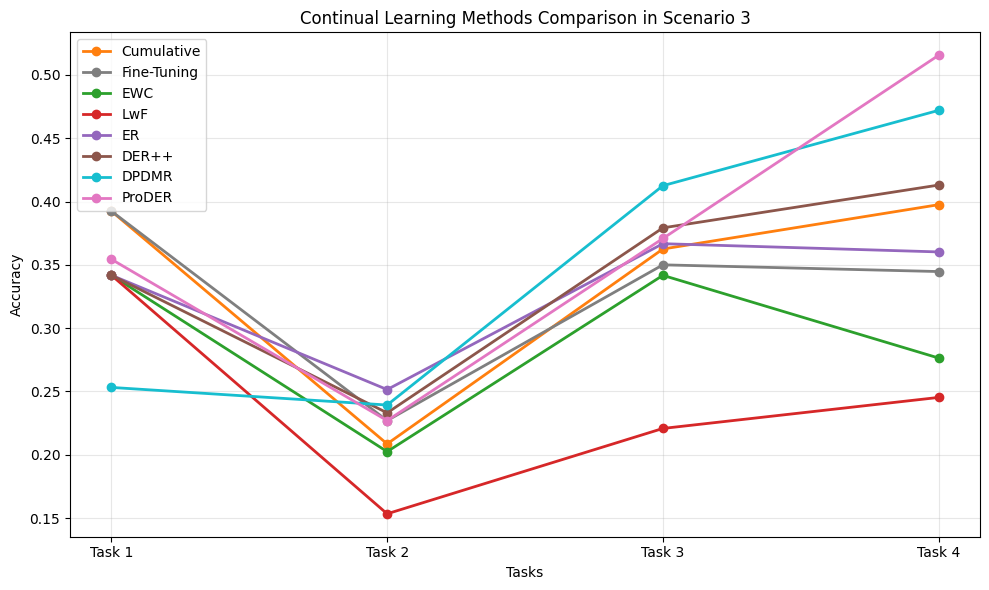

In [26]:
import matplotlib.pyplot as plt

def plot_taskwise_accuracy(
    method_accuracies,
    task_labels=None,
    title="Accuracy Across Tasks",
    colors=None
):
    plt.figure(figsize=(10, 6))

    for method, accuracies in method_accuracies.items():
        tasks = list(range(1, len(accuracies) + 1))
        color = colors[method] if colors and method in colors else None

        plt.plot(
            tasks,
            accuracies,
            marker='o',
            linewidth=2,
            label=method,
            color=color
        )

    if task_labels is None:
        task_labels = [
            f"Task {i}"
            for i in range(
                1,
                len(next(iter(method_accuracies.values()))) + 1
            )
        ]

    plt.xlabel("Tasks")
    plt.ylabel("Accuracy")
    plt.title(title)

    plt.xticks(
        ticks=range(1, len(task_labels) + 1),
        labels=task_labels
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        "sc3_accuracy.pdf",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# Scenario 3 — Task-wise Accuracy
# ============================================================

method_accuracies = {

    "Cumulative": [
        0.3924,
        0.2086,
        0.3625,
        0.3975
    ],

    "Fine-Tuning": [
        0.3924,
        0.2270,
        0.3500,
        0.3447
    ],

    "EWC": [
        0.3418,
        0.2025,
        0.3417,
        0.2764
    ],

    "LwF": [
        0.3418,
        0.1534,
        0.2208,
        0.2453
    ],

    "ER": [
        0.3418,
        0.2515,
        0.3667,
        0.3602
    ],

    "DER++": [
        0.3418,
        0.2331,
        0.3792,
        0.4130
    ],

    "DPDMR": [
        0.2532,
        0.2393,
        0.4125,
        0.4720
    ],

    "ProDER": [
        0.3544,
        0.2270,
        0.3708,
        0.5155
    ]
}


task_labels = [
    "Task 1",
    "Task 2",
    "Task 3",
    "Task 4"
]


colors = {
    "Cumulative": "#ff7f0e",
    "Fine-Tuning": "#7f7f7f",
    "EWC": "#2ca02c",
    "LwF": "#d62728",
    "ER": "#9467bd",
    "DER++": "#8c564b",
    "DPDMR": "#17becf",
    "ProDER": "#e377c2"
}


plot_taskwise_accuracy(
    method_accuracies,
    task_labels=task_labels,
    title="Continual Learning Methods Comparison in Scenario 3",
    colors=colors
)

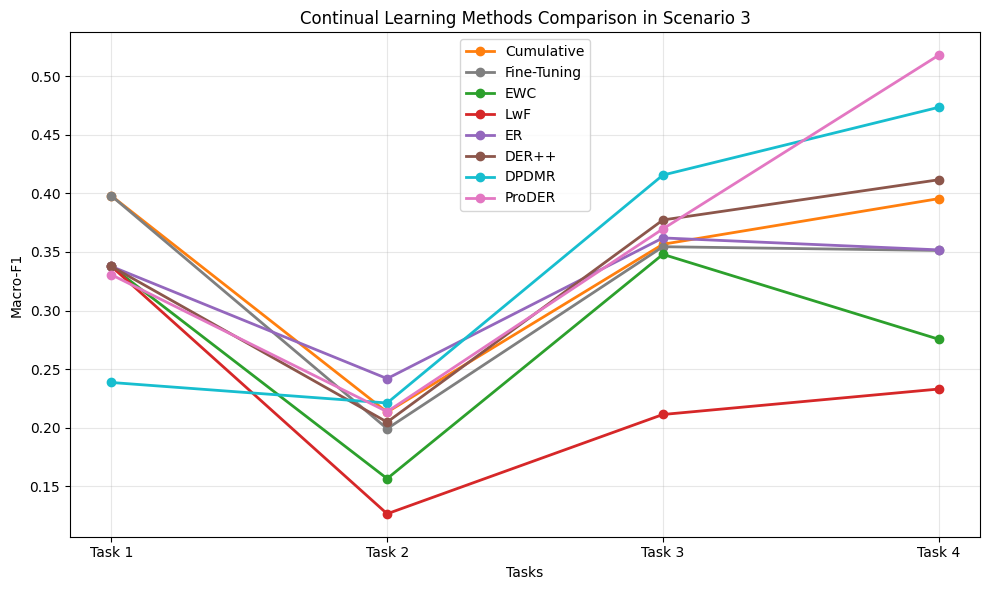

In [27]:
import matplotlib.pyplot as plt

def plot_taskwise_macro_f1(
    method_f1,
    task_labels=None,
    title="Macro-F1 Across Tasks",
    colors=None
):
    plt.figure(figsize=(10, 6))

    for method, values in method_f1.items():
        tasks = list(range(1, len(values) + 1))
        color = colors[method] if colors and method in colors else None

        plt.plot(
            tasks,
            values,
            marker='o',
            linewidth=2,
            label=method,
            color=color
        )

    if task_labels is None:
        task_labels = [
            f"Task {i}"
            for i in range(
                1,
                len(next(iter(method_f1.values()))) + 1
            )
        ]

    plt.xlabel("Tasks")
    plt.ylabel("Macro-F1")
    plt.title(title)

    plt.xticks(
        ticks=range(1, len(task_labels) + 1),
        labels=task_labels
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        "sc3_macro_f1.pdf",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# Scenario 3 — Task-wise Macro-F1
# ============================================================

method_f1 = {

    "Cumulative": [
        0.3979,
        0.2134,
        0.3566,
        0.3955
    ],

    "Fine-Tuning": [
        0.3979,
        0.1993,
        0.3545,
        0.3513
    ],

    "EWC": [
        0.3377,
        0.1567,
        0.3480,
        0.2756
    ],

    "LwF": [
        0.3377,
        0.1267,
        0.2114,
        0.2331
    ],

    "ER": [
        0.3377,
        0.2420,
        0.3620,
        0.3518
    ],

    "DER++": [
        0.3377,
        0.2049,
        0.3773,
        0.4116
    ],

    "DPDMR": [
        0.2387,
        0.2212,
        0.4156,
        0.4734
    ],

    "ProDER": [
        0.3306,
        0.2138,
        0.3697,
        0.5178
    ]
}


task_labels = [
    "Task 1",
    "Task 2",
    "Task 3",
    "Task 4"
]


colors = {
    "Cumulative": "#ff7f0e",
    "Fine-Tuning": "#7f7f7f",
    "EWC": "#2ca02c",
    "LwF": "#d62728",
    "ER": "#9467bd",
    "DER++": "#8c564b",
    "DPDMR": "#17becf",
    "ProDER": "#e377c2"
}


plot_taskwise_macro_f1(
    method_f1,
    task_labels=task_labels,
    title="Continual Learning Methods Comparison in Scenario 3",
    colors=colors
)